# Collection Équinoxe : estimer la hausse de loyer 2026

**Équipe CodeML 2026 · défi JADCO « Clés en main »** · notebook principal (livrable évalué)

## Réponse en une phrase
*(La valeur est calculée en section 11 ; aucun chiffre de ce notebook n'est tapé à la main dans le texte.)*

> **Hausse 2026 = croissance annualisée du loyer effectif (net des concessions) à unité constante, mesurée sur les baux qui débutent en 2026 contre le bail précédent de la même unité (`prop_code` + `unit_code`), médiane des paires, renouvellements et relocations confondus.**
> Nous publions toujours à côté la **hausse contractuelle** (loyer inscrit au bail), seule comparable aux règles du TAL et de l'Ontario.

## Plan (même ordre que la grille d'évaluation)
1. Définir la question et la nommer · 2. Lire les données et renommer les colonnes · 3. Effet de composition (mix) ·
4. Appariement à unité constante · 5. Concessions · 6. Renouvellements vs relocations, Québec vs Ontario ·
7. Choix de la définition (tableau comparatif) · 8. Données publiques et réconciliation · 9. Estimateurs alternatifs (contre-vérification) ·
10. Prévision `estimate_2026()` et `backtest()` · 11. Scénarios, intervalles, immeuble × chambres · 12. Limites et hypothèses · 13. Références (sources et outils d'IA)

### Conventions de ce notebook (discipline d'un desk quantitatif)
* **Français** pour les explications, **anglais `snake_case`** pour les identifiants (une seule langue de nommage, tableau de correspondance en section 2).
* **Aucun nombre magique.** Chaque paramètre est soit **estimé sur les données** (la cellule qui l'estime est montrée), soit **tiré d'une source publique** (tableau `external/`, avec URL et date de publication), soit **déclaré comme a priori** dans une cellule `# CONFIG`, avec sa justification et un test de sensibilité. Hors des cellules `# CONFIG`, les seuls littéraux tolérés sont 0, 1, 2 et 100.
* **Aucun chiffre tapé dans le texte.** Les paragraphes « Lecture » qui citent des valeurs sont **rédigés par le code** à partir des variables calculées : le texte ne peut pas diverger des données.
* **Information datée.** Toute donnée publique porte sa date de publication (`published_on`) ; une prévision n'utilise que ce qui était public à sa date de coupure.
* **Les fichiers sources ne sont jamais modifiés** : tout renommage et toute transformation se font ici, et **aucune donnée CRM n'est exportée** (seuls des agrégats sont écrits sur disque).
* Une cellule Markdown précède chaque étape qui modifie les données ; un contrôle automatique (`lint_notebook.py`) vérifie toutes ces règles.

## 0. Configuration et importations
Toutes les importations et toutes les constantes sont ici. Chaque constante dit *pourquoi* elle a cette valeur ; celles qui peuvent être estimées le sont plus bas, dans la section qui les utilise.

In [1]:
# CONFIG
import json
import os
import warnings
from contextlib import contextmanager
from dataclasses import dataclass, field, replace
from itertools import product
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import xgboost as xgboost_library
from IPython.display import Markdown, display
from scipy.stats import norm

try:                       # SHAP et plotly sont des plus : leur absence ne bloque pas le notebook
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="IProgress not found.*")
        import shap
except ImportError:
    shap = None
try:
    import plotly.graph_objects as plotly_go
    from plotly.subplots import make_subplots
except ImportError:
    plotly_go = None

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


@dataclass(frozen=True)
class Config:
    # --- emplacements (le CRM n'est pas livré : l'utilisateur pointe vers ses 4 CSV) ---
    data_dir: Path = Path(os.environ.get("JADCO_DATA_DIR", "../.."))
    external_dir: Path = Path(os.environ.get("JADCO_EXTERNAL_DIR", "external/tidy"))
    output_dir: Path = Path(os.environ.get("JADCO_OUTPUT_DIR", "outputs"))
    data_as_of: str = "2026-10-04"    # date de retrait des données publiques (external/SOURCES.md)
    # --- calendrier ---
    first_year: int = 2019            # première année avec assez de paires pour une médiane stable (comptes en section 4)
    last_observed_year: int = 2025    # fin de l'historique fourni (31 décembre 2025)
    forecast_year: int = 2026         # année à prévoir
    backtest_years: tuple = (2023, 2024, 2025)   # imposé par le défi
    extended_backtest_years: tuple = (2021, 2022, 2023, 2024, 2025)  # toutes les années où le taux du TAL publié est vérifié (2021+)
    panel_entry_year: int = 2022      # immeubles présents avant les mises en service de 2023-2024 : panel fixe
    # --- appariement (valeurs du notebook de départ, justifiées et testées en section 4d) ---
    pair_gap_min_years: float = 0.5   # plus court = probablement le même bail enregistré deux fois
    pair_gap_max_years: float = 2.5   # plus long = bail non comparable
    sensitivity_gap_windows: tuple = ((0.75, 1.5), (11 / 12, 13 / 12))   # fenêtres alternatives : resserrée, et « 12 mois à un mois près »
    asking_gap_min_years: float = 0.25   # deux affichages d'une même unité doivent être espacés d'au moins un trimestre
    days_per_year: float = 365.25
    months_per_year: int = 12
    outlier_tail_share: float = 0.005 # extrémités rognées dans l'analyse de sensibilité (de chaque côté)
    winsor_share: float = 0.01        # winsorisation alternative
    min_cell_size: int = 15           # nombre minimal de paires (ou d'unités) pour publier une cellule seule
    # --- concessions ---
    concession_link_grace_days: int = 30   # une concession peut débuter avant le bail ; valeur qui maximise la concordance (testé en 5b)
    concession_grace_days_tested: tuple = (0, 15, 30, 45, 60, 90)
    term_months_buckets: tuple = (6, 12, 18, 24)   # durées contractuelles réelles ; durées arrondies aux termes contractuels ; distribution vérifiée en section 2
    exact_tolerance_dollars: float = 1.0           # écart d'arrondi accepté entre notre reconstruction et le loyer effectif de Yardi
    min_reconstruction_share: float = 0.85         # part minimale des baux dont rent_effective se reconstruit à partir des concessions
    # --- statistiques ---
    n_bootstrap: int = 1000
    n_repeat_bootstrap: int = 200     # moins de tirages pour l'indice de loyers répétés : chaque tirage refait deux régressions
    n_simulations: int = 5000
    random_seed: int = 2026
    ci_low: float = 10.0              # bornes d'intervalle (percentiles)
    ci_high: float = 90.0
    recent_years_for_mean: int = 3    # référence naïve « moyenne des dernières années »
    min_years_for_reconciliation: int = 4   # moins d'années communes : pas de corrélation rapportée
    mix_sensitivity_ratio: float = 3.0      # le contre-exemple doit être au moins autant de fois plus sensible au mix
    max_method_disagreement_points: float = 1.0   # tolérance de concordance entre estimateurs indépendants (section 9)
    variance_floor: float = 1e-9      # plancher de variance prédite (pondération de Case-Shiller)
    # --- règles publiques (valeurs vérifiées, voir external/SOURCES.md) ---
    ontario_exemption_cutoff: str = "2018-11-15"  # le plafond ne s'applique pas aux unités occupées pour la première fois après cette date
    ontario_min_months_between_increases: int = 12
    month_tolerance_between_increases: int = 1    # tolérance (en mois) : les baux « de 12 mois » durent 11,9 mois
    tal_window_first_month: int = 4   # un taux TAL publié en janvier de t couvre les baux débutant du 2 avril de t au 1er avril de t+1
    tal_window_first_day: int = 2     # ... premier jour de la fenêtre : le 2 avril (un bail débutant le 1er avril relève du taux de l'année précédente)
    new_building_age_years: int = 5   # art. 1955 C.c.Q. : pas de fixation par le Tribunal dans les cinq ans suivant la date où l'immeuble est prêt pour l'usage (si le bail le prévoit)
    # --- contrôles d'intégrité (comptes annoncés par le défi) ---
    expected_leases: int = 4302
    expected_units: int = 1061
    expected_concessions: int = 3560
    expected_asking: int = 3857
    expected_key_collisions: int = 248   # unités en collision sur site + unité (énoncé du défi)
    starter_contract_median_2025: float = 7.04   # médiane contractuelle 2025 du notebook de départ (parité vérifiée en section 4)
    starter_effective_median_2025: float = 3.58  # médiane effective 2025 du notebook de départ
    check_tolerance: float = 0.01                # tolérance des contrôles de parité (en points)
    ask_match_tolerance_days: int = 62           # un affichage est associé à une signature s'il date d'au plus deux mois avant elle
    reference_bedrooms: int = 2                  # segment de référence pour comparer les niveaux à la SCHL (le plus nombreux des deux côtés)
    bedroom_levels: tuple = (0, 1, 2, 3)
    # --- affichage ---
    prose_digits: int = 1             # décimales des nombres rédigés par le code
    table_digits: int = 2             # décimales des tableaux
    fine_digits: int = 3              # décimales des coefficients estimés


@dataclass(frozen=True)
class PlotStyle:
    figsize_wide: tuple = (9.5, 4.5)
    figsize_grid: tuple = (11, 7)
    legend_fontsize: int = 8
    small_fontsize: int = 7
    line_width: float = 2.0
    area_alpha: float = 0.8
    band_alpha: float = 0.15
    error_capsize: int = 5
    x_margin_years: float = 0.5
    marker_jitter_years: float = 0.08            # décalage horizontal pour ne pas superposer deux barres d'erreur
    rc: dict = field(default_factory=lambda: {"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
    palette: dict = field(default_factory=lambda: {"contract": "#1f77b4", "effective": "#d62728", "naive": "#7f7f7f", "market": "#2ca02c",
                                                   "rule": "#ff7f0e", "alternative": "#9467bd"})


CONFIG = Config()
STYLE = PlotStyle()
PALETTE = STYLE.palette
UNIT_KEY = ["prop_code", "unit_code"]      # clé d'unité : JAMAIS site + unit_code
CONFIG.output_dir.mkdir(parents=True, exist_ok=True)
matplotlib.rcParams.update(STYLE.rc)


def year_start(year):
    """Premier jour de l'année civile."""
    return pd.Period(year, "Y").start_time


def year_end(year):
    """Dernier jour de l'année civile (date de coupure d'une prévision faite à la fin de l'année)."""
    return pd.Period(year, "Y").end_time.normalize()


def fmt(value, digits=CONFIG.prose_digits, signed=False):
    """Nombre à la française pour le texte rédigé par le code (virgule décimale, espace fine des milliers, vrai signe moins)."""
    text = f"{value:+,.{digits}f}" if signed else f"{value:,.{digits}f}"
    return text.replace(",", " ").replace(".", ",").replace("-", "−")


def narrate(text):
    """Affiche un paragraphe Markdown dont tous les nombres viennent de variables calculées (aucun chiffre tapé à la main)."""
    display(Markdown(text))

## 1. Définir la question

« La hausse de loyer de l'année » désigne en réalité **cinq nombres différents** : (1) même unité, loyer *contractuel* ; (2) même unité, loyer *effectif* ; (3) renouvellements seulement ; (4) relocations seulement ; (5) portefeuille global (médiane de tous les baux). Ils ne concordent pas, et le choix change la réponse de plusieurs points (section 7).

**Notre choix (nommé et défendu ; la preuve chiffrée est en section 7) :**

| Rôle | Définition | Pourquoi |
|---|---|---|
| **Principal** | **Hausse à unité constante du loyer *effectif*** (net des concessions), annualisée, baux débutant en 2026, médiane des paires, renouvellements + relocations pondérés par leur poids réel | Mesure typique du changement de revenu à unité constante ; la moyenne pondérée par le loyer est publiée à côté pour le budget. Elle ne dépend pas du mix du portefeuille. Les concessions deviennent la norme (section 5), donc le loyer contractuel surestime le revenu. |
| **Secondaire (toujours publié)** | Hausse à unité constante du loyer *contractuel*, renouvellements et relocations séparés | C'est le nombre que le TAL et l'Ontario encadrent : il permet de lire la règle applicable et de calculer les lettres de renouvellement. |
| **Contre-exemple** | Médiane des loyers de tous les baux, d'une année à l'autre | Mesure surtout la composition du portefeuille (le « pic de 2023 » qui n'a pas eu lieu, section 3). |

**Choix de forme** (chacun est testé en section 7) : année = année de début de bail (c'est l'année budgétaire ; le délai signature → début est de quelques semaines, section 7b) ; annualisation par `(rent / prev_rent) ** (1 / gap) - 1` ; agrégation par médiane (robuste), avec la moyenne pondérée par le loyer en contrôle ; Québec et Ontario **jamais mélangés dans une règle**, seulement dans le total.

## 2. Lire les données : ce qu'elles représentent réellement

Les descriptions ne correspondent pas toujours aux données. Cette section (a) charge les quatre fichiers, (b) **vérifie par du code** chaque doute (colonne par colonne), (c) renomme les colonnes selon ce qu'elles *sont*.

**Cette cellule modifie les données** : elle crée quatre tables renommées (`leases`, `units`, `concessions`, `asking`). Convention Yardi : `h*` = identifiant de jointure (`*_id`), `s*` = valeur lue par un humain. On joint sur les identifiants et on regroupe sur les valeurs.

In [2]:
LEASE_RENAME = {
    "hUnit": "unit_id", "hBuilding": "building_id", "hProperty": "property_id",
    "sPropCode": "prop_code", "sUnitCode": "unit_code", "sBuilding": "building", "sCity": "city",
    "sState": "province", "sSite": "site", "sRent": "rent_contract", "sRentEffective": "rent_effective",
    "sConcession": "has_concession", "sRenewal": "is_renewal", "sTermSeq": "unit_lease_seq",
    "sLeaseFrom": "lease_start", "sLeaseTo": "lease_end", "sSignDate": "sign_date",
    "sTermMonths": "term_months_raw", "sLeaseTerm": "term_label", "sBeds": "beds", "sBaths": "baths",
    "sSqft": "sqft", "sFloor": "floor", "sUnitType": "unit_type", "sAvailable": "lease_start_duplicate",
    "sLatitude": "latitude", "sLongitude": "longitude",
}
CONCESSION_RENAME = {
    "hUnit": "unit_id", "sPropCode": "prop_code", "sUnitCode": "unit_code", "sBuilding": "building",
    "sState": "province", "sBeds": "beds", "sChargeCode": "charge_code", "sChargeDesc": "charge_desc",
    "sAmount": "amount", "sDateFrom": "date_from", "sDateTo": "date_to", "sMonths": "months_covered",
}
ASKING_RENAME = {
    "hUnit": "unit_id", "sPropCode": "prop_code", "sUnitCode": "unit_code", "sBuilding": "building",
    "sState": "province", "sBeds": "beds", "sMonth": "ask_month", "sAskingRent": "rent_ask", "sSqft": "sqft",
}
UNIT_RENAME = {
    "hUnit": "unit_id", "sPropCode": "prop_code", "sUnitCode": "unit_code", "sBuilding": "building",
    "sState": "province", "sSite": "site", "sBeds": "beds", "sSqft": "sqft", "sRent": "rent_listed_2025",
    "sAsOf": "listed_as_of_month", "sAvailable": "available_date", "sFloor": "floor",
}


def load_table(file_name, rename_map, date_columns=()):
    """Lit un CSV source (jamais modifié) et retourne une copie renommée, colonnes de dates converties."""
    table = pd.read_csv(CONFIG.data_dir / file_name)
    for column in date_columns:
        table[column] = pd.to_datetime(table[column])
    return table.rename(columns=rename_map)


leases = load_table("equinoxe_lease_history.csv", LEASE_RENAME, ["sLeaseFrom", "sLeaseTo", "sSignDate", "sAvailable"])
units = load_table("equinoxe_listings.csv", UNIT_RENAME, ["sAvailable"])
concessions = load_table("equinoxe_concessions.csv", CONCESSION_RENAME, ["sDateFrom", "sDateTo"])
asking = load_table("equinoxe_asking_history.csv", ASKING_RENAME)
asking["ask_date"] = pd.PeriodIndex(asking.ask_month, freq="M").start_time

for name, table in [("leases", leases), ("units", units), ("concessions", concessions), ("asking", asking)]:
    print(f"{name:<12} {len(table):>6,} lignes   {table.shape[1]:>2} colonnes")

leases        4,302 lignes   35 colonnes
units         1,061 lignes   29 colonnes
concessions   3,560 lignes   18 colonnes
asking        3,857 lignes   15 colonnes


### 2b. Audit « description contre réalité »
Chaque ligne du tableau ci-dessous est une *vérification exécutée* (pas une affirmation). Les doutes viennent de l'énoncé : « la description ne correspond pas toujours aux données ».

**Cette cellule ajoute des colonnes** à `leases` : `lease_id` (identifiant technique), `lease_year` (année de début), `drag` (part du loyer cédée en concession), `rank_in_unit` et `term_months` (durée arrondie à la durée contractuelle réelle).

In [3]:
leases = leases.sort_values(UNIT_KEY + ["lease_start"]).reset_index(drop=True)
leases["lease_id"] = leases.index                       # identifiant technique de bail (pour les jointures)
leases["lease_year"] = leases.lease_start.dt.year       # année budgétaire = année de début de bail
leases["drag"] = 1 - leases.rent_effective / leases.rent_contract          # part du loyer cédée en concession
leases["rank_in_unit"] = leases.groupby(UNIT_KEY).cumcount() + 1
leases["term_months"] = leases.term_months_raw.apply(
    lambda raw: min(CONFIG.term_months_buckets, key=lambda bucket: abs(bucket - raw))).astype(int)   # 5,9 -> 6 ; 11,9 -> 12 ; ...

key_collisions = units.duplicated(["site", "unit_code"], keep=False).sum()
unit_id_is_key = (leases.groupby(UNIT_KEY).unit_id.nunique() == 1).all() and (leases.groupby("unit_id").size().index.size == leases.groupby(UNIT_KEY).ngroups)


def link_concession_lines(concession_table, lease_table, grace_days):
    """Rattache chaque ligne de concession au dernier bail de la même unité commencé au plus tard `grace_days` jours après le début de la ligne."""
    keyed = concession_table.assign(link_date=concession_table.date_from + pd.Timedelta(days=grace_days)).sort_values("link_date")
    lease_columns = UNIT_KEY + ["lease_id", "lease_start", "lease_end", "term_months", "rent_contract", "rent_effective"]
    attached = pd.merge_asof(keyed, lease_table[lease_columns].sort_values("lease_start"), left_on="link_date", right_on="lease_start", by=UNIT_KEY, direction="backward")
    attached = attached[attached.lease_id.notna() & (attached.date_from <= attached.lease_end)].copy()
    attached["monthly_equivalent"] = -attached.amount * attached.months_covered / attached.term_months
    return attached


linked_for_audit = link_concession_lines(concessions, leases, CONFIG.concession_link_grace_days)
promo_lines_audit = linked_for_audit[linked_for_audit.charge_code == "PromoPay"]
promo_ratio = (-promo_lines_audit.amount / promo_lines_audit.rent_contract).median()
last_lease = leases.groupby(UNIT_KEY).tail(1)[UNIT_KEY + ["rent_contract"]]
listing_gap = (units.merge(last_lease, on=UNIT_KEY).eval("rent_listed_2025 / rent_contract - 1") * 100)
labels_with_several_terms = int((leases.groupby("term_label").term_months.nunique() > 1).sum())

audit = pd.DataFrame([
    ("sAvailable (baux)", "date de disponibilité", f"identique à `lease_start` sur {(leases.lease_start_duplicate == leases.lease_start).mean():.0%} des baux",
     "redondante : renommée `lease_start_duplicate`, non utilisée"),
    ("sConcession", "indicateur de concession", f"égal à `rent_effective < rent_contract` sur {((leases.rent_effective < leases.rent_contract) == leases.has_concession.astype(bool)).mean():.0%} des baux",
     "indicateur dérivé : on utilise plutôt `drag` (la profondeur)"),
    ("sTermSeq", "numéro de terme", f"rang du bail dans l'unité : {(leases.unit_lease_seq == leases.rank_in_unit).mean():.0%} concordent ; {int(((leases.unit_lease_seq >= 2) & (leases.is_renewal == 0)).sum()):,} baux de rang ≥ 2 sont des relocations",
     "ce n'est PAS un compteur de renouvellements : on sépare avec `is_renewal`"),
    ("sTermMonths", "durée en mois", f"valeurs {[float(v) for v in sorted(leases.term_months_raw.unique())]} : des jours/30,4 arrondis",
     f"arrondie à {'/'.join(str(bucket) for bucket in CONFIG.term_months_buckets)} mois → `term_months`"),
    ("sLeaseTerm", "libellé de durée", f"incohérent avec la durée réelle : {labels_with_several_terms} libellé(s) regroupent plusieurs durées réelles",
     "ignorée au profit de `term_months`"),
    ("PromoPay", "frais mensuel (« payable in the future »)", f"`months_covered` ∈ {[int(v) for v in sorted(concessions[concessions.charge_code == 'PromoPay'].months_covered.unique())]}, montant ≈ {promo_ratio:.2f} × le loyer mensuel",
     "montant **forfaitaire unique** (≈ 1 mois), étalé sur la durée du bail (section 5)"),
    ("sRent (listings)", "loyer", f"loyer *affiché* de 2025 (écart médian de {listing_gap.median():+.1f} % contre le dernier bail, plage {listing_gap.min():.0f} à {listing_gap.max():.1f} %)",
     "renommé `rent_listed_2025` ; ce n'est pas un bail (et pas un prix 2026, voir section 10g)"),
    ("sSite + sUnitCode", "identifiant d'unité ?", f"{key_collisions} unités sur {len(units):,} entrent en collision",
     "jamais une clé : on utilise `prop_code` + `unit_code`"),
    ("hUnit ↔ prop_code+unit_code", "clés équivalentes ?", f"correspondance 1 pour 1 : {bool(unit_id_is_key)}", "les deux clés sont sûres"),
    ("dates de fin / concessions", "historique jusqu'à 2025", f"`lease_end` jusqu'en {leases.lease_end.max():%Y-%m} ; concessions jusqu'en {concessions.date_to.max():%Y-%m}",
     "dates *contractuelles* futures : elles disent quelles unités échoient en 2026 (cohorte)"),
], columns=["colonne source", "description officielle", "ce que le code constate", "décision"])
audit

,colonne source,description officielle,ce que le code constate,décision
0,sAvailable (baux),date de disponibilité,identique à `lease_start` sur 100% des baux,"redondante : renommée `lease_start_duplicate`,..."
1,sConcession,indicateur de concession,égal à `rent_effective < rent_contract` sur 10...,indicateur dérivé : on utilise plutôt `drag` (...
2,sTermSeq,numéro de terme,rang du bail dans l'unité : 100% concordent ; ...,ce n'est PAS un compteur de renouvellements : ...
3,sTermMonths,durée en mois,"valeurs [5.9, 12.0, 17.9, 23.9] : des jours/30...",arrondie à 6/12/18/24 mois → `term_months`
4,sLeaseTerm,libellé de durée,incohérent avec la durée réelle : 2 libellé(s)...,ignorée au profit de `term_months`
5,PromoPay,frais mensuel (« payable in the future »),"`months_covered` ∈ [1, 2], montant ≈ 0.80 × le...","montant **forfaitaire unique** (≈ 1 mois), éta..."
6,sRent (listings),loyer,loyer *affiché* de 2025 (écart médian de +2.5 ...,renommé `rent_listed_2025` ; ce n'est pas un b...
7,sSite + sUnitCode,identifiant d'unité ?,"248 unités sur 1,061 entrent en collision",jamais une clé : on utilise `prop_code` + `uni...
8,hUnit ↔ prop_code+unit_code,clés équivalentes ?,correspondance 1 pour 1 : True,les deux clés sont sûres
9,dates de fin / concessions,historique jusqu'à 2025,`lease_end` jusqu'en 2027-11 ; concessions jus...,dates *contractuelles* futures : elles disent ...


**À retenir de l'audit.** Trois pièges changent des résultats : `PromoPay` (forfait unique, pas mensuel), `sTermSeq` (rang du bail, pas renouvellement) et `sSite` (jamais une clé). `sAvailable` est un doublon. Nous ne modifions aucun fichier source.

In [4]:
# Contrôles de validité (tests exécutés à chaque lancement) -------------------------------------------------
assert (len(leases), len(units), len(concessions), len(asking)) == (CONFIG.expected_leases, CONFIG.expected_units, CONFIG.expected_concessions, CONFIG.expected_asking), "comptes de lignes inattendus"
assert (leases.lease_start_duplicate == leases.lease_start).all()
assert ((leases.rent_effective < leases.rent_contract) == leases.has_concession.astype(bool)).all()
assert key_collisions == CONFIG.expected_key_collisions, f"le défi annonce {CONFIG.expected_key_collisions} collisions sur site + unité"
assert leases.groupby(UNIT_KEY).unit_id.nunique().eq(1).all()
print("Contrôles de la section 2 : OK")

Contrôles de la section 2 : OK


## 3. Pourquoi la médiane annuelle mesure surtout le mix

**Étape sans modification des données sources** : on calcule des tables d'analyse (`naive`, `mix_profile`, `entry_year`). Le réflexe est le loyer médian par année de début de bail. Nous le reproduisons, puis nous montrons trois fois, de la plus simple à la plus rigoureuse, que ce nombre reflète la *composition* du portefeuille et non les prix : (a) un **panel fixe** de propriétés, (b) une **décomposition exacte** de la variation de loyer moyen, (c) un **indice de prix de Fisher** sur des segments comparables. Le segment de base est le **code de propriété** (`prop_code`), parce que le nom d'immeuble « Saint-Elzéar » regroupe trois propriétés distinctes.

In [5]:
analysis_window = leases[leases.lease_year.between(CONFIG.first_year, CONFIG.last_observed_year)]

naive = analysis_window.groupby("lease_year").agg(leases=("rent_contract", "size"), median_rent=("rent_contract", "median"))
naive["yoy_pct"] = naive.median_rent.pct_change() * 100

mix_profile = analysis_window.groupby("lease_year").agg(
    median_sqft=("sqft", "median"),
    pct_2bed_plus=("beds", lambda beds: (beds >= 2).mean() * 100),
    properties=("prop_code", "nunique"))
mix_profile["median_rent_per_sqft"] = (analysis_window.assign(rent_psf=analysis_window.rent_contract / analysis_window.sqft)
                                       .groupby("lease_year").rent_psf.median())
entry_year = leases.groupby("prop_code").lease_year.min().sort_values()
print("Année du premier bail par code de propriété (mise en service) :")
print(entry_year.to_dict())
pd.concat([naive, mix_profile], axis=1)

Année du premier bail par code de propriété (mise en service) :
{'stelz1': 2017, 'levesque': 2018, 'stelz2': 2019, 'dj1': 2019, 'dj2': 2022, 'carlyle': 2023, 'metcalfe': 2023, 'wsp1': 2024, 'stelz3': 2025}


,leases,median_rent,yoy_pct,median_sqft,pct_2bed_plus,properties,median_rent_per_sqft
lease_year,,,,,,,
2019,328,"1,730.00",NaN,"1,177.50",78.66,4,1.48
2020,373,"1,775.00",2.60,"1,180.00",77.75,4,1.53
2021,361,"1,850.00",4.23,"1,175.00",78.39,4,1.60
2022,422,"1,912.50",3.38,"1,160.00",72.51,5,1.71
2023,693,"2,120.00",10.85,"1,095.00",62.63,7,2.04
2024,902,"2,215.00",4.48,"1,045.00",62.20,8,2.20
2025,958,"2,305.00",4.06,"1,025.00",60.23,9,2.33


In [6]:
naive_peak_year = int(naive.yoy_pct.idxmax())
entrants_by_year = {year: ", ".join(f"`{code}`" for code in codes.index) for year, codes in entry_year[entry_year > CONFIG.first_year].groupby(entry_year)}
narrate(f"**Lecture.** La médiane naïve culmine à **{fmt(naive.yoy_pct[naive_peak_year], signed=True)} % en {naive_peak_year}** (le chiffre de l'énoncé). "
        f"La même année, le loyer médian au pied carré passe de {fmt(mix_profile.median_rent_per_sqft[naive_peak_year - 1], CONFIG.table_digits)} à "
        f"{fmt(mix_profile.median_rent_per_sqft[naive_peak_year], CONFIG.table_digits)} $ et la part des 2 chambres et plus de "
        f"{fmt(mix_profile.pct_2bed_plus[naive_peak_year - 1])} % à {fmt(mix_profile.pct_2bed_plus[naive_peak_year])} % : des propriétés entrent dans l'extrait "
        f"({' ; '.join(f'{year} : {codes}' for year, codes in entrants_by_year.items())}). Presque aucun locataire existant ne paie cette hausse, comme le montrent les trois tests suivants.")

**Lecture.** La médiane naïve culmine à **+10,8 % en 2023** (le chiffre de l'énoncé). La même année, le loyer médian au pied carré passe de 1,71 à 2,04 $ et la part des 2 chambres et plus de 72,5 % à 62,6 % : des propriétés entrent dans l'extrait (2022 : `dj2` ; 2023 : `carlyle`, `metcalfe` ; 2024 : `wsp1` ; 2025 : `stelz3`). Presque aucun locataire existant ne paie cette hausse, comme le montrent les trois tests suivants.

### 3a. Panel fixe : mêmes propriétés chaque année
On ne garde que les codes de propriété déjà en service avant les mises en service de 2023-2024 (`panel_entry_year`). Si la hausse de 2023 vient du mix, elle doit disparaître.

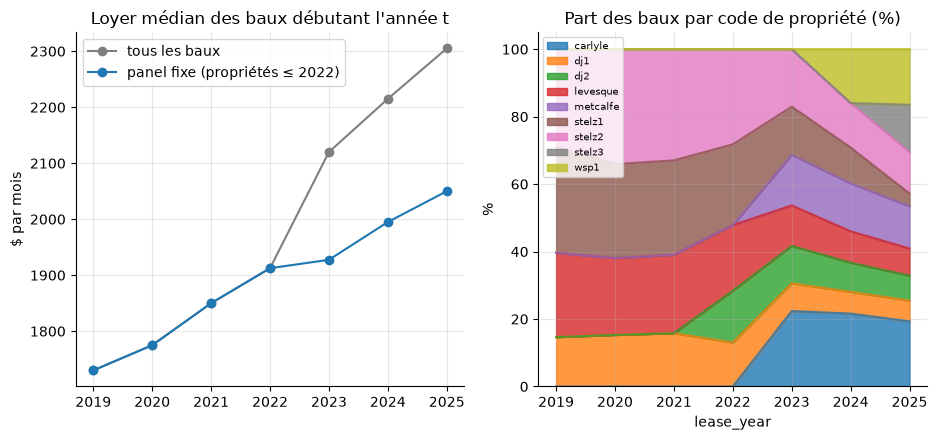

,naïf (tous les baux),panel fixe
lease_year,,
2020,2.60,2.60
2021,4.23,4.23
2022,3.38,3.38
2023,10.85,0.78
2024,4.48,3.50
2025,4.06,2.76


In [7]:
panel_codes = entry_year[entry_year <= CONFIG.panel_entry_year].index
panel_median = (analysis_window[analysis_window.prop_code.isin(panel_codes)]
                .groupby("lease_year").rent_contract.median())

fig, axes = plt.subplots(1, 2, figsize=STYLE.figsize_wide)
axes[0].plot(naive.index, naive.median_rent, "o-", color=PALETTE["naive"], label="tous les baux")
axes[0].plot(panel_median.index, panel_median, "o-", color=PALETTE["contract"], label=f"panel fixe (propriétés ≤ {CONFIG.panel_entry_year})")
axes[0].set(title="Loyer médian des baux débutant l'année t", ylabel="$ par mois")
axes[0].legend()
share_by_property = (analysis_window.groupby(["lease_year", "prop_code"]).size().unstack(fill_value=0))
(share_by_property.div(share_by_property.sum(axis=1), axis=0) * 100).plot.area(ax=axes[1], alpha=STYLE.area_alpha)
axes[1].set(title="Part des baux par code de propriété (%)", ylabel="%")
axes[1].legend(fontsize=STYLE.small_fontsize, loc="upper left")
plt.tight_layout()
plt.show()
panel_yoy = panel_median.pct_change() * 100
pd.DataFrame({"naïf (tous les baux)": naive.yoy_pct, "panel fixe": panel_yoy}).loc[CONFIG.first_year + 1:]

In [8]:
narrate(f"**Conclusion 3a.** À composition de propriétés constante, {naive_peak_year} passe de {fmt(naive.yoy_pct[naive_peak_year], signed=True)} % "
        f"à {fmt(panel_yoy[naive_peak_year], signed=True)} %. Les deux courbes se séparent exactement quand les nouvelles propriétés entrent.")

**Conclusion 3a.** À composition de propriétés constante, 2023 passe de +10,8 % à +0,8 %. Les deux courbes se séparent exactement quand les nouvelles propriétés entrent.

### 3b. Décomposition exacte de la variation du loyer moyen
Pour chaque année `t`, la variation du loyer *moyen* des baux se découpe en trois morceaux qui s'additionnent **exactement** :
1. **Prix à segment constant** : les segments (propriété × nombre de chambres) présents deux années de suite, pondérés par leur poids de l'année précédente ;
2. **Recomposition interne** : le déplacement des poids entre segments de propriétés déjà en service ;
3. **Entrée de nouvelles propriétés** : ce que change l'arrivée d'un code de propriété qui n'avait aucun bail l'année précédente.

C'est une décomposition par *shift-share* (écart de prix à l'intérieur des segments contre écart de composition).

In [9]:
SEGMENT_KEY = ["prop_code", "beds"]


def decompose_mean_change(frame, year):
    """Décompose la variation du loyer moyen entre year-1 et year (en % du loyer moyen de year-1)."""
    previous = frame[frame.lease_year == year - 1]
    current = frame[frame.lease_year == year]
    mean_previous = previous.rent_contract.mean()
    total_change = current.rent_contract.mean() - mean_previous
    continuing = set(previous.prop_code) & set(current.prop_code)
    previous_c = previous[previous.prop_code.isin(continuing)]
    current_c = current[current.prop_code.isin(continuing)]
    change_continuing = current_c.rent_contract.mean() - previous_c.rent_contract.mean()

    def segment_table(part):
        table = part.groupby(SEGMENT_KEY).rent_contract.agg(["size", "mean"])
        table["weight"] = table["size"] / table["size"].sum()
        return table

    joined = segment_table(previous_c).join(segment_table(current_c), lsuffix="_prev", rsuffix="_curr", how="inner")
    within = (joined.weight_prev * (joined.mean_curr - joined.mean_prev)).sum()
    parts = {"within": within, "internal_mix": change_continuing - within, "entry": total_change - change_continuing}
    parts = {name: value / mean_previous * 100 for name, value in parts.items()}
    parts["total"] = total_change / mean_previous * 100
    return parts


decomposition = pd.DataFrame({year: decompose_mean_change(analysis_window, year)
                              for year in range(CONFIG.first_year + 1, CONFIG.last_observed_year + 1)}).T
decomposition.columns = ["prix à segment constant", "recomposition interne", "entrée de nouvelles propriétés", "total (loyer moyen)"]
COMPONENT_COLUMNS = list(decomposition.columns[:-1])      # les trois morceaux ; la dernière colonne est le total
TOTAL_COLUMN = decomposition.columns[-1]
assert np.allclose(decomposition[COMPONENT_COLUMNS].sum(axis=1), decomposition[TOTAL_COLUMN]), "la décomposition doit se refermer"
decomposition

,prix à segment constant,recomposition interne,entrée de nouvelles propriétés,total (loyer moyen)
2020,3.30,0.34,0.00,3.64
2021,4.53,0.08,0.00,4.61
2022,5.28,-0.33,-0.27,4.67
2023,1.92,-0.61,10.62,11.93
2024,3.76,1.77,-1.64,3.90
2025,7.32,-0.67,-2.44,4.21


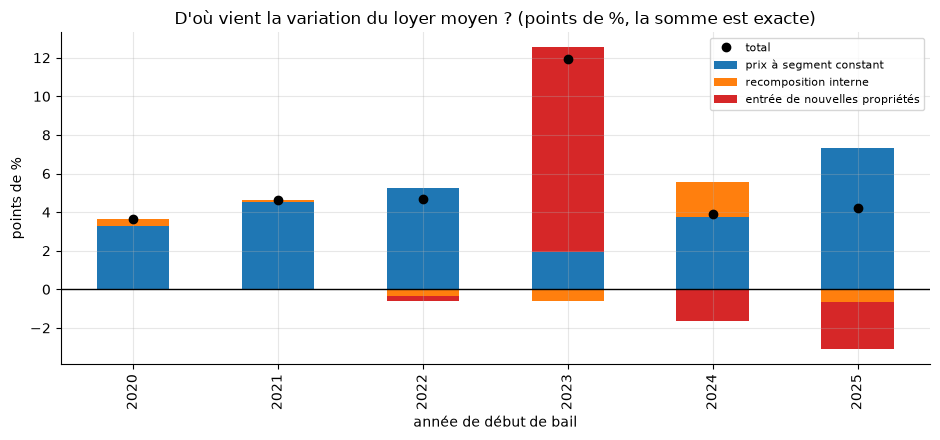

In [10]:
fig, ax = plt.subplots(figsize=STYLE.figsize_wide)
decomposition[COMPONENT_COLUMNS].plot.bar(stacked=True, ax=ax, color=[PALETTE["contract"], PALETTE["rule"], PALETTE["effective"]])
ax.plot(range(len(decomposition)), decomposition[TOTAL_COLUMN].to_numpy(), "ko", label="total")
ax.axhline(0, color="black", lw=STYLE.line_width / 2)
ax.set(title="D'où vient la variation du loyer moyen ? (points de %, la somme est exacte)", ylabel="points de %", xlabel="année de début de bail")
ax.legend(fontsize=STYLE.legend_fontsize)
plt.tight_layout()
plt.show()

In [11]:
peak_parts = decomposition.loc[naive_peak_year]
last_parts = decomposition.loc[CONFIG.last_observed_year]
narrate(f"**Conclusion 3b.** En {naive_peak_year}, sur {fmt(peak_parts[TOTAL_COLUMN], signed=True)} points de variation du loyer moyen, "
        f"l'entrée de nouvelles propriétés en explique **{fmt(peak_parts['entrée de nouvelles propriétés'], signed=True)}** et le prix à segment constant "
        f"seulement {fmt(peak_parts['prix à segment constant'], signed=True)}. En {CONFIG.last_observed_year}, le prix à segment constant vaut "
        f"{fmt(last_parts['prix à segment constant'], signed=True)} point(s) et la recomposition interne {fmt(last_parts['recomposition interne'], signed=True)}. "
        "Ces morceaux se somment exactement : la hausse naïve est une affaire de composition.")

**Conclusion 3b.** En 2023, sur +11,9 points de variation du loyer moyen, l'entrée de nouvelles propriétés en explique **+10,6** et le prix à segment constant seulement +1,9. En 2025, le prix à segment constant vaut +7,3 point(s) et la recomposition interne −0,7. Ces morceaux se somment exactement : la hausse naïve est une affaire de composition.

### 3c. Indice de Fisher sur segments appariés
Contre-vérification par la théorie des indices : sur les segments (propriété × chambres) présents deux années de suite, indice de Laspeyres (poids de l'année précédente), de Paasche (poids courants) et leur moyenne géométrique, l'indice de **Fisher**. Les segments nouveaux sont exclus : le prix ne se compare qu'à ce qui existait.

In [12]:
def fisher_growth(frame, year):
    previous = frame[frame.lease_year == year - 1].groupby(SEGMENT_KEY).rent_contract.agg(["size", "mean"])
    current = frame[frame.lease_year == year].groupby(SEGMENT_KEY).rent_contract.agg(["size", "mean"])
    matched = previous.join(current, lsuffix="_prev", rsuffix="_curr", how="inner")
    laspeyres = (matched.size_prev * matched.mean_curr).sum() / (matched.size_prev * matched.mean_prev).sum()
    paasche = (matched.size_curr * matched.mean_curr).sum() / (matched.size_curr * matched.mean_prev).sum()
    return (np.sqrt(laspeyres * paasche) - 1) * 100


fisher = pd.Series({year: fisher_growth(analysis_window, year)
                    for year in range(CONFIG.first_year + 1, CONFIG.last_observed_year + 1)}, name="fisher_pct")
pd.DataFrame({"médiane naïve": naive.yoy_pct, "Fisher (segments appariés)": fisher}).loc[CONFIG.first_year + 1:]

,médiane naïve,Fisher (segments appariés)
2020,2.60,3.28
2021,4.23,4.48
2022,3.38,5.26
2023,10.85,1.90
2024,4.48,3.80
2025,4.06,7.42


In [13]:
narrate(f"**Conclusion 3c.** L'indice de Fisher donne {fmt(fisher[naive_peak_year], signed=True)} % en {naive_peak_year} "
        f"(contre {fmt(naive.yoy_pct[naive_peak_year], signed=True)} % pour la médiane naïve) et {fmt(fisher[CONFIG.last_observed_year], signed=True)} % "
        f"en {CONFIG.last_observed_year} : il retrouve la bonne histoire sans comparer bail à bail. La section 4 montre que la méthode « même unité contre elle-même » "
        "donne des chiffres du même ordre par une autre voie : trois méthodes indépendantes, une même conclusion.")

**Conclusion 3c.** L'indice de Fisher donne +1,9 % en 2023 (contre +10,8 % pour la médiane naïve) et +7,4 % en 2025 : il retrouve la bonne histoire sans comparer bail à bail. La section 4 montre que la méthode « même unité contre elle-même » donne des chiffres du même ordre par une autre voie : trois méthodes indépendantes, une même conclusion.

## 4. Comparer chaque unité à elle-même

**Étape qui crée une nouvelle table de données** : `pairs`, une ligne par bail et son bail *précédent* dans la **même unité**. La clé d'unité est `prop_code + unit_code` (équivalente à `unit_id`, vérifié en section 2), **jamais** `site + unit_code`.

Plutôt que de filtrer en silence, le moteur construit **toutes** les paires consécutives, puis *étiquette* chaque raison d'invalidité. On peut ainsi compter ce qu'on écarte et tester si le filtre change la réponse.

**Annualisation.** Pour un écart de `gap` années entre deux débuts de bail : `croissance = (loyer / loyer_précédent) ** (1 / gap) - 1`. Les baux de 12 mois ont un écart voisin de 1 an (l'annualisation ne change presque rien) ; les baux de 18 et 24 mois, si.

In [14]:
def annualised_growth_pct(rent, previous_rent, gap_years):
    """Variation annualisée en % (composée) entre deux loyers séparés de gap_years années."""
    return ((rent / previous_rent) ** (1 / gap_years) - 1) * 100


def build_pairs(frame, key=UNIT_KEY):
    """Une ligne par bail ayant un bail précédent dans la même unité (selon `key`), avec les motifs d'invalidité."""
    ordered = frame.sort_values(key + ["lease_start"])
    grouped = ordered.groupby(key)
    pairs = ordered.copy()
    carried = ["lease_start", "rent_contract", "rent_effective", "sqft", "beds", "term_months", "unit_id", "prop_code", "is_renewal", "drag"]
    for column in carried:
        pairs[f"prev_{column}"] = grouped[column].shift(1)
    pairs = pairs.dropna(subset=["prev_lease_start"]).copy()
    pairs["gap_years"] = (pairs.lease_start - pairs.prev_lease_start).dt.days / CONFIG.days_per_year
    # motifs d'invalidité (une colonne booléenne chacun)
    pairs["flag_gap_too_short"] = pairs.gap_years <= CONFIG.pair_gap_min_years
    pairs["flag_gap_too_long"] = pairs.gap_years >= CONFIG.pair_gap_max_years
    pairs["flag_nonpositive_rent"] = (pairs.prev_rent_contract <= 0) | (pairs.rent_contract <= 0) | (pairs.prev_rent_effective <= 0) | (pairs.rent_effective <= 0)
    pairs["flag_other_apartment"] = (pairs.prev_unit_id != pairs.unit_id) | (pairs.prev_sqft != pairs.sqft) | (pairs.prev_beds != pairs.beds)
    pairs["flag_term_changed"] = pairs.prev_term_months != pairs.term_months
    pairs["is_valid"] = ~(pairs.flag_gap_too_short | pairs.flag_gap_too_long | pairs.flag_nonpositive_rent)
    positive = pairs.gap_years > 0
    for kind in ("contract", "effective"):
        pairs[f"growth_{kind}_pct"] = np.where(
            positive & ~pairs.flag_nonpositive_rent,
            annualised_growth_pct(pairs[f"rent_{kind}"], pairs[f"prev_rent_{kind}"].where(~pairs.flag_nonpositive_rent, 1), pairs.gap_years.where(positive, 1)),
            np.nan)
    pairs["growth_raw_contract_pct"] = (pairs.rent_contract / pairs.prev_rent_contract - 1) * 100
    return pairs


pairs_all = build_pairs(leases)
pairs = pairs_all[pairs_all.is_valid].copy()
print(f"{len(pairs_all):,} paires consécutives, dont {len(pairs):,} valides sur {pairs.groupby(UNIT_KEY).ngroups:,} unités")
assert len(pairs_all) == len(leases) - leases.groupby(UNIT_KEY).ngroups, "toute unité a (n baux - 1) paires"

3,241 paires consécutives, dont 3,179 valides sur 890 unités


### 4a. Entonnoir de validité : que retire-t-on, et pourquoi ?
Chaque raison est comptée séparément (une paire peut en cumuler plusieurs). Aucune paire n'est perdue sans être comptée : la somme des paires valides et des paires invalides retombe sur le total.

In [15]:
funnel_labels = {
    "all": "toutes les paires consécutives",
    "short": f"écart ≤ {fmt(CONFIG.pair_gap_min_years)} an (même bail enregistré deux fois ?)",
    "long": f"écart ≥ {fmt(CONFIG.pair_gap_max_years)} ans (non comparable)",
    "nonpositive": "loyer nul ou négatif",
    "dropped": "= paires écartées (union)",
    "valid": "= paires valides (filtre du notebook de départ)",
    "other_apartment": "pour information : appartement différent (sqft/chambres/id)",
    "term_changed": "pour information : durée de bail différente"}
funnel = pd.DataFrame({"paires": {
    funnel_labels["all"]: len(pairs_all), funnel_labels["short"]: pairs_all.flag_gap_too_short.sum(), funnel_labels["long"]: pairs_all.flag_gap_too_long.sum(),
    funnel_labels["nonpositive"]: pairs_all.flag_nonpositive_rent.sum(), funnel_labels["dropped"]: (~pairs_all.is_valid).sum(),
    funnel_labels["valid"]: pairs_all.is_valid.sum(), funnel_labels["other_apartment"]: pairs_all.flag_other_apartment.sum(),
    funnel_labels["term_changed"]: pairs_all.flag_term_changed.sum()}})
funnel["part (%)"] = funnel.paires / len(pairs_all) * 100
print(funnel.round(CONFIG.prose_digits).to_string())
assert funnel.loc[funnel_labels["dropped"], "paires"] + funnel.loc[funnel_labels["valid"], "paires"] == len(pairs_all)
assert pairs_all.flag_other_apartment.sum() == 0, "sur la bonne clé, une unité garde ses attributs d'un bail à l'autre"

                                                             paires  part (%)
toutes les paires consécutives                                 3241    100.00
écart ≤ 0,5 an (même bail enregistré deux fois ?)                62      1.90
écart ≥ 2,5 ans (non comparable)                                  0      0.00
loyer nul ou négatif                                              0      0.00
= paires écartées (union)                                        62      1.90
= paires valides (filtre du notebook de départ)                3179     98.10
pour information : appartement différent (sqft/chambres/id)       0      0.00
pour information : durée de bail différente                     319      9.80


In [16]:
narrate(f"**Lecture.** Le filtre du notebook de départ (écart strictement entre {fmt(CONFIG.pair_gap_min_years)} et {fmt(CONFIG.pair_gap_max_years)} ans) "
        f"écarte {int((~pairs_all.is_valid).sum())} paires sur {fmt(len(pairs_all), 0)} ({fmt((~pairs_all.is_valid).mean() * 100)} %) ; "
        f"**aucune paire sur la bonne clé ne change d'appartement** (même `unit_id`, mêmes pieds carrés, même nombre de chambres). La clé `prop_code + unit_code` est donc sûre.")

**Lecture.** Le filtre du notebook de départ (écart strictement entre 0,5 et 2,5 ans) écarte 62 paires sur 3 241 (1,9 %) ; **aucune paire sur la bonne clé ne change d'appartement** (même `unit_id`, mêmes pieds carrés, même nombre de chambres). La clé `prop_code + unit_code` est donc sûre.

### 4b. La mauvaise clé échoue : démonstration
Que se passe-t-il si l'on apparie sur `site + unit_code` ? Le site « saint-elzear » regroupe trois codes de propriété (`stelz1`, `stelz2`, `stelz3`) dont les numéros d'unité se chevauchent : on crée de fausses paires entre deux appartements différents.

In [17]:
def percentile_spread(values):
    """Écart entre les percentiles haut et bas de l'intervalle de référence : mesure de dispersion robuste."""
    return values.quantile(CONFIG.ci_high / 100) - values.quantile(CONFIG.ci_low / 100)


wrong_pairs = build_pairs(leases, key=["site", "unit_code"])
wrong_valid = wrong_pairs[wrong_pairs.is_valid]
fake_pairs = wrong_valid[wrong_valid.prev_unit_id != wrong_valid.unit_id]
print(f"Avec la clé site + code d'unité : {len(wrong_valid):,} paires 'valides' dont {len(fake_pairs):,} relient deux appartements DIFFÉRENTS "
      f"({len(fake_pairs) / len(wrong_valid):.1%}).")
fake_by_codes = fake_pairs.groupby(["prev_prop_code", "prop_code"]).size().sort_values(ascending=False)
print("Codes de propriété concernés :", fake_by_codes.to_dict())
genuine_pairs_kept = len(wrong_valid) - len(fake_pairs)
genuine_pairs_lost = len(pairs) - genuine_pairs_kept
print(f"Paires authentiques perdues : {genuine_pairs_lost:,} sur {len(pairs):,} (une fausse paire s'intercale entre deux baux de la même unité).")
spread_label = f"p{CONFIG.ci_high:.0f} − p{CONFIG.ci_low:.0f}"
wrong_vs_right = pd.DataFrame({
    "bonne clé : médiane": pairs.groupby("lease_year").growth_contract_pct.median(),
    "mauvaise clé : médiane": wrong_valid.groupby("lease_year").growth_contract_pct.median(),
    f"bonne clé : {spread_label}": pairs.groupby("lease_year").growth_contract_pct.apply(percentile_spread),
    f"mauvaise clé : {spread_label}": wrong_valid.groupby("lease_year").growth_contract_pct.apply(percentile_spread),
}).loc[CONFIG.first_year:]
wrong_vs_right["biais de la médiane (points)"] = wrong_vs_right["mauvaise clé : médiane"] - wrong_vs_right["bonne clé : médiane"]
by_code_right = pairs[pairs.lease_year == CONFIG.last_observed_year].groupby("prop_code").growth_contract_pct.median()
by_code_wrong = wrong_valid[wrong_valid.lease_year == CONFIG.last_observed_year].groupby("prop_code").growth_contract_pct.median()
wrong_by_code = pd.DataFrame({"bonne clé": by_code_right, "mauvaise clé": by_code_wrong}).dropna()
wrong_by_code["biais (points)"] = wrong_by_code["mauvaise clé"] - wrong_by_code["bonne clé"]
display(wrong_vs_right.round(CONFIG.table_digits))
display(wrong_by_code.round(CONFIG.table_digits))

Avec la clé site + code d'unité : 2,887 paires 'valides' dont 407 relient deux appartements DIFFÉRENTS (14.1%).
Codes de propriété concernés : {('stelz1', 'stelz2'): 205, ('stelz2', 'stelz1'): 153, ('stelz2', 'stelz3'): 23, ('stelz1', 'stelz3'): 20, ('stelz3', 'stelz2'): 6}
Paires authentiques perdues : 699 sur 3,179 (une fausse paire s'intercale entre deux baux de la même unité).


,bonne clé : médiane,mauvaise clé : médiane,bonne clé : p90 − p10,mauvaise clé : p90 − p10,biais de la médiane (points)
lease_year,,,,,
2019,2.14,2.14,5.64,12.69,0.00
2020,3.17,3.23,5.02,12.54,0.06
2021,4.46,4.46,5.00,11.23,0.01
2022,5.40,5.24,5.74,10.25,-0.15
2023,2.29,2.28,5.26,9.36,-0.01
2024,3.39,3.49,5.97,7.42,0.10
2025,7.04,7.02,6.35,7.78,-0.03


,bonne clé,mauvaise clé,biais (points)
prop_code,,,
carlyle,6.79,6.79,0.00
dj1,7.06,7.06,0.00
dj2,7.14,7.14,0.00
levesque,6.96,6.96,0.00
metcalfe,6.94,6.94,0.00
stelz1,6.86,7.42,0.56
stelz2,7.34,7.58,0.24
wsp1,7.13,7.13,0.00


In [18]:
reused_codes = len(set(leases[leases.prop_code == "stelz3"].unit_code) & set(leases[leases.prop_code == "stelz1"].unit_code))
first_spread_year = wrong_vs_right.index.min()
most_biased_code = wrong_by_code["biais (points)"].abs().idxmax()
narrate(f"**Lecture (chiffres mesurés ci-dessus).** Apparier sur `site + unit_code` :\n"
        f"* fabrique des **fausses paires** entre deux appartements différents ({fmt(len(fake_pairs) / len(wrong_valid) * 100)} % des paires « valides », "
        f"surtout `{fake_by_codes.index[0][0]}` ↔ `{fake_by_codes.index[0][1]}` ; `stelz3` réutilise {reused_codes} codes d'unité de `stelz1`) ;\n"
        f"* **détruit {fmt(genuine_pairs_lost, 0)} vraies paires** : la fausse paire s'intercale et raccourcit l'écart au point de faire sauter le filtre ;\n"
        f"* **gonfle la dispersion** (écart {spread_label} de {fmt(wrong_vs_right[f'mauvaise clé : {spread_label}'].iloc[0])} contre "
        f"{fmt(wrong_vs_right[f'bonne clé : {spread_label}'].iloc[0])} points en {first_spread_year}) ;\n"
        f"* biaise les propriétés touchées (jusqu'à {fmt(wrong_by_code.loc[most_biased_code, 'biais (points)'], CONFIG.table_digits, signed=True)} point pour `{most_biased_code}` "
        f"en {CONFIG.last_observed_year}), alors que la **médiane du portefeuille bouge peu** (au plus {fmt(wrong_vs_right['biais de la médiane (points)'].abs().max(), CONFIG.table_digits)} point) "
        "parce que les erreurs se compensent en gros.\n\n"
        "Le danger de la mauvaise clé n'est donc pas un biais spectaculaire de la médiane globale : c'est une mesure **bruitée et fausse propriété par propriété**, "
        "inutilisable pour une prévision par immeuble. Notre moteur évite le piège et le démontre.")

**Lecture (chiffres mesurés ci-dessus).** Apparier sur `site + unit_code` :
* fabrique des **fausses paires** entre deux appartements différents (14,1 % des paires « valides », surtout `stelz1` ↔ `stelz2` ; `stelz3` réutilise 58 codes d'unité de `stelz1`) ;
* **détruit 699 vraies paires** : la fausse paire s'intercale et raccourcit l'écart au point de faire sauter le filtre ;
* **gonfle la dispersion** (écart p90 − p10 de 12,7 contre 5,6 points en 2019) ;
* biaise les propriétés touchées (jusqu'à +0,56 point pour `stelz1` en 2025), alors que la **médiane du portefeuille bouge peu** (au plus 0,15 point) parce que les erreurs se compensent en gros.

Le danger de la mauvaise clé n'est donc pas un biais spectaculaire de la médiane globale : c'est une mesure **bruitée et fausse propriété par propriété**, inutilisable pour une prévision par immeuble. Notre moteur évite le piège et le démontre.

### 4c. Hausse à unité constante, par année
Les médianes ci-dessous reprennent la définition de départ (contractuel, effectif) et ajoutent la moyenne pondérée par le loyer précédent, un contrôle de robustesse (un budget additionne des dollars). Le compte de paires par année justifie le choix de `first_year` : avant, les années comptent trop peu de paires.

In [19]:
def summarise_growth(frame, value_column, weight_column):
    """Statistiques par année de début de bail : n, médiane, moyenne, moyenne pondérée par le loyer précédent."""
    def per_year(group):
        weights = group[weight_column]
        return pd.Series({"pairs": len(group), "median": group[value_column].median(), "mean": group[value_column].mean(),
                          "weighted_mean": np.average(group[value_column], weights=weights)})
    return frame.groupby("lease_year").apply(per_year, include_groups=False)


same_unit_all_years = pd.concat({
    "contractuel": summarise_growth(pairs, "growth_contract_pct", "prev_rent_contract"),
    "effectif": summarise_growth(pairs, "growth_effective_pct", "prev_rent_effective"),
}, axis=1)
print("Paires valides par année (toutes années) :", same_unit_all_years[("contractuel", "pairs")].astype(int).to_dict())
same_unit = same_unit_all_years.loc[CONFIG.first_year:CONFIG.last_observed_year]
same_unit.round(CONFIG.table_digits)

Paires valides par année (toutes années) : {2018: 88, 2019: 159, 2020: 331, 2021: 355, 2022: 352, 2023: 416, 2024: 698, 2025: 780}


contractuel                           effectif                          
                 pairs median mean weighted_mean    pairs median mean weighted_mean
lease_year                                                                         
2019            159.00   2.14 2.00          2.04   159.00   1.63 1.59          1.56
2020            331.00   3.17 3.03          3.07   331.00   3.02 2.77          2.82
2021            355.00   4.46 4.38          4.38   355.00   3.54 3.75          3.65
2022            352.00   5.40 5.27          5.31   352.00   4.59 4.72          4.63
2023            416.00   2.29 2.09          2.13   416.00   2.02 2.18          2.18
2024            698.00   3.39 3.73          3.71   698.00   1.77 1.95          1.79
2025            780.00   7.04 7.56          7.54   780.00   3.58 3.83          3.62

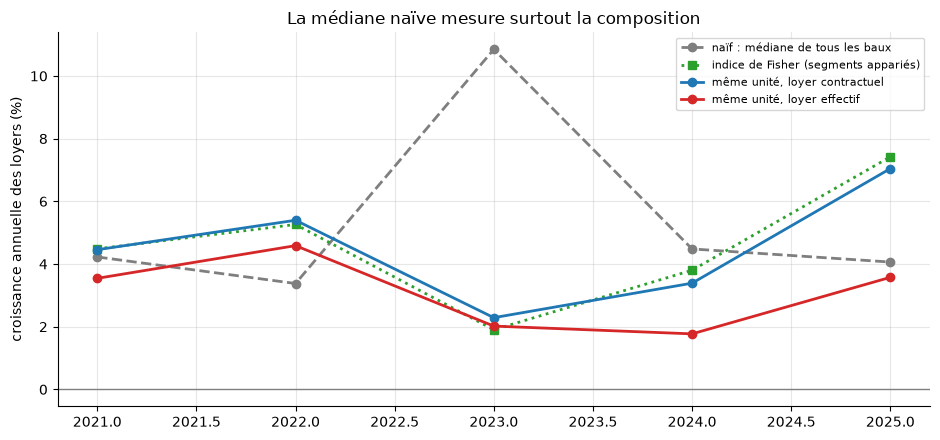

In [20]:
fig, ax = plt.subplots(figsize=STYLE.figsize_wide)
years_shown = list(range(CONFIG.extended_backtest_years[0], CONFIG.last_observed_year + 1))
ax.plot(years_shown, naive.loc[years_shown, "yoy_pct"], "o--", color=PALETTE["naive"], lw=STYLE.line_width, label="naïf : médiane de tous les baux")
ax.plot(years_shown, fisher.loc[years_shown], "s:", color=PALETTE["market"], lw=STYLE.line_width, label="indice de Fisher (segments appariés)")
ax.plot(years_shown, same_unit.loc[years_shown, ("contractuel", "median")], "o-", color=PALETTE["contract"], lw=STYLE.line_width, label="même unité, loyer contractuel")
ax.plot(years_shown, same_unit.loc[years_shown, ("effectif", "median")], "o-", color=PALETTE["effective"], lw=STYLE.line_width, label="même unité, loyer effectif")
ax.axhline(0, color="grey", lw=STYLE.line_width / 2)
ax.set(ylabel="croissance annuelle des loyers (%)", title="La médiane naïve mesure surtout la composition")
ax.legend(fontsize=STYLE.legend_fontsize)
plt.tight_layout()
plt.show()

In [21]:
contract_median = same_unit[("contractuel", "median")]
effective_median = same_unit[("effectif", "median")]
trough_year = int(contract_median.loc[CONFIG.extended_backtest_years[0]:].idxmin())
narrate(f"**Lecture.** Les trois méthodes sans effet de mix (Fisher, même unité contractuel, même unité effectif) racontent la même histoire : "
        f"un creux en {trough_year} ({fmt(contract_median[trough_year])} % au contractuel), puis une accélération en {CONFIG.last_observed_year} "
        f"pour le contractuel ({fmt(contract_median[CONFIG.last_observed_year])} %) que l'effectif n'accompagne qu'en partie "
        f"({fmt(effective_median[CONFIG.last_observed_year])} %, voir section 5). La médiane naïve invente un pic en {naive_peak_year}.")

**Lecture.** Les trois méthodes sans effet de mix (Fisher, même unité contractuel, même unité effectif) racontent la même histoire : un creux en 2023 (2,3 % au contractuel), puis une accélération en 2025 pour le contractuel (7,0 %) que l'effectif n'accompagne qu'en partie (3,6 %, voir section 5). La médiane naïve invente un pic en 2023.

### 4d. Sensibilité : le résultat dépend-il des filtres ?
On fait varier trois choix (fenêtre d'écart, traitement des extrêmes, agrégateur). Si la hausse de 2025 bouge peu, le résultat ne vient pas d'un filtre arbitraire ; sinon on dit lequel.

In [22]:
gap_windows = {f"{fmt(low, CONFIG.table_digits)}–{fmt(high, CONFIG.table_digits)} ans": (low, high)
               for low, high in ((CONFIG.pair_gap_min_years, CONFIG.pair_gap_max_years),) + CONFIG.sensitivity_gap_windows}
outlier_policies = {"none": "aucun", "winsorise": f"winsorisation {fmt(CONFIG.winsor_share * 100)} %",
                    "trim": f"rognage {fmt(CONFIG.outlier_tail_share * 100)} % de chaque côté"}
aggregators = ("médiane", "moyenne", "moyenne pondérée")


def apply_outlier_policy(values, policy):
    if policy == "none":
        return values
    if policy == "winsorise":
        low, high = values.quantile([CONFIG.winsor_share, 1 - CONFIG.winsor_share])
        return values.clip(low, high)
    low, high = values.quantile([CONFIG.outlier_tail_share, 1 - CONFIG.outlier_tail_share])
    return values.where(values.between(low, high))


def sensitivity_table(rent_kind, years):
    rows = []
    for window_name, (gap_low, gap_high) in gap_windows.items():
        base = pairs_all[pairs_all.gap_years.gt(gap_low) & pairs_all.gap_years.lt(gap_high) & ~pairs_all.flag_nonpositive_rent]
        for policy, policy_label in outlier_policies.items():
            values = apply_outlier_policy(base[f"growth_{rent_kind}_pct"], policy)
            for aggregator in aggregators:
                row = {"fenêtre": window_name, "extrêmes": policy_label, "agrégateur": aggregator}
                for year in years:
                    sample = values[base.lease_year == year].dropna()
                    weights = base.loc[sample.index, f"prev_rent_{rent_kind}"]
                    row[year] = {"médiane": sample.median(), "moyenne": sample.mean(), "moyenne pondérée": np.average(sample, weights=weights)}[aggregator]
                rows.append(row)
    return pd.DataFrame(rows)


sensitivity_contract = sensitivity_table("contract", CONFIG.backtest_years)
sensitivity_effective = sensitivity_table("effective", CONFIG.backtest_years)
n_combinations = len(sensitivity_contract)
last_year_range = pd.DataFrame({
    "contractuel": [sensitivity_contract[CONFIG.last_observed_year].min(), sensitivity_contract[CONFIG.last_observed_year].max()],
    "effectif": [sensitivity_effective[CONFIG.last_observed_year].min(), sensitivity_effective[CONFIG.last_observed_year].max()]},
    index=[f"minimum sur les {n_combinations} combinaisons", f"maximum sur les {n_combinations} combinaisons"])
print(f"Amplitude de la hausse {CONFIG.last_observed_year} selon les filtres :")
print(last_year_range.round(CONFIG.table_digits))
sensitivity_contract.round(CONFIG.table_digits)

Amplitude de la hausse 2025 selon les filtres :
                                 contractuel  effectif
minimum sur les 27 combinaisons         7.00      3.39
maximum sur les 27 combinaisons         7.70      3.87


,fenêtre,extrêmes,agrégateur,2023,2024,2025
0,"0,50–2,50 ans",aucun,médiane,2.29,3.39,7.04
1,"0,50–2,50 ans",aucun,moyenne,2.09,3.73,7.56
2,"0,50–2,50 ans",aucun,moyenne pondérée,2.13,3.71,7.54
3,"0,50–2,50 ans","winsorisation 1,0 %",médiane,2.29,3.39,7.04
4,"0,50–2,50 ans","winsorisation 1,0 %",moyenne,2.13,3.73,7.46
5,"0,50–2,50 ans","winsorisation 1,0 %",moyenne pondérée,2.16,3.71,7.45
6,"0,50–2,50 ans","rognage 0,5 % de chaque côté",médiane,2.32,3.39,7.00
7,"0,50–2,50 ans","rognage 0,5 % de chaque côté",moyenne,2.18,3.73,7.36
8,"0,50–2,50 ans","rognage 0,5 % de chaque côté",moyenne pondérée,2.20,3.71,7.34
9,"0,75–1,50 ans",aucun,médiane,2.30,3.42,7.09


In [23]:
previous_years_max = sensitivity_contract[list(CONFIG.backtest_years[:-1])].max().max()
gap_range = (sensitivity_contract[CONFIG.last_observed_year] - sensitivity_effective[CONFIG.last_observed_year])
aggregator_shift = (sensitivity_contract[sensitivity_contract.agrégateur == "moyenne pondérée"][CONFIG.last_observed_year].mean()
                    - sensitivity_contract[sensitivity_contract.agrégateur == "médiane"][CONFIG.last_observed_year].mean())
narrate(f"**Lecture.** Sur les {n_combinations} combinaisons, la hausse contractuelle {CONFIG.last_observed_year} va de "
        f"{fmt(last_year_range.iloc[0, 0])} à {fmt(last_year_range.iloc[1, 0])} %, toujours au-dessus du maximum des années de comparaison "
        f"({CONFIG.backtest_years[0]}-{CONFIG.backtest_years[-2]} : {fmt(previous_years_max)} %) ; l'écart contractuel − effectif reste entre {fmt(gap_range.min())} et {fmt(gap_range.max())} points. "
        f"L'agrégateur déplace le niveau d'environ {fmt(aggregator_shift, signed=True)} point (moyenne pondérée contre médiane) : nous publions la médiane "
        "(comparable au notebook de départ) et la moyenne pondérée comme contrôle.")

**Lecture.** Sur les 27 combinaisons, la hausse contractuelle 2025 va de 7,0 à 7,7 %, toujours au-dessus du maximum des années de comparaison (2023-2024 : 3,8 %) ; l'écart contractuel − effectif reste entre 3,5 et 4,0 points. L'agrégateur déplace le niveau d'environ +0,4 point (moyenne pondérée contre médiane) : nous publions la médiane (comparable au notebook de départ) et la moyenne pondérée comme contrôle.

In [24]:
# Contrôles de validité (parité avec le notebook de départ) --------------------------------------------------
starter_style = pairs_all[pairs_all.gap_years.between(CONFIG.pair_gap_min_years, CONFIG.pair_gap_max_years, inclusive="neither")]
assert len(starter_style) == len(pairs), "notre filtre = celui du notebook de départ"
assert abs(same_unit.loc[CONFIG.last_observed_year, ("contractuel", "median")] - CONFIG.starter_contract_median_2025) < CONFIG.check_tolerance, "médiane contractuelle 2025 du départ"
assert abs(same_unit.loc[CONFIG.last_observed_year, ("effectif", "median")] - CONFIG.starter_effective_median_2025) < CONFIG.check_tolerance, "médiane effective 2025 du départ"
assert len(fake_pairs) > 0, "la mauvaise clé doit produire de fausses paires"
assert last_year_range.iloc[0, 0] > previous_years_max, "la hausse contractuelle 2025 dépasse les années précédentes quel que soit le filtre"
print("Contrôles de la section 4 : OK")

Contrôles de la section 4 : OK


## 5. Loyer contractuel n'est pas loyer perçu

`rent_contract` est le loyer inscrit au bail ; `rent_effective` est ce que `Équinoxe` perçoit réellement après les concessions. Cette section (a) **vérifie ce que sont les lignes de concession** (en particulier `PromoPay`), (b) **reconstruit** `rent_effective` à partir de ces lignes pour décider auquel des deux loyers se fier, (c) **explique pourquoi la croissance contractuelle et la croissance effective divergent à partir de 2024**.

### 5a. Que sont les codes de concession ?
Pour un montant `amount` (négatif : un rabais) couvrant `months_covered` mois, l'équivalent mensuel sur la durée du bail est `−amount × months_covered / term_months`. Pour `PromoPay`, l'énoncé annonce un frais *mensuel*. Nous mesurons ce que la colonne contient réellement avant de la modéliser.

**Étape qui crée une table** : `linked`, chaque ligne de concession rattachée à son bail, avec la colonne `amount_over_monthly_rent`.

In [25]:
concessions = concessions.reset_index(drop=True)
linked = link_concession_lines(concessions, leases, CONFIG.concession_link_grace_days)
linked["amount_over_monthly_rent"] = -linked.amount / linked.rent_contract

code_profile = linked.groupby("charge_code").agg(
    lines=("amount", "size"), median_amount=("amount", "median"), median_months_covered=("months_covered", "median"),
    median_amount_over_monthly_rent=("amount_over_monthly_rent", "median")).sort_values("lines", ascending=False)
print(f"{len(linked):,} lignes de concession rattachées à un bail sur {len(concessions):,} ({len(linked) / len(concessions):.1%}).")
code_profile

3,560 lignes de concession rattachées à un bail sur 3,560 (100.0%).


,lines,median_amount,median_months_covered,median_amount_over_monthly_rent
charge_code,,,,
PromoPay,1494,"-1,356.60",1.00,0.80
freepark,1006,-150.50,12.00,0.08
Freeothe,570,-153.49,12.00,0.08
freelock,175,-139.35,12.00,0.07
freerent,166,-129.30,12.00,0.07
Indem,69,-149.26,12.00,0.06
freeappl,44,-143.58,12.00,0.08
Referenc,36,-148.25,12.00,0.08


In [26]:
promo_profile = code_profile.loc["PromoPay"]
other_codes = code_profile.drop(index="PromoPay")
narrate(f"**Lecture.** `PromoPay` couvre en médiane **{fmt(promo_profile.median_months_covered, 0)} mois** pour un montant égal à "
        f"**{fmt(promo_profile.median_amount_over_monthly_rent, CONFIG.table_digits)} fois le loyer mensuel** : c'est un **forfait unique**, pas un frais mensuel. "
        f"Les autres codes ({', '.join(f'`{code}`' for code in other_codes.index)}) sont de petits montants mensuels "
        f"({fmt(-other_codes.median_amount.max(), 0)} à {fmt(-other_codes.median_amount.min(), 0)} $ en médiane) sur toute la durée du bail. "
        f"Rattachement : une ligne appartient au *dernier bail commencé au plus tard {CONFIG.concession_link_grace_days} jours après son début* "
        "(une concession peut débuter un peu avant le bail ; le test de la section 5b montre que ce délai maximise la concordance).")

**Lecture.** `PromoPay` couvre en médiane **1 mois** pour un montant égal à **0,80 fois le loyer mensuel** : c'est un **forfait unique**, pas un frais mensuel. Les autres codes (`freepark`, `Freeothe`, `freelock`, `freerent`, `Indem`, `freeappl`, `Referenc`) sont de petits montants mensuels (129 à 153 $ en médiane) sur toute la durée du bail. Rattachement : une ligne appartient au *dernier bail commencé au plus tard 30 jours après son début* (une concession peut débuter un peu avant le bail ; le test de la section 5b montre que ce délai maximise la concordance).

### 5b. Reconstruire le loyer effectif
On étale chaque ligne sur la durée du bail (`PromoPay` en forfait unique divisé par la durée) et on compare à l'écart réel `rent_contract − rent_effective`. Puis on fait varier le délai de rattachement : la valeur retenue dans `CONFIG` doit être celle qui maximise la concordance (paramètre **estimé**, pas choisi).

In [27]:
reconstructed = linked.groupby("lease_id").monthly_equivalent.sum()
reconstruction = leases[["lease_id", "lease_year", "rent_contract", "rent_effective", "has_concession"]].copy()
reconstruction["reconstructed_discount"] = reconstruction.lease_id.map(reconstructed).fillna(0.0)
reconstruction["actual_discount"] = reconstruction.rent_contract - reconstruction.rent_effective
reconstruction["error"] = reconstruction.reconstructed_discount - reconstruction.actual_discount
has_promo = set(linked[linked.charge_code == "PromoPay"].lease_id)
reconstruction["has_promopay"] = reconstruction.lease_id.isin(has_promo)

close = reconstruction.error.abs() <= CONFIG.exact_tolerance_dollars
close_label = f"reconstruits à ≤ {fmt(CONFIG.exact_tolerance_dollars, 0)} $"
summary_reconstruction = pd.DataFrame({
    "baux": reconstruction.groupby("has_promopay").size(),
    close_label: close.groupby(reconstruction.has_promopay).sum(),
    "part (%)": close.groupby(reconstruction.has_promopay).mean() * 100}).rename(index={False: "sans PromoPay", True: "avec PromoPay"})
summary_reconstruction.loc["tous"] = [len(reconstruction), close.sum(), close.mean() * 100]
print(summary_reconstruction.round(CONFIG.prose_digits).to_string())
print(f"\nConcordance par année de début de bail (part des baux {close_label}) :")
print((close.groupby(reconstruction.lease_year).mean() * 100).round(CONFIG.prose_digits).to_dict())


def reconstruction_share(grace_days):
    attached = link_concession_lines(concessions, leases, grace_days)
    discount = attached.groupby("lease_id").monthly_equivalent.sum().reindex(leases.lease_id).fillna(0.0)
    return float((np.abs(discount.to_numpy() - (leases.rent_contract - leases.rent_effective).to_numpy()) <= CONFIG.exact_tolerance_dollars).mean())


grace_test = pd.Series({days: reconstruction_share(days) * 100 for days in CONFIG.concession_grace_days_tested}, name=f"part des baux {close_label} (%)")
grace_test.index.name = "tolérance de rattachement (jours)"
print(grace_test.round(CONFIG.prose_digits).to_string())
assert grace_test.idxmax() == CONFIG.concession_link_grace_days, "la tolérance retenue doit maximiser la concordance"

                  baux  reconstruits à ≤ 1 $  part (%)
has_promopay                                          
sans PromoPay 2,967.00              2,918.00     98.30
avec PromoPay 1,335.00                940.00     70.40
tous          4,302.00              3,858.00     89.70

Concordance par année de début de bail (part des baux reconstruits à ≤ 1 $) :
{2017: 94.6, 2018: 94.8, 2019: 93.3, 2020: 93.3, 2021: 90.0, 2022: 91.7, 2023: 90.5, 2024: 88.4, 2025: 85.3}
tolérance de rattachement (jours)
0    61.30
15   68.80
30   89.70
45   89.10
60   87.70
90   85.30


In [28]:
promo_failures = (~close & reconstruction.has_promopay).sum() / (~close).sum()
narrate(f"**Lecture.** **{fmt(close.mean() * 100)} % des baux se reconstruisent à moins de {fmt(CONFIG.exact_tolerance_dollars, 0)} $** à partir des lignes, "
        "ce qui confirme (1) ce que mesure `rent_effective` (loyer contractuel moins les concessions étalées sur le bail) et (2) la lecture « forfait unique » de `PromoPay`. "
        f"Les écarts restants concernent des baux avec `PromoPay` dans {fmt(promo_failures * 100, 0)} % des cas (le moment exact du forfait dans le bail n'est pas toujours "
        f"étalé comme nous le supposons). **Décision :** nous utilisons `rent_effective` (champ calculé par Yardi, validé à {fmt(close.mean() * 100, 0)} % par notre "
        "reconstruction) pour toutes les analyses effectives, et nous gardons la reconstruction comme preuve de compréhension.")

**Lecture.** **89,7 % des baux se reconstruisent à moins de 1 $** à partir des lignes, ce qui confirme (1) ce que mesure `rent_effective` (loyer contractuel moins les concessions étalées sur le bail) et (2) la lecture « forfait unique » de `PromoPay`. Les écarts restants concernent des baux avec `PromoPay` dans 89 % des cas (le moment exact du forfait dans le bail n'est pas toujours étalé comme nous le supposons). **Décision :** nous utilisons `rent_effective` (champ calculé par Yardi, validé à 90 % par notre reconstruction) pour toutes les analyses effectives, et nous gardons la reconstruction comme preuve de compréhension.

**Que se passe-t-il si l'on prend la description au pied de la lettre ?** Un `PromoPay` mensuel pendant toute la durée du bail ferait payer presque rien aux locataires : la lecture littérale est absurde, ce que le test suivant chiffre (**étape qui crée** la table `promo_lines`, les seules lignes `PromoPay`).

In [29]:
promo_lines = linked[linked.charge_code == "PromoPay"]
literal_monthly_discount = promo_lines.groupby("lease_id").apply(lambda g: (-g.amount).sum(), include_groups=False)    # lecture littérale : le montant s'applique chaque mois
literal = leases.set_index("lease_id").loc[literal_monthly_discount.index]
literal_share_of_rent = literal_monthly_discount / literal.rent_contract
amortised_share = promo_lines.assign(share=lambda d: d.monthly_equivalent / d.rent_contract).groupby("lease_id").share.sum()
print(f"Baux avec PromoPay : {len(promo_lines.lease_id.unique()):,}")
print(f"  lecture littérale (le montant s'applique CHAQUE mois) : rabais médian = {literal_share_of_rent.median():.0%} du loyer mensuel (≈ loyer gratuit)")
print(f"  lecture forfait unique étalé sur le bail             : rabais médian = {amortised_share.median():.1%} du loyer mensuel")
assert close.mean() > CONFIG.min_reconstruction_share, f"la reconstruction doit confirmer rent_effective sur au moins {CONFIG.min_reconstruction_share:.0%} des baux"

Baux avec PromoPay : 1,335
  lecture littérale (le montant s'applique CHAQUE mois) : rabais médian = 91% du loyer mensuel (≈ loyer gratuit)
  lecture forfait unique étalé sur le bail             : rabais médian = 7.9% du loyer mensuel


### 5c. Pourquoi contractuel et effectif divergent à partir de 2024
Trois mesures annuelles : la **pénétration** (part des baux avec concession), la **profondeur** (rabais moyen parmi les baux qui en ont) et le **drag** (rabais moyen sur tous les baux) `= pénétration × profondeur`.

In [30]:
def concession_profile_by(frame, by):
    grouped = frame.groupby(by)
    return pd.DataFrame({
        "leases": grouped.size(),
        "penetration_pct": grouped.has_concession.mean() * 100,
        "depth_pct": grouped.apply(lambda g: g.loc[g.drag > 0, "drag"].mean() * 100, include_groups=False),
        "drag_pct": grouped.drag.mean() * 100})


profile_by_year = concession_profile_by(leases, "lease_year")
display(profile_by_year.round(CONFIG.table_digits))
profile_by_year_type = concession_profile_by(leases[leases.lease_year >= CONFIG.extended_backtest_years[0]], ["lease_year", "is_renewal"])
display(profile_by_year_type.round(CONFIG.table_digits))
recent_leases = leases[leases.lease_year >= CONFIG.backtest_years[0]]
quarterly_drag = recent_leases.groupby(recent_leases.lease_start.dt.to_period("Q")).agg(leases=("drag", "size"), drag_pct=("drag", lambda s: s.mean() * 100))
display(quarterly_drag.round(CONFIG.table_digits).T)

,leases,penetration_pct,depth_pct,drag_pct
lease_year,,,,
2017,93,38.71,3.05,1.18
2018,172,38.37,3.53,1.36
2019,328,44.21,3.85,1.70
2020,373,48.79,4.28,2.09
2021,361,54.02,4.98,2.69
2022,422,57.35,5.80,3.33
2023,693,54.26,6.59,3.58
2024,902,73.06,7.81,5.71
2025,958,85.39,10.69,9.13


leases  penetration_pct  depth_pct  drag_pct
lease_year is_renewal                                              
2021       0              136            54.41       4.87      2.65
           1              225            53.78       5.04      2.71
2022       0              190            54.21       5.72      3.10
           1              232            59.91       5.86      3.51
2023       0              447            57.94       6.57      3.81
           1              246            47.56       6.64      3.16
2024       0              474            77.22       7.81      6.03
           1              428            68.46       7.82      5.35
2025       0              475            82.11      10.73      8.81
           1              483            88.61      10.67      9.45

lease_start,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4
leases,115.00,175.00,260.00,143.00,161.00,249.00,301.00,191.00,142.00,272.00,340.00,204.00
drag_pct,3.54,2.97,3.78,3.97,5.99,5.72,5.64,5.56,9.19,9.16,9.02,9.24


In [31]:
quarter_year = quarterly_drag.index.year
within_year_spread = quarterly_drag.drag_pct.groupby(quarter_year).std().mean()
between_year_spread = quarterly_drag.drag_pct.groupby(quarter_year).mean().std()
renewal_drag = profile_by_year_type.drag_pct.unstack("is_renewal")
recent_years = list(CONFIG.backtest_years)
narrate(f"**Lecture.** Le drag est une **fonction en escalier de l'année** : "
        f"{' ; '.join(f'{year} : {fmt(profile_by_year.drag_pct[year])} %' for year in recent_years)}. "
        f"Dans une même année il est stable d'un trimestre à l'autre (écart-type moyen entre trimestres : {fmt(within_year_spread, CONFIG.table_digits)} point, "
        f"contre {fmt(between_year_spread, CONFIG.table_digits)} entre années) : c'est une **politique annuelle** de concessions. "
        f"Il augmente à la fois par la pénétration ({' → '.join(fmt(profile_by_year.penetration_pct[year], 0) + ' %' for year in recent_years)}) "
        f"et par la profondeur ({' → '.join(fmt(profile_by_year.depth_pct[year]) + ' %' for year in recent_years)}). "
        f"Les renouvellements, d'abord moins concernés ({fmt(renewal_drag.loc[recent_years[0], 1])} % contre {fmt(renewal_drag.loc[recent_years[0], 0])} % en {recent_years[0]}), "
        f"rejoignent les relocations en {recent_years[-1]} ({fmt(renewal_drag.loc[recent_years[-1], 1])} % contre {fmt(renewal_drag.loc[recent_years[-1], 0])} %).")

**Lecture.** Le drag est une **fonction en escalier de l'année** : 2023 : 3,6 % ; 2024 : 5,7 % ; 2025 : 9,1 %. Dans une même année il est stable d'un trimestre à l'autre (écart-type moyen entre trimestres : 0,24 point, contre 2,82 entre années) : c'est une **politique annuelle** de concessions. Il augmente à la fois par la pénétration (54 % → 73 % → 85 %) et par la profondeur (6,6 % → 7,8 % → 10,7 %). Les renouvellements, d'abord moins concernés (3,2 % contre 3,8 % en 2023), rejoignent les relocations en 2025 (9,5 % contre 8,8 %).

**Décomposition exacte de l'écart contractuel − effectif.** Pour une paire, `(1 + g_eff) = (1 + g_contrat) × ((1 − drag) / (1 − drag_précédent)) ^ (1/gap)` : l'écart de croissance vaut à peu près le **changement du drag**. On décompose ce changement en part due à la pénétration et part due à la profondeur (moyennes de point milieu, la somme est exacte).

In [32]:
drag_change = profile_by_year[["penetration_pct", "depth_pct", "drag_pct"]].copy() / 100
changes = drag_change.diff()
midpoints = (drag_change + drag_change.shift(1)) / 2
divergence = pd.DataFrame({
    "contractuel (médiane)": same_unit[("contractuel", "median")],
    "effectif (médiane)": same_unit[("effectif", "median")]})
divergence["écart (points)"] = divergence.iloc[:, 0] - divergence.iloc[:, 1]
divergence["Δ drag (points)"] = changes.drag_pct * 100
divergence["… dû à la pénétration"] = changes.penetration_pct * midpoints.depth_pct * 100
divergence["… dû à la profondeur"] = midpoints.penetration_pct * changes.depth_pct * 100
divergence = divergence.loc[CONFIG.first_year + 1:CONFIG.last_observed_year]
assert np.allclose(divergence["… dû à la pénétration"] + divergence["… dû à la profondeur"], divergence["Δ drag (points)"]), "la décomposition doit se refermer"
divergence.round(CONFIG.table_digits)

,contractuel (médiane),effectif (médiane),écart (points),Δ drag (points),… dû à la pénétration,… dû à la profondeur
lease_year,,,,,,
2020,3.17,3.02,0.15,0.38,0.19,0.20
2021,4.46,3.54,0.91,0.60,0.24,0.36
2022,5.40,4.59,0.81,0.64,0.18,0.46
2023,2.29,2.02,0.27,0.25,-0.19,0.44
2024,3.39,1.77,1.62,2.13,1.35,0.78
2025,7.04,3.58,3.47,3.43,1.14,2.28


In [33]:
pre_divergence = divergence.loc[:CONFIG.backtest_years[0], "écart (points)"].abs().max()
year_mid, year_last = CONFIG.backtest_years[1], CONFIG.backtest_years[2]
narrate(f"**Lecture.** Jusqu'en {CONFIG.backtest_years[0]}, les deux croissances sont à au plus {fmt(pre_divergence)} point l'une de l'autre. "
        f"Ensuite l'écart suit le **changement du drag** : en {year_mid}, le drag gagne {fmt(divergence.loc[year_mid, 'Δ drag (points)'])} points "
        f"(dont {fmt(divergence.loc[year_mid, '… dû à la pénétration'])} par la pénétration) ; en {year_last}, {fmt(divergence.loc[year_last, 'Δ drag (points)'])} points "
        f"({fmt(divergence.loc[year_last, '… dû à la pénétration'])} par la pénétration, {fmt(divergence.loc[year_last, '… dû à la profondeur'])} par la profondeur), "
        f"et l'écart contractuel − effectif vaut alors {fmt(divergence.loc[year_last, 'écart (points)'])} points. L'écart ne reproduit pas exactement le Δ drag "
        "parce que la médiane des paires n'est pas la moyenne des baux : l'identité est exacte pour chaque paire, approximative pour une médiane. "
        "**Les propriétaires ont relevé les loyers inscrits au bail et ont redonné une partie de la différence en concessions.**\n\n"
        "**Lequel citer à un propriétaire ?** Le **loyer effectif** pour budgéter les revenus (il additionne ce qui est réellement encaissé) ; le **loyer contractuel** "
        "pour le TAL et pour les lettres de renouvellement (c'est lui qui est encadré). Nous retenons l'effectif comme définition principale et publions les deux.")

**Lecture.** Jusqu'en 2023, les deux croissances sont à au plus 0,9 point l'une de l'autre. Ensuite l'écart suit le **changement du drag** : en 2024, le drag gagne 2,1 points (dont 1,4 par la pénétration) ; en 2025, 3,4 points (1,1 par la pénétration, 2,3 par la profondeur), et l'écart contractuel − effectif vaut alors 3,5 points. L'écart ne reproduit pas exactement le Δ drag parce que la médiane des paires n'est pas la moyenne des baux : l'identité est exacte pour chaque paire, approximative pour une médiane. **Les propriétaires ont relevé les loyers inscrits au bail et ont redonné une partie de la différence en concessions.**

**Lequel citer à un propriétaire ?** Le **loyer effectif** pour budgéter les revenus (il additionne ce qui est réellement encaissé) ; le **loyer contractuel** pour le TAL et pour les lettres de renouvellement (c'est lui qui est encadré). Nous retenons l'effectif comme définition principale et publions les deux.

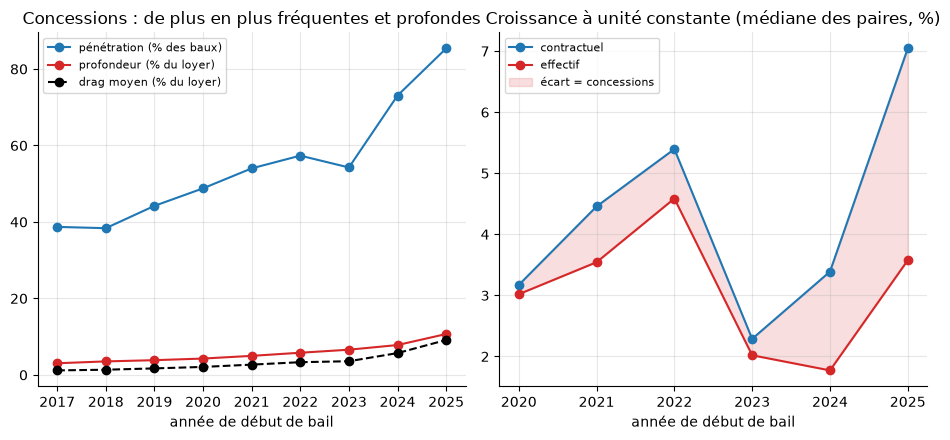

In [34]:
fig, axes = plt.subplots(1, 2, figsize=STYLE.figsize_wide)
years_profile = profile_by_year.index
axes[0].plot(years_profile, profile_by_year.penetration_pct, "o-", color=PALETTE["contract"], label="pénétration (% des baux)")
axes[0].plot(years_profile, profile_by_year.depth_pct, "o-", color=PALETTE["effective"], label="profondeur (% du loyer)")
axes[0].plot(years_profile, profile_by_year.drag_pct, "o--", color="black", label="drag moyen (% du loyer)")
axes[0].set(title="Concessions : de plus en plus fréquentes et profondes", xlabel="année de début de bail")
axes[0].legend(fontsize=STYLE.legend_fontsize)
years_gap = divergence.index
axes[1].plot(years_gap, divergence["contractuel (médiane)"], "o-", color=PALETTE["contract"], label="contractuel")
axes[1].plot(years_gap, divergence["effectif (médiane)"], "o-", color=PALETTE["effective"], label="effectif")
axes[1].fill_between(years_gap, divergence["effectif (médiane)"], divergence["contractuel (médiane)"], color=PALETTE["effective"], alpha=STYLE.band_alpha, label="écart = concessions")
axes[1].set(title="Croissance à unité constante (médiane des paires, %)", xlabel="année de début de bail")
axes[1].legend(fontsize=STYLE.legend_fontsize)
plt.tight_layout()
plt.show()

## 6. Renouvellements et relocations : deux régimes, deux provinces

`is_renewal = 1` : un locataire en place renouvelle. `is_renewal = 0` : l'unité se libère et est relouée.

**Québec (Code civil du Québec et règlement du TAL).** La hausse d'un locataire en place n'a pas de plafond : le propriétaire propose une hausse par avis ; si le locataire la refuse, le propriétaire peut demander au Tribunal administratif du logement (TAL) de fixer le loyer selon le *Règlement sur les critères de fixation de loyer*. Jusqu'en 2025, le TAL publiait chaque janvier une **estimation moyenne d'augmentation** (« ancienne méthode », ici le logement non chauffé) ; depuis 2026, le règlement fixe un **pourcentage de base** (« nouvelle méthode ») pour les avis donnés à compter du 1er janvier 2026. Pour un **nouveau locataire**, le propriétaire doit déclarer le loyer le plus bas payé dans les 12 mois précédant le début du bail (art. 1896 C.c.Q., sauf dans un immeuble visé à l'art. 1955) et le locataire peut demander au Tribunal de fixer le loyer dans les 10 jours de la conclusion du bail (deux mois du début du bail si la déclaration n'a pas été remise ; art. 1950) : la relocation est donc libre en pratique, mais pas sans recours. Enfin, **dans les cinq années qui suivent la date où l'immeuble est prêt pour l'usage**, ni le locateur ni le locataire ne peut faire fixer le loyer par le Tribunal, si le bail le prévoit (section F) et, pour un immeuble prêt depuis le 21 février 2024, s'il indique le loyer maximal des cinq ans (art. 1955) ; le locataire qui refuse la hausse doit alors quitter le logement (art. 1945) et la déclaration de l'art. 1896 ne s'applique pas. C'est le cas potentiel des propriétés mises en service récemment (test en 6c bis).

**Ontario.** Un plafond annuel (la *ligne directrice*) encadre les locataires en place **sauf pour les unités occupées pour la première fois à des fins résidentielles après le 15 novembre 2018** ; la **relocation est libre** (« vacancy decontrol »). Tous les immeubles de l'extrait sont au Québec, sauf The Met (Ontario). **Nous n'appliquons jamais la règle d'une province à l'autre.**

**Étape qui ajoute des données** : on charge ici les tableaux publics tidy (`external`, `cpi_monthly`), produits par `external/fetch.py` ; chaque ligne porte sa source, sa date de retrait et `published_on`, la première date où la valeur était publique. Le détail et la réconciliation sont en section 8.

In [35]:
external = pd.read_csv(CONFIG.external_dir / "external_annual.csv", parse_dates=["published_on"])
cpi_monthly = pd.read_csv(CONFIG.external_dir / "cpi_rent_monthly.csv", parse_dates=["month", "published_on"])


def external_series(series, geo=None):
    """Série annuelle publique indexée par année (valeur la plus récente si plusieurs lignes)."""
    rows = external[external.series == series]
    if geo is not None:
        rows = rows[rows.geo == geo]
    return rows.drop_duplicates("year", keep="last").set_index("year").value.sort_index()


TAL_OLD = external_series("tal_recommended_unheated_old_method", "Quebec")      # ancienne méthode : estimation moyenne d'augmentation, logement non chauffé
TAL_NEW_FORMAT = external_series("tal_base_percentage_new_format", "Quebec")    # nouvelle méthode : pourcentage de base (2025 recalculé, puis 2026)
ONTARIO_GUIDELINE = external_series("on_rent_guideline", "Ontario")
print("TAL, ancienne méthode (estimation moyenne, non chauffé) :", TAL_OLD.to_dict())
print("TAL, nouvelle méthode (pourcentage de base) :", TAL_NEW_FORMAT.to_dict())
print("Ontario, ligne directrice (jusqu'à l'année prévue) :", ONTARIO_GUIDELINE.loc[CONFIG.first_year:CONFIG.forecast_year].to_dict())

TAL, ancienne méthode (estimation moyenne, non chauffé) : {2021: 0.8, 2022: 1.28, 2023: 2.3, 2024: 4.0, 2025: 5.9}
TAL, nouvelle méthode (pourcentage de base) : {2025: 4.5, 2026: 3.1}
Ontario, ligne directrice (jusqu'à l'année prévue) : {2019: 1.8, 2020: 2.2, 2021: 0.0, 2022: 1.2, 2023: 2.5, 2024: 2.5, 2025: 2.5, 2026: 2.1}


### 6a. Croissance à unité constante : province × renouvellement
Tableau 2 × 2 (médiane des paires, loyer contractuel). L'Ontario n'a de paires qu'à partir de 2024, car The Met ouvre en 2023.

In [36]:
split = (pairs[pairs.lease_year >= CONFIG.extended_backtest_years[0]]
         .assign(type=lambda d: np.where(d.is_renewal == 1, "renouvellement", "relocation"))
         .groupby(["province", "type", "lease_year"])
         .agg(pairs=("growth_contract_pct", "size"), contract=("growth_contract_pct", "median"), effective=("growth_effective_pct", "median")))
split_contract = split.unstack("lease_year")["contract"]
display(split_contract.round(CONFIG.table_digits))
display(split.unstack("lease_year")["pairs"])

lease_year               2021  2022  2023  2024  2025
province type                                        
Ontario  relocation       NaN   NaN   NaN  4.94  8.96
         renouvellement   NaN   NaN   NaN  2.97  6.25
Quebec   relocation      3.52  4.22  1.85  4.84  8.98
         renouvellement  4.77  5.69  2.58  2.94  6.43

lease_year                2021   2022   2023   2024   2025
province type                                             
Ontario  relocation        NaN    NaN    NaN  41.00  54.00
         renouvellement    NaN    NaN    NaN  67.00  63.00
Quebec   relocation     135.00 126.00 177.00 235.00 253.00
         renouvellement 220.00 226.00 239.00 355.00 410.00

In [37]:
qc_split = split_contract.loc["Quebec"]
on_split = split_contract.loc["Ontario"].dropna(axis=1, how="all")
renewal_led_years = [year for year in qc_split.columns if qc_split.loc["renouvellement", year] > qc_split.loc["relocation", year]]
relocation_led_years = [year for year in qc_split.columns if year not in renewal_led_years]
narrate(f"**Lecture.** Au Québec, les renouvellements mènent en {', '.join(map(str, renewal_led_years))} et les relocations en "
        f"{', '.join(map(str, relocation_led_years))} ; en {CONFIG.last_observed_year}, relocations {fmt(qc_split.loc['relocation', CONFIG.last_observed_year])} % "
        f"contre renouvellements {fmt(qc_split.loc['renouvellement', CONFIG.last_observed_year])} %. L'Ontario (The Met) suit presque exactement le Québec : "
        + " ; ".join(f"{year} : renouvellements {fmt(on_split.loc['renouvellement', year])} % (Québec {fmt(qc_split.loc['renouvellement', year])} %), "
                     f"relocations {fmt(on_split.loc['relocation', year])} % (Québec {fmt(qc_split.loc['relocation', year])} %)" for year in on_split.columns) + ".")

**Lecture.** Au Québec, les renouvellements mènent en 2021, 2022, 2023 et les relocations en 2024, 2025 ; en 2025, relocations 9,0 % contre renouvellements 6,4 %. L'Ontario (The Met) suit presque exactement le Québec : 2024 : renouvellements 3,0 % (Québec 2,9 %), relocations 4,9 % (Québec 4,8 %) ; 2025 : renouvellements 6,2 % (Québec 6,4 %), relocations 9,0 % (Québec 9,0 %).

### 6b. Mettre la règle sur le graphique
Les renouvellements québécois sont comparés à l'**estimation moyenne du TAL** (ancienne méthode) ; ceux de l'Ontario à la ligne directrice (tracée en pointillé : non contraignante si l'immeuble est exempté, voir 6d). **Deux conventions d'année pour le TAL**, testées plutôt que supposées : (a) *année civile* (le taux publié en janvier de `t` pour l'année `t`) ; (b) *fenêtre de validité* : un taux publié en janvier de `t` couvre les baux débutant du 2 avril de `t` au 1er avril de `t+1`, donc les baux débutant du 1er janvier au 1er avril de `t` relèvent encore du taux de l'année précédente (`tal_window_first_month`, `tal_window_first_day`).

In [38]:
def starts_in_previous_tal_window(start_dates):
    """Vrai si le bail débute avant le premier jour de la fenêtre de validité du taux de son année : il relève du taux de l'année précédente."""
    month, day = start_dates.dt.month, start_dates.dt.day
    return (month < CONFIG.tal_window_first_month) | ((month == CONFIG.tal_window_first_month) & (day < CONFIG.tal_window_first_day))


renewals_qc = pairs[(pairs.province == "Quebec") & (pairs.is_renewal == 1)]
tal_window_share = starts_in_previous_tal_window(renewals_qc.lease_start).mean()   # mesuré dans les données, pas supposé
print(f"Part des renouvellements québécois qui relèvent du taux de l'année précédente (début avant le {CONFIG.tal_window_first_day}/{CONFIG.tal_window_first_month}) : "
      f"{tal_window_share:.1%}")

tal_window = tal_window_share * TAL_OLD.shift(1, fill_value=np.nan) + (1 - tal_window_share) * TAL_OLD
qc_renewal_median = renewals_qc.groupby("lease_year").growth_contract_pct.median()
rule_test_years = [year for year in qc_renewal_median.index if year in TAL_OLD.index and year - 1 in TAL_OLD.index]
rule_test = pd.DataFrame({
    "renouvellements QC (médiane)": qc_renewal_median.loc[rule_test_years],
    "TAL année civile": TAL_OLD.loc[rule_test_years],
    "TAL fenêtre de validité": tal_window.loc[rule_test_years]})
rule_test["écart (année civile)"] = rule_test.iloc[:, 0] - rule_test.iloc[:, 1]
rule_test["écart (fenêtre)"] = rule_test.iloc[:, 0] - rule_test.iloc[:, 2]
rule_test_mae = pd.DataFrame({
    f"{min(years)}-{max(years)}": {"année civile": rule_test.loc[years, "écart (année civile)"].abs().mean(), "fenêtre": rule_test.loc[years, "écart (fenêtre)"].abs().mean()}
    for years in (rule_test_years, [year for year in rule_test_years if year >= CONFIG.backtest_years[0]])}).T
display(rule_test_mae.round(CONFIG.table_digits))
rule_test.round(CONFIG.table_digits)

Part des renouvellements québécois qui relèvent du taux de l'année précédente (début avant le 2/4) : 17.7%


,année civile,fenêtre
2022-2025,1.57,1.64
2023-2025,0.62,0.69


,renouvellements QC (médiane),TAL année civile,TAL fenêtre de validité,écart (année civile),écart (fenêtre)
2022,5.69,1.28,1.20,4.41,4.49
2023,2.58,2.30,2.12,0.28,0.46
2024,2.94,4.00,3.70,-1.06,-0.76
2025,6.43,5.90,5.56,0.53,0.87


In [39]:
first_rule_year = rule_test_years[0]
recent_rule_years = [year for year in rule_test_years if year >= CONFIG.backtest_years[0]]
narrate(f"**Lecture.** En {first_rule_year}, les renouvellements ({fmt(rule_test.loc[first_rule_year].iloc[0])} %) dépassent de loin l'estimation du TAL "
        f"({fmt(rule_test.loc[first_rule_year].iloc[1])} %) ; à partir de {recent_rule_years[0]}, l'écart reste sous "
        f"{fmt(rule_test.loc[recent_rule_years, 'écart (année civile)'].abs().max())} point. Seuls {fmt(tal_window_share * 100, 0)} % des renouvellements "
        f"débutent avant la fenêtre de validité de l'année, donc les deux conventions donnent des erreurs du même ordre ({fmt(rule_test_mae.iloc[-1, 0], CONFIG.table_digits)} contre "
        f"{fmt(rule_test_mae.iloc[-1, 1], CONFIG.table_digits)} point sur {rule_test_mae.index[-1]}). **La prévision applique la fenêtre de validité** : "
        "c'est la règle de droit, et c'est elle qui permet de dater correctement le changement de méthode de 2026 (section 10d). "
        "L'ancrage TAL est utile pour les renouvellements récents, **pas une loi de la nature** : il n'explique pas les années antérieures.")

**Lecture.** En 2022, les renouvellements (5,7 %) dépassent de loin l'estimation du TAL (1,3 %) ; à partir de 2023, l'écart reste sous 1,1 point. Seuls 18 % des renouvellements débutent avant la fenêtre de validité de l'année, donc les deux conventions donnent des erreurs du même ordre (0,62 contre 0,69 point sur 2023-2025). **La prévision applique la fenêtre de validité** : c'est la règle de droit, et c'est elle qui permet de dater correctement le changement de méthode de 2026 (section 10d). L'ancrage TAL est utile pour les renouvellements récents, **pas une loi de la nature** : il n'explique pas les années antérieures.

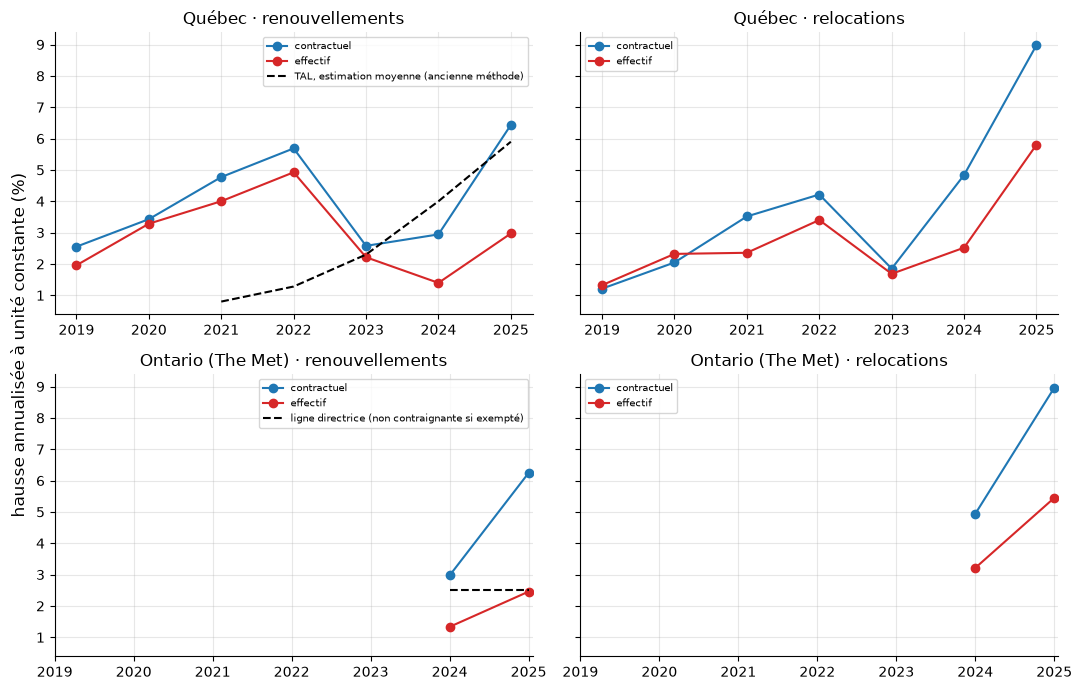

In [40]:
fig, axes = plt.subplots(2, 2, figsize=STYLE.figsize_grid, sharey=True)
panels = [("Quebec", 1, "Québec · renouvellements", TAL_OLD), ("Quebec", 0, "Québec · relocations", None),
          ("Ontario", 1, "Ontario (The Met) · renouvellements", ONTARIO_GUIDELINE), ("Ontario", 0, "Ontario (The Met) · relocations", None)]
for ax, (province, renewal_flag, title, rule) in zip(axes.ravel(), panels):
    subset = pairs[(pairs.province == province) & (pairs.is_renewal == renewal_flag) & (pairs.lease_year >= CONFIG.first_year)]
    by_year = subset.groupby("lease_year").agg(contract=("growth_contract_pct", "median"), effective=("growth_effective_pct", "median"))
    ax.plot(by_year.index, by_year.contract, "o-", color=PALETTE["contract"], label="contractuel")
    ax.plot(by_year.index, by_year.effective, "o-", color=PALETTE["effective"], label="effectif")
    if rule is not None:
        shown = rule.loc[by_year.index.min():by_year.index.max()]
        ax.plot(shown.index, shown, "k--", label="TAL, estimation moyenne (ancienne méthode)" if province == "Quebec" else "ligne directrice (non contraignante si exempté)")
    ax.set(title=title)
    ax.set_xticks(range(CONFIG.first_year, CONFIG.last_observed_year + 1))
    ax.legend(fontsize=STYLE.small_fontsize)
fig.supylabel("hausse annualisée à unité constante (%)")
plt.tight_layout()
plt.show()

### 6c. Part de renouvellements (poids du mélange)
Le poids des renouvellements dans la cohorte sert de pondération à la prévision (section 10) ; vérifions qu'il est stable.

In [41]:
renewal_share = pairs.groupby(["province", "lease_year"]).is_renewal.mean().unstack("province").loc[CONFIG.first_year:] * 100
renewal_share.round(CONFIG.prose_digits)

province,Ontario,Quebec
lease_year,,
2019,NaN,57.90
2020,NaN,60.40
2021,NaN,62.00
2022,NaN,64.20
2023,NaN,57.50
2024,62.00,60.20
2025,53.80,61.80


In [42]:
qc_share = renewal_share["Quebec"]
narrate(f"**Lecture.** La part de renouvellements au Québec reste entre {fmt(qc_share.min(), 0)} et {fmt(qc_share.max(), 0)} % depuis {CONFIG.first_year} "
        f"(écart-type {fmt(qc_share.std())} point) : on peut l'estimer sur les dernières années sans craindre une dérive. "
        "Sa variabilité d'une année à l'autre fait partie de l'erreur mesurée par le backtest (section 10d).")

**Lecture.** La part de renouvellements au Québec reste entre 57 et 64 % depuis 2019 (écart-type 2,4 point) : on peut l'estimer sur les dernières années sans craindre une dérive. Sa variabilité d'une année à l'autre fait partie de l'erreur mesurée par le backtest (section 10d).

### 6c bis. Article 1955 : les immeubles de cinq ans ou moins renouvellent-ils autrement ?
Si la société profitait de l'exemption de l'art. 1955 (pas de fixation par le Tribunal dans un immeuble récent), les renouvellements des propriétés récentes devraient être plus élevés que ceux des propriétés plus anciennes la même année. **Approximation assumée :** la loi compte cinq ans à partir de la date où l'immeuble est prêt pour l'usage, que l'extrait ne donne pas ; nous comptons les années civiles depuis le premier bail de la propriété dans l'extrait (`entry_year`, section 3), et nous ne savons pas si les baux contiennent la mention de la section F.

In [43]:
qc_renewal_pairs = renewals_qc[renewals_qc.lease_year >= CONFIG.backtest_years[0]].assign(
    property_age=lambda d: d.lease_year - d.prop_code.map(entry_year))
qc_renewal_pairs["recent_property"] = qc_renewal_pairs.property_age <= CONFIG.new_building_age_years
age_test = qc_renewal_pairs.groupby(["lease_year", "recent_property"]).growth_contract_pct.agg(["median", "size"]).unstack("recent_property")
age_test.columns = [f"{statistic} ({'récente' if recent else 'ancienne'})" for statistic, recent in age_test.columns]
age_test["écart récente − ancienne (points)"] = age_test["median (récente)"] - age_test["median (ancienne)"]
age_test.round(CONFIG.table_digits)

,median (ancienne),median (récente),size (ancienne),size (récente),écart récente − ancienne (points)
lease_year,,,,,
2023,2.57,2.58,65,174,0.02
2024,2.69,3.04,97,258,0.35
2025,6.54,6.38,178,232,-0.16


In [44]:
narrate(f"**Lecture.** L'écart entre propriétés récentes et anciennes reste entre {fmt(age_test.iloc[:, -1].min(), CONFIG.table_digits, signed=True)} et "
        f"{fmt(age_test.iloc[:, -1].max(), CONFIG.table_digits, signed=True)} point selon l'année : **la société applique une seule politique de renouvellement**, "
        "que l'immeuble puisse ou non échapper à la fixation par le Tribunal. C'est le même constat qu'à Ottawa (6d) et c'est ce qui justifie, en section 10, "
        "un ancrage de renouvellement commun à toutes les propriétés.")

**Lecture.** L'écart entre propriétés récentes et anciennes reste entre −0,16 et +0,35 point selon l'année : **la société applique une seule politique de renouvellement**, que l'immeuble puisse ou non échapper à la fixation par le Tribunal. C'est le même constat qu'à Ottawa (6d) et c'est ce qui justifie, en section 10, un ancrage de renouvellement commun à toutes les propriétés.

### 6d. L'immeuble d'Ottawa selon les règles de l'Ontario (bonus)
**Constat qui pourrait passer pour une erreur.** Les renouvellements de The Met dépassent nettement la ligne directrice ontarienne (chiffres ci-dessous). Un propriétaire soumis au plafond ne pourrait pas la dépasser sans ordonnance. Ce n'est pas une erreur des données : **The Met est exempté** (tour résidentielle livrée en 2023 derrière une façade patrimoniale ; premier bail de l'extrait en 2023, donc usage résidentiel pour la première fois après le 15 novembre 2018 : sources en section 13 et dans `external/SOURCES.md` ; hypothèse à confirmer auprès du propriétaire, d'où le régime plafonné gardé en contrefactuel). On le démontre par trois tests.

In [45]:
met_pairs = pairs[pairs.prop_code == "metcalfe"]
met_renewals = met_pairs[met_pairs.is_renewal == 1].copy()
met_renewals["guideline_pct"] = met_renewals.lease_year.map(ONTARIO_GUIDELINE)
exemption_cutoff = pd.Timestamp(CONFIG.ontario_exemption_cutoff)
first_lease_met = leases[leases.prop_code == "metcalfe"].lease_start.min()
min_months_between = CONFIG.ontario_min_months_between_increases - CONFIG.month_tolerance_between_increases
regime_test = met_renewals.groupby("lease_year").apply(lambda g: pd.Series({
    "renouvellements": len(g), "médiane (%)": g.growth_contract_pct.median(), "ligne directrice (%)": g.guideline_pct.iloc[0],
    "part au-dessus de la ligne directrice": (g.growth_contract_pct > g.guideline_pct).mean(),
    f"part ≥ {CONFIG.ontario_min_months_between_increases} mois entre deux hausses": ((g.lease_start - g.prev_lease_start).dt.days / CONFIG.days_per_year * CONFIG.months_per_year >= min_months_between).mean()}),
    include_groups=False)
print(f"Test 1, date d'occupation : premier bail de The Met = {first_lease_met:%Y-%m-%d} ; seuil d'exemption = {exemption_cutoff:%Y-%m-%d} → "
      f"{'EXEMPTÉ' if first_lease_met > exemption_cutoff else 'ASSUJETTI'}")
display(regime_test.round(CONFIG.table_digits))
met_vs_cpi = pd.DataFrame({"The Met, renouvellements (%)": regime_test["médiane (%)"],
                           "IPC loyers Ontario (moyenne annuelle, %)": external_series("cpi_rent_avg_yoy", "Ontario").loc[regime_test.index],
                           "ligne directrice (%)": regime_test["ligne directrice (%)"]})
met_vs_cpi.round(CONFIG.table_digits)

Test 1, date d'occupation : premier bail de The Met = 2023-01-01 ; seuil d'exemption = 2018-11-15 → EXEMPTÉ


,renouvellements,médiane (%),ligne directrice (%),part au-dessus de la ligne directrice,part ≥ 12 mois entre deux hausses
lease_year,,,,,
2024,67.00,2.97,2.50,0.63,1.00
2025,63.00,6.25,2.50,1.00,1.00


,"The Met, renouvellements (%)","IPC loyers Ontario (moyenne annuelle, %)",ligne directrice (%)
lease_year,,,
2024,2.97,6.90,2.50
2025,6.25,4.30,2.50


In [46]:
spacing_column = regime_test.columns[-1]
narrate(f"**Lecture des trois tests.**\n"
        f"1. **Date d'occupation :** premier bail le {first_lease_met:%Y-%m-%d}, postérieur au {exemption_cutoff:%Y-%m-%d} → la ligne directrice **ne s'applique pas**. "
        f"Les hausses de renouvellement ({', '.join(fmt(value) + ' %' for value in regime_test['médiane (%)'])}) sont donc légales.\n"
        f"2. **Comportement :** {', '.join(fmt(share * 100, 0) + ' %' for share in regime_test['part au-dessus de la ligne directrice'])} des renouvellements de The Met "
        f"dépassent la ligne directrice ({', '.join(map(str, regime_test.index))}) : le plafond ne lie pas. Ils sont **presque identiques aux renouvellements québécois** "
        f"({', '.join(fmt(qc_split.loc['renouvellement', year]) + ' %' for year in regime_test.index)}) et ne suivent **ni** la ligne directrice **ni** l'IPC loyers "
        f"de l'Ontario ({', '.join(fmt(value) + ' %' for value in met_vs_cpi.iloc[:, 1])}) : la politique d'augmentation est celle de la société, appliquée à un immeuble exempté.\n"
        f"3. **Règle des {CONFIG.ontario_min_months_between_increases} mois :** {', '.join(fmt(share * 100, 0) + ' %' for share in regime_test[spacing_column])} des hausses "
        "d'une même unité sont espacées d'au moins douze mois, à un mois près (la règle est respectée en pratique ; l'avis de 90 jours n'est pas observable dans les données).\n\n"
        f"**Conséquence pour la prévision {CONFIG.forecast_year}.** Régime central : *exempté*. The Met reçoit la **politique de la société** (l'ancrage de renouvellement commun, 6c bis), "
        "parce que c'est ce que ses données montrent ; **aucune règle du Québec n'est appliquée à Ottawa en droit**, et nous n'avons pas d'entrée de marché propre à Ottawa "
        f"pour ses relocations (limite assumée, section 12). Régime contrefactuel : renouvellements plafonnés à la ligne directrice {CONFIG.forecast_year} "
        f"({fmt(ONTARIO_GUIDELINE[CONFIG.forecast_year])} %). L'écart entre les deux est la **valeur de l'exemption** (section 11d). "
        "**La ligne directrice de l'Ontario n'est jamais appliquée aux cinq immeubles du Québec.**")

**Lecture des trois tests.**
1. **Date d'occupation :** premier bail le 2023-01-01, postérieur au 2018-11-15 → la ligne directrice **ne s'applique pas**. Les hausses de renouvellement (3,0 %, 6,2 %) sont donc légales.
2. **Comportement :** 63 %, 100 % des renouvellements de The Met dépassent la ligne directrice (2024, 2025) : le plafond ne lie pas. Ils sont **presque identiques aux renouvellements québécois** (2,9 %, 6,4 %) et ne suivent **ni** la ligne directrice **ni** l'IPC loyers de l'Ontario (6,9 %, 4,3 %) : la politique d'augmentation est celle de la société, appliquée à un immeuble exempté.
3. **Règle des 12 mois :** 100 %, 100 % des hausses d'une même unité sont espacées d'au moins douze mois, à un mois près (la règle est respectée en pratique ; l'avis de 90 jours n'est pas observable dans les données).

**Conséquence pour la prévision 2026.** Régime central : *exempté*. The Met reçoit la **politique de la société** (l'ancrage de renouvellement commun, 6c bis), parce que c'est ce que ses données montrent ; **aucune règle du Québec n'est appliquée à Ottawa en droit**, et nous n'avons pas d'entrée de marché propre à Ottawa pour ses relocations (limite assumée, section 12). Régime contrefactuel : renouvellements plafonnés à la ligne directrice 2026 (2,1 %). L'écart entre les deux est la **valeur de l'exemption** (section 11d). **La ligne directrice de l'Ontario n'est jamais appliquée aux cinq immeubles du Québec.**

In [47]:
# Contrôles de validité ----------------------------------------------------------------------------------------
assert first_lease_met > exemption_cutoff, "The Met doit être postérieur au seuil d'exemption"
assert set(pairs[pairs.province == "Ontario"].prop_code) == {"metcalfe"}, "seul The Met est en Ontario"
assert (pairs.groupby("prop_code").province.nunique() == 1).all(), "une province par code de propriété"
print("Contrôles de la section 6 : OK")

Contrôles de la section 6 : OK


## 7. Choisir la définition : tableau comparatif

La section 1 a annoncé le choix ; voici **la preuve**. Les cinq définitions sont calculées sur les mêmes données et notées selon des critères explicites, au lieu de plaider dans l'abstrait.

| Critère | Question | Mesure |
|---|---|---|
| **Insensibilité au mix** | Le nombre bouge-t-il quand le portefeuille change ? | écart moyen sur les années du backtest entre la version « tous immeubles » et la version « panel fixe » |
| **Bruit** | Quelle précision ? | largeur de l'intervalle (`ci_low`–`ci_high`) d'un bootstrap **par unité** (les paires d'une même unité sont corrélées) la dernière année |
| **Prévisibilité** | Peut-on le prévoir ? | erreur absolue moyenne de deux références simples (reconduction de l'an dernier, moyenne des `recent_years_for_mean` dernières années) |
| **Lecture réglementaire** | Comparable au TAL ou à la ligne directrice ? | oui seulement pour le loyer contractuel des renouvellements |
| **Usage de décision** | Quelle ligne budgétaire ? | loyer encaissé (budget) ou loyer au bail (lettres de renouvellement) |
| **Soutien des données** | Combien de paires ? | nombre de paires la dernière année |

**Cette étape ajoute une colonne** à `pairs` : `unit_label` (`prop_code|unit_code`), l'identifiant de grappe du bootstrap.

In [48]:
pairs["unit_label"] = pairs.prop_code + "|" + pairs.unit_code
panel_pairs = pairs[pairs.prop_code.isin(panel_codes)]
DEFINITIONS = {
    "1. même unité, contractuel": lambda frame: frame.groupby("lease_year").growth_contract_pct.median(),
    "2. même unité, effectif (RETENU)": lambda frame: frame.groupby("lease_year").growth_effective_pct.median(),
    "3. renouvellements seulement (contractuel)": lambda frame: frame[frame.is_renewal == 1].groupby("lease_year").growth_contract_pct.median(),
    "4. relocations seulement (contractuel)": lambda frame: frame[frame.is_renewal == 0].groupby("lease_year").growth_contract_pct.median(),
}
NAIVE_DEFINITION = "5. médiane du portefeuille (contre-exemple)"
definition_series_all = {name: function(pairs) for name, function in DEFINITIONS.items()}
definition_series_panel = {name: function(panel_pairs) for name, function in DEFINITIONS.items()}
definition_series_all[NAIVE_DEFINITION] = naive.yoy_pct
definition_series_panel[NAIVE_DEFINITION] = panel_yoy
definition_table = pd.DataFrame(definition_series_all).loc[CONFIG.extended_backtest_years[0]:CONFIG.last_observed_year]
definition_table.round(CONFIG.table_digits)

,"1. même unité, contractuel","2. même unité, effectif (RETENU)",3. renouvellements seulement (contractuel),4. relocations seulement (contractuel),5. médiane du portefeuille (contre-exemple)
lease_year,,,,,
2021,4.46,3.54,4.77,3.52,4.23
2022,5.40,4.59,5.69,4.22,3.38
2023,2.29,2.02,2.58,1.85,10.85
2024,3.39,1.77,2.94,4.85,4.48
2025,7.04,3.58,6.41,8.98,4.06


In [49]:
def cluster_bootstrap_median(values, unit_labels, n_draws, rng):
    """Bootstrap de la médiane en rééchantillonnant les UNITÉS (pas les paires) : médiane pondérée par tirage multinomial."""
    labels, inverse = np.unique(unit_labels, return_inverse=True)
    order = np.argsort(values)
    sorted_values, sorted_inverse = values[order], inverse[order]
    counts = rng.multinomial(len(labels), np.full(len(labels), 1 / len(labels)), size=n_draws)
    cumulative = np.cumsum(counts[:, sorted_inverse], axis=1)
    half = cumulative[:, -1:] / 2
    return sorted_values[(cumulative < half).sum(axis=1)]


def interval_width(draws):
    low, high = np.percentile(draws, [CONFIG.ci_low, CONFIG.ci_high])
    return high - low


bootstrap_rng = np.random.default_rng(CONFIG.random_seed)
last_year_pairs = pairs[pairs.lease_year == CONFIG.last_observed_year]
last_year_subsets = {
    "1. même unité, contractuel": (last_year_pairs, "growth_contract_pct"),
    "2. même unité, effectif (RETENU)": (last_year_pairs, "growth_effective_pct"),
    "3. renouvellements seulement (contractuel)": (last_year_pairs[last_year_pairs.is_renewal == 1], "growth_contract_pct"),
    "4. relocations seulement (contractuel)": (last_year_pairs[last_year_pairs.is_renewal == 0], "growth_contract_pct")}
bootstrap_width = {name: interval_width(cluster_bootstrap_median(frame[column].to_numpy(), frame.unit_label.to_numpy(), CONFIG.n_bootstrap, bootstrap_rng))
                   for name, (frame, column) in last_year_subsets.items()}
# le portefeuille naïf se rééchantillonne par bail, en recalculant la variation de médiane entre les deux dernières années
previous_rents = leases[leases.lease_year == CONFIG.last_observed_year - 1].rent_contract.to_numpy()
current_rents = leases[leases.lease_year == CONFIG.last_observed_year].rent_contract.to_numpy()
naive_draws = [(np.median(bootstrap_rng.choice(current_rents, len(current_rents))) / np.median(bootstrap_rng.choice(previous_rents, len(previous_rents))) - 1) * 100
               for _ in range(CONFIG.n_bootstrap)]
bootstrap_width[NAIVE_DEFINITION] = interval_width(naive_draws)


def persistence_and_recent_mean_mae(series, years):
    errors_persistence = [series[year] - series[year - 1] for year in years]
    errors_recent_mean = [series[year] - series.loc[:year - 1].tail(CONFIG.recent_years_for_mean).mean() for year in years]
    return np.mean(np.abs(errors_persistence)), np.mean(np.abs(errors_recent_mean))


interval_label = f"intervalle {CONFIG.ci_low:.0f}-{CONFIG.ci_high:.0f} % en {CONFIG.last_observed_year} (points)"
recent_mean_label = f"erreur « moyenne des {CONFIG.recent_years_for_mean} dernières années »"
scorecard = pd.DataFrame(index=list(definition_series_all))
scorecard["écart tous immeubles vs panel fixe (points)"] = [
    float(np.mean([abs(definition_series_all[name][year] - definition_series_panel[name][year]) for year in CONFIG.backtest_years])) for name in scorecard.index]
scorecard[interval_label] = pd.Series(bootstrap_width)
mae_pairs = {name: persistence_and_recent_mean_mae(definition_series_all[name].dropna(), CONFIG.extended_backtest_years) for name in scorecard.index}
scorecard["erreur « reconduire l'an dernier »"] = [mae_pairs[name][0] for name in scorecard.index]
scorecard[recent_mean_label] = [mae_pairs[name][1] for name in scorecard.index]
scorecard[f"paires en {CONFIG.last_observed_year}"] = [len(last_year_subsets[name][0]) if name in last_year_subsets else int((leases.lease_year == CONFIG.last_observed_year).sum())
                                                       for name in scorecard.index]
scorecard["lisible face au TAL / Ontario"] = ["partiellement (mélange)", "non", "oui (renouvellements)", "non (marché libre)", "non"]
scorecard["usage de décision"] = ["lettres de renouvellement", "budget des revenus encaissés", "lettres de renouvellement", "prix de relocation", "aucun (mesure le mix)"]
scorecard.round(CONFIG.table_digits)

,écart tous immeubles vs panel fixe (points),intervalle 10-90 % en 2025 (points),erreur « reconduire l'an dernier »,erreur « moyenne des 3 dernières années »,paires en 2025,lisible face au TAL / Ontario,usage de décision
"1. même unité, contractuel",0.04,0.25,2.02,2.01,780,partiellement (mélange),lettres de renouvellement
"2. même unité, effectif (RETENU)",0.06,0.38,1.24,1.46,780,non,budget des revenus encaissés
3. renouvellements seulement (contractuel),0.04,0.14,1.84,2.00,473,oui (renouvellements),lettres de renouvellement
4. relocations seulement (contractuel),0.01,0.38,2.33,2.49,307,non (marché libre),prix de relocation
5. médiane du portefeuille (contre-exemple),4.12,4.66,3.35,2.59,958,non,aucun (mesure le mix)


In [50]:
same_unit_names = list(DEFINITIONS)
mix_column = "écart tous immeubles vs panel fixe (points)"
naive_errors = scorecard.loc[same_unit_names, ["erreur « reconduire l'an dernier »", recent_mean_label]]
narrate(f"**Lecture du tableau.**\n"
        f"* **Mix :** les définitions à unité constante bougent d'au plus {fmt(scorecard.loc[same_unit_names, mix_column].max(), CONFIG.table_digits)} point entre "
        f"« tous immeubles » et « panel fixe » ; la médiane du portefeuille bouge de **{fmt(scorecard.loc[NAIVE_DEFINITION, mix_column])} points** : c'est le contre-exemple, à ne pas citer.\n"
        f"* **Bruit :** les intervalles des définitions à unité constante vont de {fmt(scorecard.loc[same_unit_names, interval_label].min(), CONFIG.table_digits)} à "
        f"{fmt(scorecard.loc[same_unit_names, interval_label].max(), CONFIG.table_digits)} point ; celui de la médiane du portefeuille vaut "
        f"{fmt(scorecard.loc[NAIVE_DEFINITION, interval_label])} points, en plus d'être trompeur.\n"
        f"* **Prévisibilité :** les références naïves se trompent de {fmt(naive_errors.min().min())} à {fmt(naive_errors.max().max())} points sur "
        f"{CONFIG.extended_backtest_years[0]}-{CONFIG.extended_backtest_years[-1]} selon la définition, parce que la série change de régime. Cela annonce la difficulté "
        "de la prévision (section 10) et justifie d'utiliser les règles et le marché plutôt que la seule tendance.\n"
        "* **Décision :** le **loyer effectif** répond à la question budgétaire (« combien de plus encaisserons-nous par unité ? ») ; le **contractuel** répond à la question "
        "réglementaire. Aucune des deux ne remplace l'autre, d'où la publication des deux.\n\n"
        "**Choix final.** Définition principale = **définition 2** (même unité, loyer effectif, médiane des paires, renouvellements et relocations). Définition secondaire = "
        "**définition 1** (même unité, loyer contractuel) avec les définitions 3 et 4 en détail. La définition 5 sert de contre-exemple pédagogique.")

**Lecture du tableau.**
* **Mix :** les définitions à unité constante bougent d'au plus 0,06 point entre « tous immeubles » et « panel fixe » ; la médiane du portefeuille bouge de **4,1 points** : c'est le contre-exemple, à ne pas citer.
* **Bruit :** les intervalles des définitions à unité constante vont de 0,14 à 0,38 point ; celui de la médiane du portefeuille vaut 4,7 points, en plus d'être trompeur.
* **Prévisibilité :** les références naïves se trompent de 1,2 à 2,5 points sur 2021-2025 selon la définition, parce que la série change de régime. Cela annonce la difficulté de la prévision (section 10) et justifie d'utiliser les règles et le marché plutôt que la seule tendance.
* **Décision :** le **loyer effectif** répond à la question budgétaire (« combien de plus encaisserons-nous par unité ? ») ; le **contractuel** répond à la question réglementaire. Aucune des deux ne remplace l'autre, d'où la publication des deux.

**Choix final.** Définition principale = **définition 2** (même unité, loyer effectif, médiane des paires, renouvellements et relocations). Définition secondaire = **définition 1** (même unité, loyer contractuel) avec les définitions 3 et 4 en détail. La définition 5 sert de contre-exemple pédagogique.

### 7b. Choix de forme, testés
* **Année :** début de bail (`lease_start`) contre année de signature : le tableau ci-dessous mesure ce que le choix déplace.
* **Agrégateur :** médiane (robuste, celle du départ) ; la moyenne pondérée par le loyer précédent (un budget additionne des dollars) est publiée en contrôle (section 4d).

In [51]:
sign_year_pairs = pairs.assign(sign_year=pairs.sign_date.dt.year)
year_attribution = pd.DataFrame({
    "année de début de bail (retenue)": pairs.groupby("lease_year").growth_effective_pct.median(),
    "année de signature": sign_year_pairs.groupby("sign_year").growth_effective_pct.median()}).loc[CONFIG.first_year:CONFIG.last_observed_year]
year_attribution["écart (points)"] = year_attribution.iloc[:, 1] - year_attribution.iloc[:, 0]
signing_lag_days = (leases.lease_start - leases.sign_date).dt.days
print(f"Délai signature → début de bail : médiane {signing_lag_days.median():.0f} jours, maximum {signing_lag_days.max():.0f} jours.")
year_attribution.round(CONFIG.table_digits)

Délai signature → début de bail : médiane 38 jours, maximum 75 jours.


,année de début de bail (retenue),année de signature,écart (points)
2019,1.63,1.47,-0.16
2020,3.02,3.14,0.12
2021,3.54,3.60,0.05
2022,4.59,4.55,-0.04
2023,2.02,1.96,-0.06
2024,1.77,1.96,0.19
2025,3.58,3.56,-0.02


In [52]:
assert definition_table.loc[CONFIG.last_observed_year, "2. même unité, effectif (RETENU)"] < definition_table.loc[CONFIG.last_observed_year, "1. même unité, contractuel"], "l'effectif doit être sous le contractuel en 2025"
assert scorecard.loc[NAIVE_DEFINITION, mix_column] > CONFIG.mix_sensitivity_ratio * scorecard.loc["1. même unité, contractuel", mix_column], "le contre-exemple doit être très sensible au mix"
print("Contrôles de la section 7 : OK")

Contrôles de la section 7 : OK


## 8. Données publiques et réconciliation avec la tendance interne

**Ce que nous intégrons** (tout est public ; sources, licences et date de retrait dans `external/SOURCES.md`) :
* **IPC, composante loyers** (Statistique Canada, tableau 18-10-0004-01) : Québec, Ontario, Canada, mensuel jusqu'au dernier mois publié avant la date de retrait ;
* **SCHL, enquête sur les logements locatifs** (republiée par Statistique Canada, tableaux 34-10-0130-01 et 34-10-0133-01) : inoccupation et loyer moyen par nombre de chambres, RMR de Montréal et d'Ottawa-Gatineau (partie ontarienne) ;
* **TAL** (estimation moyenne de l'ancienne méthode et pourcentage de base de la nouvelle) et **ligne directrice de l'Ontario** (section 6) ;
* chiffres titres de la SCHL 2025 et mise à jour de mi-année 2026 (loyers affichés, roulement), saisis à la main avec leur URL.

**Règle d'or du backtest.** Chaque ligne porte `published_on`. La prévision d'une année `t` ne peut utiliser que les valeurs publiées **au plus tard à sa date de coupure** (section 10) : le taux du TAL de l'année `t`, publié en janvier de `t`, n'est *pas* connu au 31 décembre de `t−1`.

*Jeu Kaggle suggéré (« 25 000 loyers canadiens, juin 2024 »)* : non utilisé, parce qu'il exige un compte et ne couvre qu'un instantané de juin 2024 ; la SCHL fournit des niveaux par chambres avec dix ans d'historique, ce qui est plus utile à la réconciliation.

In [53]:
series_inventory = (external.groupby("series").agg(
    geographies=("geo", lambda geos: ", ".join(sorted(set(geos)))), first_year=("year", "min"), last_year=("year", "max"),
    rows=("value", "size"), earliest_publication=("published_on", "min"), confidence=("confidence", lambda c: ", ".join(sorted(set(c)))))
    .sort_index())
print(f"IPC mensuel publié jusqu'en {cpi_monthly.month.max():%Y-%m} (dernière publication : {cpi_monthly.published_on.max():%Y-%m-%d}).")
series_inventory

IPC mensuel publié jusqu'en 2026-08 (dernière publication : 2026-09-21).


,geographies,first_year,last_year,rows,earliest_publication,confidence
series,,,,,,
cmhc_asking_rent_index_2bed_q4_2025,"Montreal CMA, Ottawa CMA",2025,2025,2,2026-06-09,high
cmhc_avg_rent_beds0,"Montreal CMA, Ottawa CMA (Ontario part)",2015,2025,22,2015-12-15,high
cmhc_avg_rent_beds1,"Montreal CMA, Ottawa CMA (Ontario part)",2015,2025,22,2015-12-15,high
cmhc_avg_rent_beds2,"Montreal CMA, Ottawa CMA (Ontario part)",2015,2025,22,2015-12-15,high
cmhc_avg_rent_beds3,"Montreal CMA, Ottawa CMA (Ontario part)",2015,2025,22,2015-12-15,high
cmhc_avg_rent_growth_beds0,"Montreal CMA, Ottawa CMA (Ontario part)",2015,2025,22,2015-12-15,high
cmhc_avg_rent_growth_beds1,"Montreal CMA, Ottawa CMA (Ontario part)",2015,2025,22,2015-12-15,high
cmhc_avg_rent_growth_beds2,"Montreal CMA, Ottawa CMA (Ontario part)",2015,2025,22,2015-12-15,high
cmhc_avg_rent_growth_beds3,"Montreal CMA, Ottawa CMA (Ontario part)",2015,2025,22,2015-12-15,high


### 8a. Reconstituer des loyers affichés à unité constante (série interne de plus)
En plus des baux, les **loyers affichés** (`asking`) donnent un signal de marché propre à Équinoxe : la variation annualisée de l'affichage d'une même unité entre deux observations (au moins `asking_gap_min_years` d'écart, au plus `pair_gap_max_years`, la même fenêtre que pour les baux).

In [54]:
def same_unit_asking_growth(asking_table):
    ordered = asking_table.sort_values(UNIT_KEY + ["ask_date"]).copy()
    grouped = ordered.groupby(UNIT_KEY)
    ordered["prev_rent_ask"] = grouped.rent_ask.shift(1)
    ordered["prev_ask_date"] = grouped.ask_date.shift(1)
    ordered = ordered.dropna(subset=["prev_rent_ask"])
    ordered["gap_years"] = (ordered.ask_date - ordered.prev_ask_date).dt.days / CONFIG.days_per_year
    ordered = ordered[ordered.gap_years.between(CONFIG.asking_gap_min_years, CONFIG.pair_gap_max_years)]
    ordered["growth_pct"] = annualised_growth_pct(ordered.rent_ask, ordered.prev_rent_ask, ordered.gap_years)
    ordered["ask_year"] = ordered.ask_date.dt.year
    return ordered


asking_pairs = same_unit_asking_growth(asking)
asking_growth = asking_pairs.groupby("ask_year").growth_pct.median()
print("Croissance médiane des loyers affichés à unité constante :", asking_growth.round(CONFIG.table_digits).to_dict())

Croissance médiane des loyers affichés à unité constante : {2017: 3.3, 2018: 3.75, 2019: 2.95, 2020: 3.13, 2021: 4.37, 2022: 4.98, 2023: 3.39, 2024: 4.29, 2025: 8.05}


### 8b. Réconciliation : quelle série publique explique quel segment interne, avec quel décalage ?
Réconcilier n'est pas superposer deux courbes. Pour chaque segment interne et chaque série externe, à décalage 0 et 1 an :
* la **corrélation** ;
* l'**erreur absolue moyenne « laisser un an de côté »** du modèle `interne = externe + écart moyen` (l'écart est estimé *sans* l'année prédite) ;
* `n` années.

Avec sept points annuels, nous rapportons les erreurs et non des p-valeurs : **l'échantillon est trop petit pour de l'inférence formelle**, et nous le disons.

In [55]:
internal_series = pd.DataFrame({
    "QC renouvellements (contractuel)": qc_renewal_median,
    "QC relocations (contractuel)": pairs[(pairs.province == "Quebec") & (pairs.is_renewal == 0)].groupby("lease_year").growth_contract_pct.median(),
    "Équinoxe global (contractuel)": definition_series_all["1. même unité, contractuel"],
    "Équinoxe global (effectif)": definition_series_all["2. même unité, effectif (RETENU)"],
    "loyers affichés (même unité)": asking_growth}).loc[CONFIG.first_year:CONFIG.last_observed_year]

driver_series = pd.DataFrame({
    "TAL (année civile)": TAL_OLD,
    "IPC loyers QC (moyenne annuelle)": external_series("cpi_rent_avg_yoy", "Quebec"),
    "IPC loyers QC (déc./déc.)": external_series("cpi_rent_dec_yoy", "Quebec"),
    "SCHL Montréal : loyer moyen 2 ch. (niveau à niveau)": external_series("cmhc_avg_rent_growth_beds2", "Montreal CMA"),
}).loc[CONFIG.first_year - 1:CONFIG.last_observed_year]


def leave_one_out_mae(internal, driver):
    errors = []
    for held_out in internal.index:
        spread = (internal.drop(held_out) - driver.drop(held_out)).mean()
        errors.append(abs(internal[held_out] - (driver[held_out] + spread)))
    return float(np.mean(errors))


LOO_COLUMN = "erreur « un an de côté » (points)"
reconciliation_rows = []
for segment in internal_series:
    for driver in driver_series:
        for lag in (0, 1):
            joined = pd.concat([internal_series[segment], driver_series[driver].shift(lag)], axis=1, keys=["internal", "driver"]).dropna()
            if len(joined) < CONFIG.min_years_for_reconciliation:
                continue
            reconciliation_rows.append({
                "segment interne": segment, "série externe": driver, "décalage (ans)": lag, "n années": len(joined),
                "corrélation": joined.internal.corr(joined.driver),
                "écart moyen (interne − externe, points)": (joined.internal - joined.driver).mean(), LOO_COLUMN: leave_one_out_mae(joined.internal, joined.driver)})
reconciliation = pd.DataFrame(reconciliation_rows)
best_driver = reconciliation.sort_values(LOO_COLUMN).groupby("segment interne").head(2)
best_driver.sort_values(["segment interne", LOO_COLUMN]).round(CONFIG.table_digits)

,segment interne,série externe,décalage (ans),n années,corrélation,"écart moyen (interne − externe, points)",erreur « un an de côté » (points)
11,QC relocations (contractuel),IPC loyers QC (moyenne annuelle),1,7,0.88,0.23,1.17
8,QC relocations (contractuel),TAL (année civile),0,5,0.81,1.82,1.63
1,QC renouvellements (contractuel),TAL (année civile),1,4,0.41,2.32,1.79
6,QC renouvellements (contractuel),SCHL Montréal : loyer moyen 2 ch. (niveau à ni...,0,7,0.63,-3.54,2.29
33,loyers affichés (même unité),TAL (année civile),1,4,0.82,3.08,1.37
32,loyers affichés (même unité),TAL (année civile),0,5,0.71,2.16,1.47
17,Équinoxe global (contractuel),TAL (année civile),1,4,0.59,2.43,1.85
22,Équinoxe global (contractuel),SCHL Montréal : loyer moyen 2 ch. (niveau à ni...,0,7,0.72,-3.61,2.05
25,Équinoxe global (effectif),TAL (année civile),1,4,-0.07,0.89,1.93
31,Équinoxe global (effectif),SCHL Montréal : loyer moyen 2 ch. (niveau à ni...,1,7,-0.37,-3.15,2.46


In [56]:
best_by_segment = reconciliation.sort_values(LOO_COLUMN).groupby("segment interne").head(1).set_index("segment interne")
relocation_best = best_by_segment.loc["QC relocations (contractuel)"]
renewal_best = best_by_segment.loc["QC renouvellements (contractuel)"]
global_segments = ["Équinoxe global (contractuel)", "Équinoxe global (effectif)", "loyers affichés (même unité)"]
schl_level_growth = external_series("cmhc_avg_rent_growth_beds2", "Montreal CMA")[CONFIG.last_observed_year]
schl_same_sample = external_series("cmhc_montreal_avg_rent_change_2bed", "Montreal CMA")[CONFIG.last_observed_year]
narrate(f"**Lecture (à lire avec la réserve d'échantillon).**\n"
        f"* **Relocations du Québec : le lien le plus solide.** La meilleure série est « {relocation_best['série externe']} » avec un décalage de "
        f"{int(relocation_best['décalage (ans)'])} an (corrélation {fmt(relocation_best['corrélation'], CONFIG.table_digits)}, erreur « un an de côté » "
        f"{fmt(relocation_best[LOO_COLUMN])} point, la plus basse du tableau) : une relocation reprend le niveau du marché de l'année écoulée. C'est notre entrée de marché pour les relocations.\n"
        f"* **Renouvellements du Québec : l'ancrage TAL est récent.** La meilleure série atteint une erreur de {fmt(renewal_best[LOO_COLUMN], CONFIG.table_digits)} point sur toute la période, parce que "
        "les renouvellements ont largement dépassé le TAL au début de la période (section 6b). Nous l'utilisons comme **ancrage légal daté par l'avis** (section 10), pas comme une relation structurelle.\n"
        f"* **Global (contractuel et effectif) et loyers affichés :** les meilleures erreurs vont de {fmt(best_by_segment.loc[global_segments, LOO_COLUMN].min())} à "
        f"{fmt(best_by_segment.loc[global_segments, LOO_COLUMN].max())} points, parce que ces séries mélangent deux régimes (renouvellements encadrés, relocations libres) et "
        "les concessions. La prévision doit donc passer par les **composantes** (section 10).\n"
        f"* **Réserve sur la série SCHL.** Le « loyer moyen 2 chambres » de la SCHL est calculé *niveau à niveau* : il inclut les nouveaux immeubles, les conversions et la rotation de l'échantillon, "
        f"c'est-à-dire **le même effet de composition que celui montré en section 3** (ce que le chiffre à échantillon constant de la SCHL retire). Pour Montréal en {CONFIG.last_observed_year}, il donne {fmt(schl_level_growth, signed=True)} % "
        f"alors que le chiffre titre de la SCHL à échantillon constant est {fmt(schl_same_sample, signed=True)} %. Nous gardons la série niveau à niveau comme **entrée de réconciliation "
        "prudente** (elle a dix ans d'historique) et nous préférons le chiffre à échantillon constant quand il existe (une seule année).")

**Lecture (à lire avec la réserve d'échantillon).**
* **Relocations du Québec : le lien le plus solide.** La meilleure série est « IPC loyers QC (moyenne annuelle) » avec un décalage de 1 an (corrélation 0,88, erreur « un an de côté » 1,2 point, la plus basse du tableau) : une relocation reprend le niveau du marché de l'année écoulée. C'est notre entrée de marché pour les relocations.
* **Renouvellements du Québec : l'ancrage TAL est récent.** La meilleure série atteint une erreur de 1,79 point sur toute la période, parce que les renouvellements ont largement dépassé le TAL au début de la période (section 6b). Nous l'utilisons comme **ancrage légal daté par l'avis** (section 10), pas comme une relation structurelle.
* **Global (contractuel et effectif) et loyers affichés :** les meilleures erreurs vont de 1,4 à 1,9 points, parce que ces séries mélangent deux régimes (renouvellements encadrés, relocations libres) et les concessions. La prévision doit donc passer par les **composantes** (section 10).
* **Réserve sur la série SCHL.** Le « loyer moyen 2 chambres » de la SCHL est calculé *niveau à niveau* : il inclut les nouveaux immeubles, les conversions et la rotation de l'échantillon, c'est-à-dire **le même effet de composition que celui montré en section 3** (ce que le chiffre à échantillon constant de la SCHL retire). Pour Montréal en 2025, il donne +14,5 % alors que le chiffre titre de la SCHL à échantillon constant est +7,2 %. Nous gardons la série niveau à niveau comme **entrée de réconciliation prudente** (elle a dix ans d'historique) et nous préférons le chiffre à échantillon constant quand il existe (une seule année).

### 8c. Niveaux : Équinoxe contre le marché
Niveau moyen des loyers des baux débutant la dernière année observée, par nombre de chambres, contre le loyer moyen de la SCHL (octobre) pour la RMR de Montréal (Laval, Mont-Royal et Pointe-Claire en font partie) et la RMR d'Ottawa-Gatineau (The Met).

**Réserve sur les niveaux.** L'extrait est un sous-ensemble publié du CRM ; rien ne garantit que ses niveaux de loyer soient ceux des annonces réelles. Les primes ci-dessous ne sont donc **qu'indicatives** ; toute la méthode du notebook repose sur des **taux de variation**, jamais sur des niveaux, pour cette raison.

In [57]:
level_rows = []
for geography, province_name, cmhc_geo in [("Montréal (5 immeubles du Québec)", "Quebec", "Montreal CMA"), ("Ottawa (The Met)", "Ontario", "Ottawa CMA (Ontario part)")]:
    own = leases[(leases.province == province_name) & (leases.lease_year == CONFIG.last_observed_year)]
    for beds in CONFIG.bedroom_levels:
        own_beds = own[own.beds == beds]
        cmhc_level = external_series(f"cmhc_avg_rent_beds{beds}", cmhc_geo).get(CONFIG.last_observed_year, np.nan)
        if len(own_beds) >= CONFIG.min_cell_size and not np.isnan(cmhc_level):
            level_rows.append({"marché": geography, "chambres": beds, "baux Équinoxe": len(own_beds),
                               "loyer moyen Équinoxe ($)": own_beds.rent_contract.mean(), "loyer moyen SCHL ($)": cmhc_level,
                               "prime (%)": (own_beds.rent_contract.mean() / cmhc_level - 1) * 100})
level_table = pd.DataFrame(level_rows)
display(level_table.round(CONFIG.prose_digits))
reference_series = external_series(f"cmhc_avg_rent_beds{CONFIG.reference_bedrooms}", "Montreal CMA")
premium_label = f"prime Équinoxe {CONFIG.reference_bedrooms} ch. vs SCHL Montréal (%)"
premium_by_year = pd.Series({
    year: (leases[(leases.province == "Quebec") & (leases.lease_year == year) & (leases.beds == CONFIG.reference_bedrooms)].rent_contract.mean() / reference_series.get(year, np.nan) - 1) * 100
    for year in CONFIG.backtest_years}, name=premium_label)
premium_by_year.round(CONFIG.prose_digits).to_frame()

,marché,chambres,baux Équinoxe,loyer moyen Équinoxe ($),loyer moyen SCHL ($),prime (%)
0,Montréal (5 immeubles du Québec),1,287,"1,342.60","1,131.00",18.70
1,Montréal (5 immeubles du Québec),2,520,"2,487.70","1,346.00",84.80
2,Montréal (5 immeubles du Québec),3,20,"3,196.00","1,625.00",96.70
3,Ottawa (The Met),0,37,"2,761.20","1,332.00",107.30
4,Ottawa (The Met),1,46,"2,744.20","1,593.00",72.30
5,Ottawa (The Met),2,37,"4,845.40","1,916.00",152.90


,prime Équinoxe 2 ch. vs SCHL Montréal (%)
2023,102.30
2024,99.10
2025,84.80


In [58]:
lowest, highest = level_table.loc[level_table["prime (%)"].idxmin()], level_table.loc[level_table["prime (%)"].idxmax()]
narrate(f"**Lecture.** Équinoxe loue **au-dessus du loyer moyen du marché** : de {fmt(lowest['prime (%)'], 0, signed=True)} % ({int(lowest.chambres)} chambre(s), {lowest.marché}) "
        f"à {fmt(highest['prime (%)'], 0, signed=True)} % ({int(highest.chambres)} chambre(s), {highest.marché}). C'est attendu : la SCHL mesure l'ensemble du parc locatif "
        "(anciens immeubles compris) alors qu'Équinoxe loue des immeubles récents haut de gamme. Pour un "
        f"{CONFIG.reference_bedrooms} chambres à Montréal, la prime va de {fmt(premium_by_year.min(), 0, signed=True)} à {fmt(premium_by_year.max(), 0, signed=True)} % "
        f"de {CONFIG.backtest_years[0]} à {CONFIG.backtest_years[-1]} ; un loyer d'Équinoxe n'est donc pas « le marché ». Conséquence pour la prévision : on utilise la "
        "**variation** du marché (IPC, SCHL) comme signal, jamais son **niveau**.")

**Lecture.** Équinoxe loue **au-dessus du loyer moyen du marché** : de +19 % (1 chambre(s), Montréal (5 immeubles du Québec)) à +153 % (2 chambre(s), Ottawa (The Met)). C'est attendu : la SCHL mesure l'ensemble du parc locatif (anciens immeubles compris) alors qu'Équinoxe loue des immeubles récents haut de gamme. Pour un 2 chambres à Montréal, la prime va de +85 à +102 % de 2023 à 2025 ; un loyer d'Équinoxe n'est donc pas « le marché ». Conséquence pour la prévision : on utilise la **variation** du marché (IPC, SCHL) comme signal, jamais son **niveau**.

### 8d. Divergences : où interne et externe se contredisent, et pourquoi
Chaque divergence est chiffrée à partir des séries internes et des tableaux publics (aucune valeur tapée à la main).

In [59]:
qc_relocations = internal_series["QC relocations (contractuel)"]
cpi_rent_qc = external_series("cpi_rent_avg_yoy", "Quebec")
vacancy = {geo: external_series("cmhc_vacancy_rate", geo) for geo in ("Montreal CMA", "Ottawa CMA (Ontario part)")}
asking_index = external_series("cmhc_asking_rent_index_2bed_q4_2025", "Montreal CMA"), external_series("cmhc_asking_rent_index_2bed_q4_2025", "Ottawa CMA")
turnover = external_series("cmhc_montreal_turnover_rent_change_2bed", "Montreal CMA")[CONFIG.last_observed_year]
non_turnover = external_series("cmhc_montreal_nonturnover_rent_change_2bed", "Montreal CMA")[CONFIG.last_observed_year]
year_mid = CONFIG.backtest_years[1]
narrate(f"* **{CONFIG.last_observed_year}, relocations à {fmt(qc_relocations[CONFIG.last_observed_year], signed=True)} %** contre un loyer moyen SCHL de Montréal à "
        f"{fmt(schl_same_sample, signed=True)} % ({fmt(turnover, signed=True)} % à la relocation pour un 2 chambres, {fmt(non_turnover, signed=True)} % sans changement de locataire) : "
        "cohérent en sens, car les propriétaires du marché repartent du prix de marché à chaque relocation. Chez Équinoxe, des concessions reprennent une partie de la différence "
        f"(effectif : {fmt(effective_median[CONFIG.last_observed_year], signed=True)} %).\n"
        f"* **{year_mid}, renouvellements à {fmt(qc_renewal_median[year_mid], signed=True)} %** pendant que l'estimation du TAL valait {fmt(TAL_OLD[year_mid], signed=True)} % "
        f"et l'IPC loyers du Québec {fmt(cpi_rent_qc[year_mid], signed=True)} % : le marché général augmente plus vite que ce que la société applique à ses locataires en place.\n"
        "* **Ontario :** The Met ne suit ni la ligne directrice (exempté) ni l'IPC loyers de l'Ontario (section 6d).\n"
        f"* **Signal le plus récent :** l'indice SCHL des loyers affichés (2 chambres, base 100 au premier trimestre de 2024) vaut {fmt(asking_index[0].iloc[-1])} à Montréal et "
        f"{fmt(asking_index[1].iloc[-1])} à Ottawa au quatrième trimestre de {CONFIG.last_observed_year} (en recul à Ottawa depuis le deuxième trimestre de {CONFIG.last_observed_year} selon la SCHL), "
        f"tandis que l'inoccupation remonte (SCHL, tableau 34-10-0130, appartements et maisons en rangée : Montréal {fmt(vacancy['Montreal CMA'][year_mid])} → {fmt(vacancy['Montreal CMA'][CONFIG.last_observed_year])} % ; "
        f"Ottawa {fmt(vacancy['Ottawa CMA (Ontario part)'][year_mid])} → {fmt(vacancy['Ottawa CMA (Ontario part)'][CONFIG.last_observed_year])} %). "
        "Ces signaux servent de contexte et à l’aperçu de l’année suivante ; le modèle central conserve l’IPC de l’année précédente, règle testée en section 10.")

* **2025, relocations à +9,0 %** contre un loyer moyen SCHL de Montréal à +7,2 % (+17,2 % à la relocation pour un 2 chambres, +6,0 % sans changement de locataire) : cohérent en sens, car les propriétaires du marché repartent du prix de marché à chaque relocation. Chez Équinoxe, des concessions reprennent une partie de la différence (effectif : +3,6 %).
* **2024, renouvellements à +2,9 %** pendant que l'estimation du TAL valait +4,0 % et l'IPC loyers du Québec +8,9 % : le marché général augmente plus vite que ce que la société applique à ses locataires en place.
* **Ontario :** The Met ne suit ni la ligne directrice (exempté) ni l'IPC loyers de l'Ontario (section 6d).
* **Signal le plus récent :** l'indice SCHL des loyers affichés (2 chambres, base 100 au premier trimestre de 2024) vaut 99,0 à Montréal et 104,4 à Ottawa au quatrième trimestre de 2025 (en recul à Ottawa depuis le deuxième trimestre de 2025 selon la SCHL), tandis que l'inoccupation remonte (SCHL, tableau 34-10-0130, appartements et maisons en rangée : Montréal 2,1 → 2,9 % ; Ottawa 2,5 → 2,9 %). Ces signaux servent de contexte et à l’aperçu de l’année suivante ; le modèle central conserve l’IPC de l’année précédente, règle testée en section 10.

### 8e. Les concessions suivent-elles la détente du marché ?
On met en regard le drag moyen d'Équinoxe et l'inoccupation de la SCHL (Montréal) : la hausse des concessions de 2024-2025 est-elle une réponse à un marché plus lâche ?

In [60]:
vacancy_montreal = vacancy["Montreal CMA"]
concession_vs_vacancy = pd.DataFrame({
    "drag moyen Équinoxe (%)": profile_by_year.drag_pct,
    "inoccupation SCHL Montréal, année t (%)": vacancy_montreal,
    "inoccupation SCHL Montréal, année t−1 (%)": vacancy_montreal.shift(1)}).loc[CONFIG.first_year:CONFIG.last_observed_year]
display(concession_vs_vacancy.round(CONFIG.table_digits))
vacancy_correlation = {lag: concession_vs_vacancy.iloc[:, 0].corr(concession_vs_vacancy.iloc[:, lag + 1]) for lag in (0, 1)}
print("Corrélation drag × inoccupation (t, t−1) :", {lag: round(value, CONFIG.table_digits) for lag, value in vacancy_correlation.items()})

,drag moyen Équinoxe (%),"inoccupation SCHL Montréal, année t (%)","inoccupation SCHL Montréal, année t−1 (%)"
2019,1.70,1.50,1.90
2020,2.09,2.70,1.50
2021,2.69,3.00,2.70
2022,3.33,2.00,3.00
2023,3.58,1.50,2.00
2024,5.71,2.10,1.50
2025,9.13,2.90,2.10


Corrélation drag × inoccupation (t, t−1) : {0: np.float64(0.35), 1: np.float64(-0.09)}


In [61]:
narrate(f"**Lecture.** La corrélation est faible ({fmt(vacancy_correlation[0], CONFIG.table_digits)} à l'année t, {fmt(vacancy_correlation[1], CONFIG.table_digits)} avec un an "
        f"de retard) : l'inoccupation montréalaise passe de {fmt(vacancy_montreal[CONFIG.backtest_years[0]])} à {fmt(vacancy_montreal[CONFIG.last_observed_year])} % "
        f"pendant que les concessions d'Équinoxe passent de {fmt(profile_by_year.drag_pct[CONFIG.backtest_years[0]])} à {fmt(profile_by_year.drag_pct[CONFIG.last_observed_year])} % "
        "du loyer. **Les données ne soutiennent donc pas « les concessions suivent la détente du marché »** comme explication principale ; elles ressemblent d'abord à une "
        "**politique de prix** (relever le loyer inscrit au bail et redonner la différence en concession, section 5), indexée sur l'inflation des loyers (section 10c). "
        "Cette distinction compte pour 2026 : une politique peut se maintenir ou s'inverser sans que le marché bouge. Nous gardons trois trajectoires de concessions (sections 10 et 11).")

**Lecture.** La corrélation est faible (0,35 à l'année t, −0,09 avec un an de retard) : l'inoccupation montréalaise passe de 1,5 à 2,9 % pendant que les concessions d'Équinoxe passent de 3,6 à 9,1 % du loyer. **Les données ne soutiennent donc pas « les concessions suivent la détente du marché »** comme explication principale ; elles ressemblent d'abord à une **politique de prix** (relever le loyer inscrit au bail et redonner la différence en concession, section 5), indexée sur l'inflation des loyers (section 10c). Cette distinction compte pour 2026 : une politique peut se maintenir ou s'inverser sans que le marché bouge. Nous gardons trois trajectoires de concessions (sections 10 et 11).

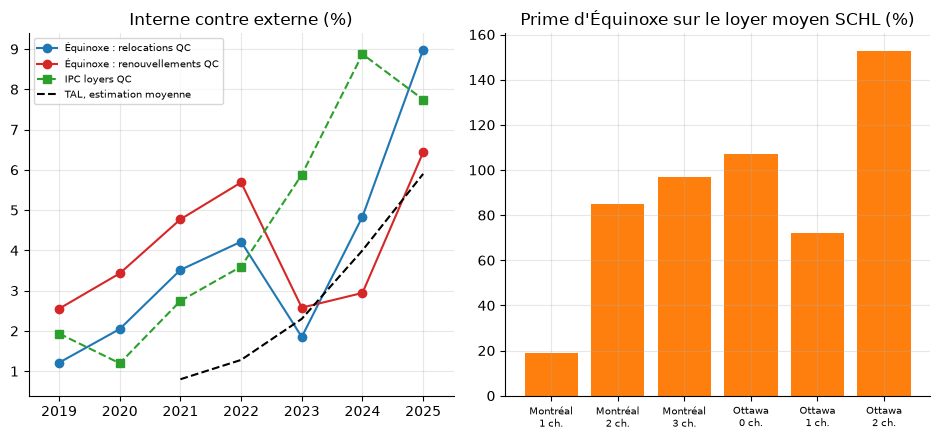

In [62]:
fig, axes = plt.subplots(1, 2, figsize=STYLE.figsize_wide)
shown_years = range(CONFIG.first_year, CONFIG.last_observed_year + 1)
axes[0].plot(shown_years, internal_series.loc[shown_years, "QC relocations (contractuel)"], "o-", color=PALETTE["contract"], label="Équinoxe : relocations QC")
axes[0].plot(shown_years, internal_series.loc[shown_years, "QC renouvellements (contractuel)"], "o-", color=PALETTE["effective"], label="Équinoxe : renouvellements QC")
axes[0].plot(shown_years, driver_series.loc[shown_years, "IPC loyers QC (moyenne annuelle)"], "s--", color=PALETTE["market"], label="IPC loyers QC")
axes[0].plot(TAL_OLD.index, TAL_OLD, "k--", label="TAL, estimation moyenne")
axes[0].set(title="Interne contre externe (%)", xlim=(CONFIG.first_year - STYLE.x_margin_years, CONFIG.last_observed_year + STYLE.x_margin_years))
axes[0].legend(fontsize=STYLE.small_fontsize)
axes[1].bar(level_table.index, level_table["prime (%)"], color=PALETTE["rule"])
axes[1].set_xticks(level_table.index)
axes[1].set_xticklabels([f"{row['marché'].split(' ')[0]}\n{int(row['chambres'])} ch." for _, row in level_table.iterrows()], fontsize=STYLE.small_fontsize)
axes[1].set(title="Prime d'Équinoxe sur le loyer moyen SCHL (%)")
plt.tight_layout()
plt.show()

In [63]:
assert external.groupby("series").published_on.min().notna().all(), "toute série a une date de publication"
assert (external.confidence.isin(["high", "medium", "low"])).all()
assert cpi_monthly.month.max() >= year_start(CONFIG.forecast_year), "l'IPC doit couvrir l'année prévue pour l'aperçu"
assert cpi_monthly.published_on.max() <= pd.Timestamp(CONFIG.data_as_of), "aucune donnée publiée après la date de retrait"
print("Contrôles de la section 8 : OK")

Contrôles de la section 8 : OK


## 9. Contre-vérification : deux autres estimateurs de la même quantité

La médiane des paires (section 4) est simple, mais elle n'utilise que les paires consécutives et un écart d'un an pour presque toutes. Deux estimateurs classiques, **indépendants** de la médiane, mesurent aussi la croissance « à même unité » : si les trois s'accordent, la mesure est solide ; sinon nous le disons.

### 9a. Indice de loyers répétés (méthode de Bailey-Muth-Nourse et de Case-Shiller)
Pour chaque paire, `log(loyer_t2) − log(loyer_t1) = Σ_τ β_τ · D_τ + ε`, où `D_τ = +1` l'année du second bail, `−1` l'année du premier, `0` sinon. L'indice annuel est `exp(β_t − β_{t−1}) − 1` : **une seule estimation utilise toutes les paires**, y compris celles qui enjambent deux années (baux de 18 et 24 mois), que la médiane annuelle traite mal. Pondération de Case-Shiller : les écarts longs sont plus bruités, on pondère par l'inverse de la variance prédite en fonction de l'écart.

**Cette étape ajoute une colonne** à `pairs` : `prev_lease_year`, l'année du bail précédent. Les années de l'indice vont du premier bail de l'extrait à la dernière année observée.

In [64]:
def repeat_rent_index(pair_frame, rent_column_pair, years):
    """Estime les effets d'année β (base = première année) par MCO puis MCP de Case-Shiller. Retourne la croissance annuelle (%)."""
    first, last = years[0], years[-1]
    frame = pair_frame[pair_frame.prev_lease_year.between(first, last) & pair_frame.lease_year.between(first, last)]
    y = np.log(frame[rent_column_pair[0]].to_numpy() / frame[rent_column_pair[1]].to_numpy())
    design = np.zeros((len(frame), len(years) - 1))
    for position, year in enumerate(years[1:]):
        design[:, position] += (frame.lease_year.to_numpy() == year)
        design[:, position] -= (frame.prev_lease_year.to_numpy() == year)
    beta_ols = np.linalg.lstsq(design, y, rcond=None)[0]
    squared = (y - design @ beta_ols) ** 2
    gaps = frame.gap_years.to_numpy()
    variance_fit = np.polyfit(gaps, squared, 1)
    predicted_variance = np.clip(np.polyval(variance_fit, gaps), squared.min() + CONFIG.variance_floor, None)
    sqrt_w = np.sqrt(1 / predicted_variance)[:, None]
    beta = np.linalg.lstsq(design * sqrt_w, y * sqrt_w[:, 0], rcond=None)[0]
    level = np.concatenate([[0.0], beta])
    return pd.Series(np.expm1(np.diff(level)) * 100, index=years[1:])


pairs["prev_lease_year"] = pairs.prev_lease_start.dt.year
index_years = list(range(int(leases.lease_year.min()), CONFIG.last_observed_year + 1))
repeat_contract = repeat_rent_index(pairs, ("rent_contract", "prev_rent_contract"), index_years)
repeat_effective = repeat_rent_index(pairs, ("rent_effective", "prev_rent_effective"), index_years)


def repeat_index_bootstrap(rent_pair, n_draws, rng):
    """Bootstrap par unité : on rééchantillonne les unités (les paires d'une même unité sont corrélées)."""
    unique_labels, inverse = np.unique(pairs.unit_label.to_numpy(), return_inverse=True)
    by_unit = [np.flatnonzero(inverse == k) for k in range(len(unique_labels))]
    draws = []
    for _ in range(n_draws):
        chosen = rng.integers(0, len(unique_labels), len(unique_labels))
        sample = pairs.iloc[np.concatenate([by_unit[k] for k in chosen])]
        draws.append(repeat_rent_index(sample, rent_pair, index_years))
    return pd.DataFrame(draws)


repeat_draws = repeat_index_bootstrap(("rent_effective", "prev_rent_effective"), CONFIG.n_repeat_bootstrap, np.random.default_rng(CONFIG.random_seed))
repeat_table = pd.DataFrame({
    "indice loyers répétés, contractuel": repeat_contract, "médiane des paires, contractuel": same_unit[("contractuel", "median")],
    "indice loyers répétés, effectif": repeat_effective, "médiane des paires, effectif": same_unit[("effectif", "median")],
    f"effectif, borne basse ({CONFIG.ci_low:.0f} %)": repeat_draws.quantile(CONFIG.ci_low / 100),
    f"effectif, borne haute ({CONFIG.ci_high:.0f} %)": repeat_draws.quantile(CONFIG.ci_high / 100),
}).loc[CONFIG.first_year:CONFIG.last_observed_year]
repeat_table.round(CONFIG.table_digits)

,"indice loyers répétés, contractuel","médiane des paires, contractuel","indice loyers répétés, effectif","médiane des paires, effectif","effectif, borne basse (10 %)","effectif, borne haute (90 %)"
2019,1.95,2.14,1.48,1.63,1.14,1.84
2020,3.01,3.17,2.60,3.02,2.33,2.88
2021,4.34,4.46,3.55,3.54,3.27,3.84
2022,5.13,5.40,4.28,4.59,3.91,4.58
2023,1.89,2.29,1.78,2.02,1.42,2.11
2024,3.65,3.39,1.59,1.77,1.32,1.90
2025,7.65,7.04,3.70,3.58,3.39,3.98


In [65]:
repeat_gap = (repeat_table["indice loyers répétés, effectif"] - repeat_table["médiane des paires, effectif"]).abs()
repeat_width = repeat_table.iloc[:, -1] - repeat_table.iloc[:, -2]
narrate(f"**Lecture.** L'indice de loyers répétés suit la médiane des paires de près (écart absolu de {fmt(repeat_gap.min(), CONFIG.table_digits)} à "
        f"{fmt(repeat_gap.max(), CONFIG.table_digits)} point selon l'année, même creux, même accélération) ; les écarts viennent de ce qu'il utilise des moyennes "
        "logarithmiques (sensibles aux valeurs extrêmes) et les paires à écart long. Les bandes bootstrap par unité ont une largeur de "
        f"{fmt(repeat_width.min(), CONFIG.table_digits)} à {fmt(repeat_width.max(), CONFIG.table_digits)} point : la **mesure historique est précise ; c'est la prévision qui est incertaine**.")

**Lecture.** L'indice de loyers répétés suit la médiane des paires de près (écart absolu de 0,01 à 0,42 point selon l'année, même creux, même accélération) ; les écarts viennent de ce qu'il utilise des moyennes logarithmiques (sensibles aux valeurs extrêmes) et les paires à écart long. Les bandes bootstrap par unité ont une largeur de 0,55 à 0,70 point : la **mesure historique est précise ; c'est la prévision qui est incertaine**.

### 9b. Modèle à effets fixes d'unité (régression hédonique « within »)
`log(loyer_i,t) = α_unité + γ_année + δ_renouvellement + ε` : chaque unité est comparée à elle-même sur **tous** ses baux (pas seulement les paires consécutives), l'effet fixe d'unité absorbe tout ce qui est fixe dans un appartement (vue, plan, étage). Les effets d'année `γ` forment un indice de qualité constante ; la différence `γ_t − γ_{t−1}` est la croissance.

In [66]:
fixed_effects_sample = leases[leases.lease_year.between(index_years[0], CONFIG.last_observed_year)].copy()


def within_year_effects(frame, rent_column):
    """Régression within : année + renouvellement, après suppression de la moyenne par unité (effet fixe d'unité)."""
    data = frame.copy()
    data["log_rent"] = np.log(data[rent_column])
    year_dummies = pd.get_dummies(data.lease_year, prefix="y", drop_first=True).astype(float)
    design = pd.concat([year_dummies, data[["is_renewal"]].astype(float)], axis=1)
    design["unit_label"] = (data.prop_code + "|" + data.unit_code).to_numpy()
    demeaned = design.drop(columns="unit_label") - design.groupby("unit_label").transform("mean")
    demeaned_y = data.log_rent - data.log_rent.groupby(design.unit_label).transform("mean")
    fit = sm.OLS(demeaned_y, demeaned).fit()
    effects = pd.concat([pd.Series({f"y_{index_years[0]}": 0.0}), fit.params.drop("is_renewal")])
    return pd.Series(np.expm1(np.diff(effects.to_numpy())) * 100, index=index_years[1:]), fit.params["is_renewal"]


within_effective, renewal_premium_effective = within_year_effects(fixed_effects_sample, "rent_effective")
triangulation = pd.DataFrame({
    "médiane des paires": same_unit[("effectif", "median")], "loyers répétés": repeat_effective, "effets fixes d'unité": within_effective,
}).loc[CONFIG.first_year:CONFIG.last_observed_year]
triangulation["écart max entre méthodes (points)"] = triangulation.max(axis=1) - triangulation.min(axis=1)
print(f"Effet moyen « renouvellement » à unité et année données : {np.expm1(renewal_premium_effective) * 100:+.2f} % (loyer effectif)")
triangulation.round(CONFIG.table_digits)

Effet moyen « renouvellement » à unité et année données : -0.70 % (loyer effectif)


,médiane des paires,loyers répétés,effets fixes d'unité,écart max entre méthodes (points)
2019,1.63,1.48,1.66,0.19
2020,3.02,2.60,2.89,0.42
2021,3.54,3.55,3.87,0.33
2022,4.59,4.28,4.45,0.31
2023,2.02,1.78,2.18,0.40
2024,1.77,1.59,1.87,0.28
2025,3.58,3.70,3.81,0.23


In [67]:
narrate(f"**Lecture.** Trois méthodes indépendantes (médiane de paires, loyers répétés, effets fixes d'unité) donnent des croissances effectives proches année après année : "
        f"l'écart maximal entre elles va de {fmt(triangulation.iloc[:, -1].min(), CONFIG.table_digits)} à {fmt(triangulation.iloc[:, -1].max(), CONFIG.table_digits)} point. "
        "La croissance historique à unité constante est bien mesurée. L'incertitude ne vient donc pas de la mesure, mais de la **dynamique** (changements de régime), "
        "ce qui explique pourquoi la prévision de la section 10 reste incertaine malgré une mesure précise.")

**Lecture.** Trois méthodes indépendantes (médiane de paires, loyers répétés, effets fixes d'unité) donnent des croissances effectives proches année après année : l'écart maximal entre elles va de 0,19 à 0,42 point. La croissance historique à unité constante est bien mesurée. L'incertitude ne vient donc pas de la mesure, mais de la **dynamique** (changements de régime), ce qui explique pourquoi la prévision de la section 10 reste incertaine malgré une mesure précise.

In [68]:
assert (triangulation["écart max entre méthodes (points)"] < CONFIG.max_method_disagreement_points).all(), "les trois méthodes doivent s'accorder"
assert abs(repeat_table.loc[CONFIG.last_observed_year, "indice loyers répétés, contractuel"] - same_unit.loc[CONFIG.last_observed_year, ("contractuel", "median")]) < CONFIG.max_method_disagreement_points
print("Contrôles de la section 9 : OK")

Contrôles de la section 9 : OK


## 10. Prévoir la hausse 2026 et la valider par backtest

### 10a. Principe : un modèle structurel par composantes, sans fuite d'information
La section 8 a montré qu'aucune série publique ne prévoit bien la hausse *globale* ; en revanche chaque **composante** a un moteur distinct. Le modèle retenu prévoit chacune avec une règle **sans paramètre ajusté** ou tirée du droit :

| Composante | Moteur | Règle du modèle structurel |
|---|---|---|
| **Renouvellements** (contractuel) | politique de la société, encadrée par le TAL | politique commune ancrée sur le TAL ; calendrier des avis du Québec utilisé comme proxy de politique, y compris pour The Met exempté (section 10d) |
| **Relocations** (contractuel) | marché | variation de l'IPC loyers du Québec de l'année précédente (section 8b, 10c) |
| **Concessions** (niveau du drag des nouveaux baux) | politique de prix | variation de l'IPC loyers du Québec de l'année précédente (section 10c), avec deux trajectoires alternatives quand l'IPC baisse (section 10d) |

**Distribution plutôt que moyenne.** Les centres alimentent une **simulation Monte-Carlo de la cohorte réelle** : les unités dont le bail échoit dans l'année `t` et qui sont connues à la date de coupure, leur loyer et leur concession actuels, leur probabilité de renouveler (par province, sur les dernières années). Chaque unité tire son type, sa dispersion autour du centre (résidus de l'an dernier) et sa nouvelle concession **dans la distribution de sa propre propriété** (The Met et les immeubles en location initiale concèdent plus) ; la médiane des paires simulées est la prévision. C'est la **même définition** que la cible, ce qui évite de confondre « médiane d'un mélange » et « mélange de médianes ».

**Comparateur générique.** Pour mesurer ce qu'apporte la structure, le backtest évalue aussi une **combinaison de règles candidates pondérée par l'inverse de leur erreur passée** (reconduction, moyenne, TAL + écart, IPC + écart, affichages, tendances des concessions…), où les poids ne voient que les années antérieures à l'année prédite. C'est ce qu'obtiendrait une méthode qui ne connaît pas la structure.

**Trois millésimes d'information**, rapportés séparément (dates dans `ForecastConfig.vintage_dates`) :
* `december` : tout ce qui est public au 31 décembre de `t−1` (le TAL de l'année `t` n'est pas encore connu : il est prévu par sa formule, section 10c) ;
* `january` : ajoute le TAL de l'année `t` (publié vers le 20 janvier) ;
* `october` : ajoute l'IPC des premiers mois de l'année `t`. **C'est le millésime de la prévision en direct** (données publiques à la date de retrait) ; il se rejoue de la même façon dans le passé.

Dans tous les millésimes, les **baux** sont coupés au 31 décembre de `t−1` : seule l'information publique change d'un millésime à l'autre (choix prudent).

In [69]:
# CONFIG (prévision)
@dataclass(frozen=True)
class ForecastConfig:
    vintage_dates: dict = field(default_factory=lambda: {"december": (-1, "12-31"), "january": (0, "01-31"), "october": (0, CONFIG.data_as_of[5:])})  # (décalage d'année, mois-jour) ; october = date de retrait
    live_vintage: str = "october"    # prévision en direct : information publique à la date de retrait
    cpi_min_months: int = 3          # pas de moyenne IPC avec moins de trois mois publiés
    n_simulations_backtest: int = 1000
    renewal_share_window_years: int = 2     # probabilité de renouveler : moyenne des deux dernières années (part stable, section 6c)
    min_cell_multiplier: int = 2            # une province exige deux fois la taille minimale de cellule par année de fenêtre
    penetration_k_window_years: int = 2     # sensibilité k de la pénétration des concessions : moyenne des deux dernières années connues (section 10c ; testé en 10f bis)
    drag_pools: str = "property"            # forme des concessions : distribution de la propriété de l'unité ("property") ou du portefeuille ("portfolio") ; testé en 10f bis
    notice_timing: str = "uniform"          # date de l'avis dans la fenêtre légale : "uniform" (retenu), "earliest" ou "latest" (bornes, testées en 10f bis)
    robustness_variants: dict = field(default_factory=lambda: {
        "k : dernière année seulement": {"penetration_k_window_years": 1}, "k : trois dernières années": {"penetration_k_window_years": 3},
        "k : tout l'historique": {"penetration_k_window_years": None},
        "part de renouvellement : dernière année": {"renewal_share_window_years": 1}, "part de renouvellement : trois ans": {"renewal_share_window_years": 3},
        "concessions : distribution du portefeuille": {"drag_pools": "portfolio"},
        "avis : au plus tôt de la fenêtre légale": {"notice_timing": "earliest"}, "avis : au plus tard de la fenêtre légale": {"notice_timing": "latest"}})
    mc_precision_seeds: int = 5             # graines indépendantes pour mesurer la précision Monte-Carlo du headline (section 11c)
    # --- TAL : faits juridiques (sources en section 13) ---
    tal_new_format_first_year: int = 2026   # nouvelle méthode (pourcentage de base) pour les avis donnés à compter du 1er janvier 2026 (décret 1455-2025)
    tal_new_method_window_years: int = 3    # décret 1455-2025, art. `3.1` : pourcentage de base = moyenne des trois variations annuelles de la moyenne sur 12 mois de l'IPC d'ensemble du Québec
    notice_months_long_lease: tuple = (3, 6)   # art. 1942 C.c.Q. : avis de modification 3 à 6 mois avant la fin d'un bail de 12 mois ou plus
    notice_months_short_lease: tuple = (1, 2)  # ... et 1 à 2 mois avant la fin d'un bail de moins de 12 mois
    max_tal_rebuild_error: float = 0.1      # écart maximal toléré entre la formule du TAL reconstruite et le taux publié (points)
    min_indexation_correlation: float = 0.9 # corrélation minimale exigée entre le drag annuel et l'IPC loyers de l'année précédente
    # --- comparateur générique (combinaison de règles) ---
    shrink_k: float = 2.0            # l'écart moyen « interne − règle » est rétréci vers 0 : somme / (n + k), comme k années fictives à écart nul
    min_scored_years: int = 2        # une règle n'a un poids propre qu'après deux années d'erreurs observées
    error_decay: float = 0.5         # une année plus ancienne pèse moitié moins dans l'erreur moyenne d'une règle
    damping: float = 0.5             # part du dernier changement conservée par la règle « tendance amortie »


FORECAST = ForecastConfig()
EXTERNAL_TABLES = {"annual": external, "cpi": cpi_monthly}


@contextmanager
def forecast_settings(**changes):
    """Remplace temporairement des réglages de ForecastConfig (tests de robustesse), puis rétablit les réglages retenus."""
    global FORECAST
    retained = FORECAST
    FORECAST = replace(retained, **changes)
    try:
        yield
    finally:
        FORECAST = retained


def vintage_cutoff(year, vintage):
    """Date jusqu'à laquelle une valeur publique est connue pour prévoir `year` selon le millésime."""
    year_offset, month_day = FORECAST.vintage_dates[vintage]
    return pd.Timestamp(f"{year + year_offset}-{month_day}")


def known_at(leases_table, asking_table, year):
    """Baux et affichages connus à la fin de year − 1 (coupure appliquée AVANT tout calcul)."""
    cutoff = year_end(year - 1)
    return leases_table[leases_table.lease_start <= cutoff], asking_table[asking_table.ask_date <= cutoff]


def cpi_driver(external_tables, year, cutoff):
    """Moyenne des variations annuelles de l'IPC loyers du Québec, mois de `year` publiés avant `cutoff`."""
    monthly = external_tables["cpi"]
    monthly = monthly[(monthly.geo == "Quebec") & (monthly.published_on <= cutoff) & (monthly.month.dt.year == year)].yoy_pct.dropna()
    return float(monthly.mean()) if len(monthly) >= FORECAST.cpi_min_months else np.nan


def published_series(external_tables, series, cutoff):
    rows = external_tables["annual"]
    return rows[(rows.series == series) & (rows.published_on <= cutoff)].drop_duplicates("year", keep="last").set_index("year").value.sort_index()


def tal_slope(external_tables, cutoff):
    """Pente de « estimation ancienne méthode ≈ pente × IPC loyers QC(t−1) », estimée par MCO passant par l'origine sur les seuls taux publiés à `cutoff`."""
    old = published_series(external_tables, "tal_recommended_unheated_old_method", cutoff)
    previous_cpi = pd.Series({year: cpi_driver(external_tables, year - 1, cutoff) for year in old.index}).dropna()
    common = old.index.intersection(previous_cpi.index)
    if len(common) < FORECAST.min_scored_years:
        return np.nan
    return float((old[common] * previous_cpi[common]).sum() / (previous_cpi[common] ** 2).sum())


def tal_old_method_rate(external_tables, year, cutoff):
    """Taux « ancienne méthode » de `year` : publié s'il l'est à `cutoff`, sinon prévu par sa formule (pente × IPC de year − 1), sinon le dernier publié."""
    old = published_series(external_tables, "tal_recommended_unheated_old_method", cutoff)
    if year in old.index:
        return float(old[year])
    formula = tal_slope(external_tables, cutoff) * cpi_driver(external_tables, year - 1, cutoff)
    if pd.notna(formula):
        return float(formula)
    return float(old.iloc[-1]) if len(old) else np.nan


def tal_base_percentage(external_tables, year, cutoff):
    """Pourcentage de base (nouvelle méthode) de `year` : publié s'il l'est à `cutoff`, sinon sa formule (moyenne de trois ans de l'IPC d'ensemble
    du Québec publiée à `cutoff`), sinon NaN."""
    new = published_series(external_tables, "tal_base_percentage_new_format", cutoff)
    if year in new.index:
        return float(new[year])
    all_items_known = published_series(external_tables, "cpi_all_items_avg_yoy", cutoff).loc[year - FORECAST.tal_new_method_window_years:year - 1]
    return max(float(all_items_known.mean()), 0.0) if len(all_items_known) == FORECAST.tal_new_method_window_years else np.nan     # un résultat négatif est ramené à zéro


def prepare_context(known_leases, known_asking):
    """Tout ce qui se calcule à partir des seules données connues à la date de coupure."""
    known_leases = known_leases.sort_values(UNIT_KEY + ["lease_start"]).reset_index(drop=True)
    known_pairs = build_pairs(known_leases)
    known_pairs = known_pairs[known_pairs.is_valid].copy()
    quebec_pairs = known_pairs[known_pairs.province == "Quebec"]
    annual_series = pd.DataFrame({
        "renew_qc": quebec_pairs[quebec_pairs.is_renewal == 1].groupby("lease_year").growth_contract_pct.median(),
        "reloc_qc": quebec_pairs[quebec_pairs.is_renewal == 0].groupby("lease_year").growth_contract_pct.median(),
        "all_contract": known_pairs.groupby("lease_year").growth_contract_pct.median(),
        "all_effective": known_pairs.groupby("lease_year").growth_effective_pct.median(),
        "drag": known_leases.groupby("lease_year").drag.mean() * 100,
        "penetration": known_leases.groupby("lease_year").has_concession.mean() * 100,
        "depth": known_leases[known_leases.drag > 0].groupby("lease_year").drag.mean() * 100,
        "ask": same_unit_asking_growth(known_asking).groupby("ask_year").growth_pct.median() if len(known_asking) else pd.Series(dtype=float)})
    return {"leases": known_leases, "pairs": known_pairs, "annual": annual_series}


def shrunk_mean(values):
    series = pd.Series(list(values), dtype=float).dropna()
    return float(series.sum() / (len(series) + FORECAST.shrink_k)) if len(series) else 0.0


def rule_forecasts(context, external_tables, component, year, vintage):
    """Prévision de `component` pour `year` par chaque règle candidate du comparateur, avec la seule information antérieure à `year`."""
    cutoff = vintage_cutoff(year, vintage)
    annual_series = context["annual"]
    history = annual_series[component].loc[:year - 1].dropna()
    rules = {"reconduire": history.iloc[-1] if len(history) else np.nan, "moyenne historique": history.mean() if len(history) else np.nan}
    if component == "renew_qc":
        spreads = [annual_series.loc[y, component] - tal_old_method_rate(external_tables, y, vintage_cutoff(y, vintage)) for y in history.index if y >= CONFIG.extended_backtest_years[0]]
        rules["TAL + écart"] = tal_old_method_rate(external_tables, year, cutoff) + shrunk_mean(spreads)
        rules["TAL seul"] = tal_old_method_rate(external_tables, year, cutoff)
    if component in ("renew_qc", "reloc_qc"):
        spreads = [annual_series.loc[y, component] - cpi_driver(external_tables, y - 1, vintage_cutoff(y, vintage)) for y in history.index]
        rules["IPC décalé + écart"] = cpi_driver(external_tables, year - 1, cutoff) + shrunk_mean(spreads)
    if component == "reloc_qc":
        gap_history = (annual_series.reloc_qc - annual_series.renew_qc).loc[:year - 1].dropna()
        renewal_years = [y for y in gap_history.index if y >= CONFIG.extended_backtest_years[0]]
        if len(gap_history):
            rules["TAL + écart relocation−renouvellement"] = tal_old_method_rate(external_tables, year, cutoff) + float(gap_history.iloc[-1]) + shrunk_mean(
                [annual_series.loc[y, "renew_qc"] - tal_old_method_rate(external_tables, y, vintage_cutoff(y, vintage)) for y in renewal_years])
        ask_history = annual_series["ask"].dropna()
        spreads = [annual_series.loc[y, component] - ask_history[y - 1] for y in history.index if (y - 1) in ask_history.index]
        rules["affichés décalés + écart"] = (ask_history.get(year - 1, np.nan) + shrunk_mean(spreads)) if (year - 1) in ask_history.index else np.nan
        if vintage == "october":
            spreads = [annual_series.loc[y, component] - cpi_driver(external_tables, y, vintage_cutoff(y, vintage)) for y in history.index]
            rules["IPC de l'année (nowcast) + écart"] = cpi_driver(external_tables, year, cutoff) + shrunk_mean(spreads)
    if component == "drag":
        deltas = history.diff().dropna()
        last_delta = deltas.iloc[-1] if len(deltas) else 0.0
        rules["tendance"] = history.iloc[-1] + last_delta
        rules["tendance moyenne"] = history.iloc[-1] + (deltas.tail(CONFIG.recent_years_for_mean).mean() if len(deltas) else 0.0)
        rules["tendance amortie"] = history.iloc[-1] + FORECAST.damping * last_delta
        penetration, depth = annual_series["penetration"].loc[:year - 1].dropna(), annual_series["depth"].loc[:year - 1].dropna()
        if len(penetration) > 1 and len(depth) > 1:
            penetration_forecast = min(100, penetration.iloc[-1] + penetration.diff().iloc[-1])     # la pénétration ne dépasse pas 100 %
            rules["pénétration × profondeur (tendances)"] = penetration_forecast * (depth.iloc[-1] + depth.diff().iloc[-1]) / 100
        rules.pop("moyenne historique")
    return rules


def decayed_mean_error(errors):
    weights = FORECAST.error_decay ** np.arange(len(errors))[::-1]
    return float(np.sum(weights * np.asarray(errors)) / weights.sum())


def ensemble_forecast(context, external_tables, component, year, vintage):
    """Combinaison des règles, pondérée par l'inverse de leur erreur passée (récente d'abord). Retourne (prévision, poids, prévisions)."""
    forecasts = {name: value for name, value in rule_forecasts(context, external_tables, component, year, vintage).items() if pd.notna(value)}
    past_errors = {}
    for past_year in context["annual"][component].loc[CONFIG.first_year + 1:year - 1].dropna().index:
        for name, value in rule_forecasts(context, external_tables, component, past_year, vintage).items():
            if name in forecasts and pd.notna(value):
                past_errors.setdefault(name, []).append(abs(value - context["annual"].loc[past_year, component]))
    scored = {name: decayed_mean_error(errors) for name, errors in past_errors.items() if len(errors) >= FORECAST.min_scored_years}
    if len(scored) >= 2:
        inverse = {name: 1 / max(error, np.finfo(float).eps) for name, error in scored.items()}
        weights = {name: value / sum(inverse.values()) for name, value in inverse.items()}
    else:
        weights = {name: 1 / len(forecasts) for name in forecasts}
    center = sum(weights[name] * forecasts[name] for name in weights)
    return center, weights, forecasts

### 10b. Cohorte et simulation
La **cohorte de l'année `t`** = les unités dont le dernier bail connu se termine de sorte que le suivant commence pendant `t` (le nouveau bail commence le lendemain de la fin de l'ancien). On connaît leur loyer contractuel, leur drag actuel et leur durée, donc la **base de comparaison** de chacune des paires est déjà fixée ; seul le nouveau bail reste à prévoir.

**Concessions des nouveaux baux : deux marges.** Le niveau moyen du drag `D` est une entrée (section 10c). Sa *forme* compte autant que son niveau pour une médiane : en 2025 la pénétration saute, et une simple mise à l'échelle de la distribution de l'an dernier garderait trop de baux sans concession. On sépare donc :
* la **marge extensive** (qui reçoit une concession) : `pénétration = 1 − exp(−k × D)`, la relation de la section 10c, avec `k` **estimé à la date de coupure** sur les `penetration_k_window_years` dernières années connues ;
* la **marge intensive** (combien) : la profondeur moyenne vaut `D / pénétration` ; chaque unité tire son rabais dans la distribution des rabais positifs de l'an dernier **de sa propre propriété** (si elle compte au moins `min_cell_size` baux, sinon celle du portefeuille), mise à l'échelle de cette profondeur, jamais au-delà du plus grand rabais observé (support empirique, pas un plafond choisi).

In [70]:
def build_cohort(context, year):
    latest = context["leases"].sort_values("lease_start").groupby(UNIT_KEY).tail(1)
    starts_next = latest.lease_end + pd.Timedelta(days=1)          # le nouveau bail commence le lendemain de la fin de l'ancien
    return latest[starts_next.dt.year == year].assign(next_start=starts_next).reset_index(drop=True)


def renewal_probability(context, year, cohort):
    recent = context["pairs"][context["pairs"].lease_year.between(year - FORECAST.renewal_share_window_years, year - 1)]
    if recent.empty:
        raise ValueError("Aucune paire récente pour estimer la probabilité de renouvellement")
    pooled = recent.is_renewal.mean()
    by_province = recent.groupby("province").is_renewal.agg(["mean", "size"])
    reliable = by_province["size"] >= CONFIG.min_cell_size * FORECAST.renewal_share_window_years * FORECAST.min_cell_multiplier
    return cohort.province.map(lambda province: by_province.loc[province, "mean"] if province in by_province.index and reliable[province] else pooled).to_numpy()


def penetration_sensitivity(context, year):
    """k de « pénétration = 1 − exp(−k × drag) », moyenne des dernières années connues avant `year` (estimé à la date de coupure)."""
    annual_series = context["annual"].loc[:year - 1].dropna(subset=["penetration", "drag"])
    annual_series = annual_series[(annual_series.drag > 0) & annual_series.penetration.between(0, 100, inclusive="neither")]
    if annual_series.empty:
        raise ValueError("Aucune année valide pour estimer la pénétration des concessions")
    k_by_year = -np.log1p(-annual_series.penetration / 100) / annual_series.drag
    window = FORECAST.penetration_k_window_years
    return float((k_by_year.tail(window) if window else k_by_year).mean())


def new_lease_drags(context, cohort, year, drag_level, n_draws, rng):
    """Concession de chaque nouveau bail (fraction du loyer) : marge extensive (pénétration) puis marge intensive (profondeur, par propriété)."""
    if not np.isfinite(drag_level) or drag_level < 0:
        raise ValueError("Le drag doit être fini et positif ou nul")
    if drag_level == 0:
        return np.zeros((n_draws, len(cohort)))
    penetration = -np.expm1(-penetration_sensitivity(context, year) * drag_level)
    last_year = context["leases"][(context["leases"].lease_year == year - 1) & (context["leases"].drag > 0)]
    portfolio_pool = last_year.drag.to_numpy()
    if not len(portfolio_pool):
        raise ValueError("Aucune concession positive l’année précédente : profondeur non identifiable")
    pools = {code: group.drag.to_numpy() for code, group in last_year.groupby("prop_code") if len(group) >= CONFIG.min_cell_size} if FORECAST.drag_pools == "property" else {}
    depths = np.empty((n_draws, len(cohort)))
    for code, columns in cohort.groupby("prop_code").indices.items():
        depths[:, columns] = rng.choice(pools.get(code, portfolio_pool), (n_draws, len(columns)))
    depths *= (drag_level / 100 / penetration) / portfolio_pool.mean()
    has_concession = rng.random((n_draws, len(cohort))) < penetration
    return np.clip(np.where(has_concession, depths, 0.0), 0, context["leases"].drag.max())


def simulate_cohort(context, cohort, year, renewal_center, relocation_center, drag_level, n_draws, seed, ontario_regime="exempt", ontario_guideline=None):
    """Monte-Carlo de la cohorte : paires simulées (contractuel et effectif annualisés, en %). `renewal_center` peut être propre à chaque unité."""
    if ontario_regime not in ("exempt", "capped"):
        raise ValueError("Le régime Ontario doit être exempt ou capped")
    if ontario_regime == "capped" and (ontario_guideline is None or not np.isfinite(ontario_guideline)):
        raise ValueError("Le régime capped exige une ligne directrice Ontario finie")
    if cohort.empty or n_draws <= 0:
        raise ValueError("La simulation exige une cohorte non vide et des tirages positifs")
    if not np.isfinite(renewal_center).all() or not np.isfinite(relocation_center):
        raise ValueError("Les centres de croissance doivent être finis")
    if not cohort.drag.between(0, 1, inclusive="left").all():
        raise ValueError("Les concessions précédentes doivent être comprises entre zéro et un exclu")
    rng = np.random.default_rng(seed)
    last_pairs = context["pairs"][context["pairs"].lease_year == year - 1]
    residuals = {flag: (last_pairs[last_pairs.is_renewal == flag].growth_contract_pct
                        - last_pairs[last_pairs.is_renewal == flag].growth_contract_pct.median()).to_numpy() for flag in (0, 1)}
    if any(not len(pool) for pool in residuals.values()):
        raise ValueError("Renouvellements et relocations exigent chacun des paires l’année précédente")
    n_units = len(cohort)
    renew = rng.random((n_draws, n_units)) < renewal_probability(context, year, cohort)
    growth_renewal = np.asarray(renewal_center, dtype=float) + rng.choice(residuals[1], (n_draws, n_units))
    growth_relocation = relocation_center + rng.choice(residuals[0], (n_draws, n_units))
    contract = np.where(renew, growth_renewal, growth_relocation)
    if ontario_regime == "capped" and ontario_guideline is not None:
        in_ontario = (cohort.province == "Ontario").to_numpy()
        contract = np.where(in_ontario & renew, np.minimum(contract, ontario_guideline), contract)
    new_drag = new_lease_drags(context, cohort, year, drag_level, n_draws, rng)
    previous_drag = cohort.drag.to_numpy()[None, :]
    gap_years = ((cohort.next_start - cohort.lease_start).dt.days.to_numpy() / CONFIG.days_per_year)[None, :]
    if not np.isfinite(gap_years).all() or (gap_years <= 0).any():
        raise ValueError("L’écart entre débuts de bail doit être fini et strictement positif")
    effective = ((1 + contract / 100) * ((1 - new_drag) / (1 - previous_drag)) ** (1 / gap_years) - 1) * 100
    return {"cohort": cohort, "renew": renew, "contract": contract, "effective": effective, "weights": cohort.rent_contract.to_numpy()}


def summarise_simulation(simulation, segment_keys=()):
    """Statistiques par tirage : médianes (définition de la cible), moyennes pondérées par le loyer, effet moyen des concessions, segments."""
    contract, effective, renew, weights = simulation["contract"], simulation["effective"], simulation["renew"], simulation["weights"]
    summary = {"contract": np.median(contract, axis=1), "effective": np.median(effective, axis=1),
               "renewal_contract": np.nanmedian(np.where(renew, contract, np.nan), axis=1),
               "relocation_contract": np.nanmedian(np.where(~renew, contract, np.nan), axis=1),
               "contract_mean": contract @ weights / weights.sum(), "effective_mean": effective @ weights / weights.sum(),
               "concession_effect": (effective - contract).mean(axis=1), "segments": {}}
    for keys in segment_keys:
        for label, columns in simulation["cohort"].groupby(list(keys)).indices.items():
            label = label if isinstance(label, tuple) else (label,)
            summary["segments"][(keys, label)] = {"contract": np.median(contract[:, columns], axis=1), "effective": np.median(effective[:, columns], axis=1),
                                                  "units": len(columns)}
    return summary

**Pourquoi une distribution de concessions par propriété ?** Parce que les propriétés ne concèdent pas la même chose : le tableau suivant donne, pour la dernière année observée, la pénétration, la profondeur et le drag de chaque propriété. Le choix est ensuite testé contre la distribution du portefeuille (section 10f bis).

In [71]:
property_concessions = concession_profile_by(leases[leases.lease_year == CONFIG.last_observed_year], "prop_code")
display(property_concessions.round(CONFIG.table_digits))
narrate(f"**Lecture.** En {CONFIG.last_observed_year}, le drag va de {fmt(property_concessions.drag_pct.min())} % (`{property_concessions.drag_pct.idxmin()}`) à "
        f"{fmt(property_concessions.drag_pct.max())} % (`{property_concessions.drag_pct.idxmax()}`), et la profondeur de {fmt(property_concessions.depth_pct.min())} à "
        f"{fmt(property_concessions.depth_pct.max())} % : un écart de {fmt(property_concessions.drag_pct.max() - property_concessions.drag_pct.min())} points entre propriétés, "
        "du même ordre que la variation annuelle du drag. Une unité de la cohorte tire donc sa concession dans la distribution de sa propre propriété.")

,leases,penetration_pct,depth_pct,drag_pct
prop_code,,,,
carlyle,185,92.97,10.69,9.94
dj1,59,77.97,10.90,8.50
dj2,71,76.06,11.01,8.37
levesque,77,83.12,10.64,8.85
metcalfe,120,97.50,10.61,10.34
stelz1,36,80.56,10.44,8.41
stelz2,118,72.03,10.89,7.84
stelz3,134,76.12,10.68,8.13
wsp1,158,94.30,10.56,9.96


**Lecture.** En 2025, le drag va de 7,8 % (`stelz2`) à 10,3 % (`metcalfe`), et la profondeur de 10,4 à 11,0 % : un écart de 2,5 points entre propriétés, du même ordre que la variation annuelle du drag. Une unité de la cohorte tire donc sa concession dans la distribution de sa propre propriété.

### 10c. Une découverte : concessions, relocations et TAL suivent l'IPC loyers de l'année précédente
La comparaison des séries historiques révèle trois relations simples. **Elles ont été repérées en regardant 2018-2025, donc le backtest qui suit les favorise** ; nous le disons, et nous montrons leur stabilité plutôt que de les supposer.
1. **Concessions.** Le drag moyen des baux d'une année `t` suit la variation de l'IPC loyers du Québec de `t−1`, **sans paramètre** : l'entreprise semble réinitialiser son budget de concessions chaque janvier sur l'inflation des loyers de l'année écoulée, ce qui explique les marches annuelles de la section 5.
2. **Relocations.** La hausse contractuelle des relocations du Québec suit la même variation de l'IPC de `t−1` (section 8b).
3. **TAL.** L'ancienne méthode du TAL vaut une fraction stable de cet IPC (pente estimée ci-dessous, sur les seuls taux publiés) ; la nouvelle méthode (décret 1455-2025, art. `3.1`) est la moyenne des trois variations annuelles de la moyenne sur 12 mois de l'IPC d'ensemble du Québec, non désaisonnalisé (résultat négatif ramené à zéro) : la formule doit retrouver les pourcentages publiés, ce que vérifie la cellule.

In [72]:
previous_year_cpi = pd.Series({year: cpi_driver(EXTERNAL_TABLES, year - 1, vintage_cutoff(year, "january")) for year in range(CONFIG.first_year - 1, CONFIG.forecast_year + 1)})
indexation = pd.DataFrame({"drag moyen des baux de l'année (%)": profile_by_year.drag_pct, "IPC loyers QC, année précédente (%)": previous_year_cpi,
                           "relocations QC (contractuel, %)": internal_series["QC relocations (contractuel)"], "TAL ancienne méthode (%)": TAL_OLD}).loc[CONFIG.first_year - 1:CONFIG.last_observed_year]
display(indexation.round(CONFIG.table_digits))
drag_cpi_correlation = indexation.iloc[:, 0].corr(indexation.iloc[:, 1])
drag_cpi_recent_error = (indexation.iloc[:, 0] - indexation.iloc[:, 1]).abs().loc[CONFIG.backtest_years[0]:].mean()
relocation_cpi_rmse = float(np.sqrt(((indexation.iloc[:, 2] - indexation.iloc[:, 1]) ** 2).mean()))
relocation_cpi_bias = float((indexation.iloc[:, 2] - indexation.iloc[:, 1]).mean())
live_cutoff = vintage_cutoff(CONFIG.forecast_year, FORECAST.live_vintage)
tal_slope_live = tal_slope(EXTERNAL_TABLES, live_cutoff)
tal_vs_cpi = indexation[["TAL ancienne méthode (%)", "IPC loyers QC, année précédente (%)"]].dropna()
tal_leave_one_out = [abs(tal_vs_cpi.iloc[position, 0] - float((tal_vs_cpi.iloc[:, 0].drop(year) * tal_vs_cpi.iloc[:, 1].drop(year)).sum()
                                                               / (tal_vs_cpi.iloc[:, 1].drop(year) ** 2).sum()) * tal_vs_cpi.iloc[position, 1])
                     for position, year in enumerate(tal_vs_cpi.index)]
all_items = external_series("cpi_all_items_avg_yoy", "Quebec")
tal_new_rebuilt = pd.Series({year: max(all_items.loc[year - FORECAST.tal_new_method_window_years:year - 1].mean(), 0.0) for year in TAL_NEW_FORMAT.index})
penetration_constant = (-np.log(1 - profile_by_year.penetration_pct / 100) / profile_by_year.drag_pct).loc[CONFIG.first_year - 1:]
print(f"TAL (ancienne méthode) ≈ {tal_slope_live:.3f} × IPC loyers QC de l'année précédente ; erreurs « un an de côté » : {[round(e, CONFIG.table_digits) for e in tal_leave_one_out]}")
print("Nouvelle méthode du TAL reconstruite :", tal_new_rebuilt.round(CONFIG.table_digits).to_dict(), "| publiée :", TAL_NEW_FORMAT.to_dict())
print("Pénétration des concessions : k = −ln(1 − pénétration) / drag =", penetration_constant.round(CONFIG.fine_digits).to_dict())
assert (tal_new_rebuilt - TAL_NEW_FORMAT).abs().max() < FORECAST.max_tal_rebuild_error, "la formule doit retrouver les taux publiés"
assert drag_cpi_correlation > FORECAST.min_indexation_correlation, "le drag doit suivre l'IPC loyers de l'année précédente"

,drag moyen des baux de l'année (%),"IPC loyers QC, année précédente (%)","relocations QC (contractuel, %)",TAL ancienne méthode (%)
2018,1.36,0.73,NaN,NaN
2019,1.70,0.81,1.21,NaN
2020,2.09,1.93,2.05,NaN
2021,2.69,1.20,3.52,0.80
2022,3.33,2.76,4.22,1.28
2023,3.58,3.60,1.85,2.30
2024,5.71,5.87,4.84,4.00
2025,9.13,8.88,8.98,5.90


TAL (ancienne méthode) ≈ 0.655 × IPC loyers QC de l'année précédente ; erreurs « un an de côté » : [np.float64(0.01), np.float64(0.56), np.float64(0.06), np.float64(0.21), np.float64(0.2)]
Nouvelle méthode du TAL reconstruite : {2025: 4.5, 2026: 3.09} | publiée : {2025: 4.5, 2026: 3.1}
Pénétration des concessions : k = −ln(1 − pénétration) / drag = {2018: 0.357, 2019: 0.343, 2020: 0.321, 2021: 0.289, 2022: 0.256, 2023: 0.219, 2024: 0.23, 2025: 0.211}


In [73]:
narrate(f"**Lecture et prudence.** Le drag suit l'IPC loyers de l'année précédente avec une corrélation de **{fmt(drag_cpi_correlation, CONFIG.fine_digits)}** "
        f"et un écart absolu moyen de {fmt(drag_cpi_recent_error, CONFIG.table_digits)} point sur {CONFIG.backtest_years[0]}-{CONFIG.backtest_years[-1]}. "
        f"Les relocations s'en écartent de {fmt(relocation_cpi_rmse, CONFIG.table_digits)} point en écart quadratique moyen (biais moyen {fmt(relocation_cpi_bias, CONFIG.table_digits, signed=True)}) "
        f"sur {indexation.iloc[:, 2].notna().sum()} ans, sans paramètre ajusté. L'ancienne méthode du TAL vaut {fmt(tal_slope_live, CONFIG.fine_digits)} × cet IPC "
        f"(erreurs « un an de côté » de {fmt(min(tal_leave_one_out), CONFIG.table_digits)} à {fmt(max(tal_leave_one_out), CONFIG.table_digits)} point) et la nouvelle méthode "
        f"retrouve les pourcentages publiés à {fmt((tal_new_rebuilt - TAL_NEW_FORMAT).abs().max(), CONFIG.table_digits)} point près. "
        f"Enfin, la **pénétration** suit `1 − exp(−k × drag)` : `k` baisse de {fmt(penetration_constant.iloc[0], CONFIG.table_digits)} à "
        f"{fmt(penetration_constant.loc[CONFIG.backtest_years[0]], CONFIG.table_digits)} jusqu'en {CONFIG.backtest_years[0]}, puis se stabilise "
        f"({', '.join(fmt(penetration_constant[year], CONFIG.fine_digits) for year in CONFIG.backtest_years)}) ; le modèle l'estime donc sur les dernières années connues, à la date de coupure.\n\n"
        f"Huit points annuels ne prouvent pas une loi : ce sont des régularités **observées**, pas des règles écrites. Elles donnent deux lectures du TAL {CONFIG.forecast_year} : "
        f"le **pourcentage de base** de {fmt(TAL_NEW_FORMAT[CONFIG.forecast_year])} % (nouvelle méthode) et son **équivalent ancienne méthode** "
        f"({fmt(tal_slope_live * previous_year_cpi[CONFIG.forecast_year], CONFIG.table_digits)} %), à comparer à l'historique des renouvellements. La section suivante dit lequel s'applique à quelle unité.")

**Lecture et prudence.** Le drag suit l'IPC loyers de l'année précédente avec une corrélation de **0,985** et un écart absolu moyen de 0,15 point sur 2023-2025. Les relocations s'en écartent de 1,30 point en écart quadratique moyen (biais moyen +0,23) sur 7 ans, sans paramètre ajusté. L'ancienne méthode du TAL vaut 0,655 × cet IPC (erreurs « un an de côté » de 0,01 à 0,56 point) et la nouvelle méthode retrouve les pourcentages publiés à 0,01 point près. Enfin, la **pénétration** suit `1 − exp(−k × drag)` : `k` baisse de 0,36 à 0,22 jusqu'en 2023, puis se stabilise (0,219, 0,230, 0,211) ; le modèle l'estime donc sur les dernières années connues, à la date de coupure.

Huit points annuels ne prouvent pas une loi : ce sont des régularités **observées**, pas des règles écrites. Elles donnent deux lectures du TAL 2026 : le **pourcentage de base** de 3,1 % (nouvelle méthode) et son **équivalent ancienne méthode** (5,06 %), à comparer à l'historique des renouvellements. La section suivante dit lequel s'applique à quelle unité.

#### Précédents de baisse du moteur des concessions
On compare l’IPC disponible au drag précédent, puis au drag effectivement observé. Les trajectoires diffèrent dès que le premier est inférieur au second ; il ne faut pas confondre absence de précédent récent et absence de précédent historique.

In [74]:
concession_precedents = indexation.copy()
concession_precedents["drag précédent (%)"] = profile_by_year.drag_pct.shift(1)
concession_precedents = concession_precedents[concession_precedents.iloc[:, 1] < concession_precedents["drag précédent (%)"]]
display(concession_precedents.round(CONFIG.table_digits))
narrate(f"**Lecture.** {len(concession_precedents)} année(s) de l’historique ont un IPC inférieur au drag précédent : "
        f"{', '.join(map(str, concession_precedents.index))}. Leurs concessions réalisées figurent dans le tableau ; "
        "ce constat empêche de présenter la baisse du moteur comme un événement sans précédent.")

,drag moyen des baux de l'année (%),"IPC loyers QC, année précédente (%)","relocations QC (contractuel, %)",TAL ancienne méthode (%),drag précédent (%)
2018,1.36,0.73,NaN,NaN,1.18
2019,1.70,0.81,1.21,NaN,1.36
2021,2.69,1.20,3.52,0.80,2.09


**Lecture.** 3 année(s) de l’historique ont un IPC inférieur au drag précédent : 2018, 2019, 2021. Leurs concessions réalisées figurent dans le tableau ; ce constat empêche de présenter la baisse du moteur comme un événement sans précédent.

### 10d. 2026 : dater le changement de méthode du TAL, et ce que les données ne peuvent pas trancher
**Ancrage daté par l'avis (fait juridique).** La nouvelle méthode ne s'applique qu'aux avis de modification donnés **à compter du 1er janvier 2026** (décret 1455-2025, art. 6 et 8) ; les avis antérieurs restent soumis à l'ancienne méthode. L'avis est donné dans une **fenêtre légale** avant l'arrivée du terme du bail (art. 1942 C.c.Q. : 3 à 6 mois pour un bail de 12 mois ou plus, 1 à 2 mois sinon). Pour chaque unité de la cohorte, on calcule donc, **à partir de sa propre date de fin de bail et de sa durée**, la part de sa fenêtre d'avis située avant le 1er janvier 2026 (avis supposé uniforme dans la fenêtre : la seule hypothèse) ; cette part reçoit le taux de l'ancienne méthode de la fenêtre de validité du bail (2025 pour un bail débutant au plus tard le 1er avril), le reste reçoit le pourcentage de base. Avant 2026, il n'y a pas de changement de méthode : l'ancrage est le taux de la fenêtre de validité.

**The Met : hypothèse de politique, pas droit québécois.** Le calendrier des avis du Québec est aussi utilisé comme proxy de la politique commune de l’entreprise à Ottawa. Le droit québécois ne s’y applique pas. Sans dates d’avis de The Met, ce proxy reste une limite ; les deux bornes de calendrier sont testées en section 10f bis.

**Ce qui est publié et ce qui est prévu.** Pour la fenêtre 2026, le TAL n'a pas publié d'estimation moyenne selon l'ancienne méthode ; le taux « ancienne méthode » 2026 est donc **prévu** par la formule de la section 10c (pente × IPC loyers de l'année précédente). Les composantes 2026 de l'ancienne méthode que le TAL publie (tableau 2 de sa page des pourcentages, avis donnés avant le 1er janvier 2026) indiquent un taux un peu plus bas : ce proxy penche légèrement vers le haut, ce qui ne touche que la part des avis donnés avant la réforme et la lecture « ancienne méthode pour tous ».

**Deux choix de politique incertains**, insuffisamment identifiés par le backtest :
1. **La société suit-elle la loi au pied de la lettre ?** Lecture centrale : ancrage daté par l'avis. Lectures extrêmes : le pourcentage de base appliqué à tous les renouvellements de l'année, ou l'ancienne méthode appliquée à tous.
   Le pourcentage du TAL n'est pas un plafond : c'est ce que le Tribunal appliquerait si le locataire refusait la hausse et que le propriétaire demandait la fixation. La société peut donc proposer plus (son habitude, l'ancienne méthode) ou s'aligner sur le nouveau pourcentage pour tous ; depuis 2023 ses renouvellements suivent le TAL (section 6b), mais jamais lors d'un changement de méthode.
2. **Que font les concessions quand l'IPC loyers baisse ?** C'est la première fois depuis le début du régime d'indexation : le drag a-t-il un **cliquet** (il ne baisse jamais), s'arrête-t-il **à mi-chemin** entre l'indexation et le cliquet, ou suit-il l'IPC (**indexé**) ? Quand l’IPC dépasse le drag précédent, les trois lectures coïncident. Le début de l’historique contient toutefois un précédent où l’IPC est inférieur au drag précédent ; la cellule suivante le montre. Ce précédent isolé, hors du régime récent, ne suffit pas à identifier la politique future.

**Pondération : uniforme.** Les données ne permettent pas de départager solidement ces lectures ; nous leur donnons le même poids. Cette grille et sa pondération restent des choix de jugement, même uniformes. La section 11b publie la réponse sous les lectures « règles observées » (la loi, des concessions indexées) pour que l'on voie ce que pèse ce choix. Nous **n'ajoutons pas** de dimension pour les relocations ni pour la part de renouvellements : leur variabilité est déjà mesurée par l'erreur du backtest, qui s'ajoute à la fin (section 11c) ; l'ajouter deux fois élargirait la bande sans raison.

In [75]:
# CONFIG (mélange)
@dataclass(frozen=True)
class MixtureConfig:
    renewal_readings: tuple = ("pourcentage de base pour tous", "daté par l'avis (loi)", "ancienne méthode pour tous")
    concession_paths: tuple = ("indexées sur l'IPC", "à mi-chemin", "cliquet")
    draws_per_run: int = 400          # tirages Monte-Carlo par combinaison distincte (précision mesurée en 11c)


MIXTURE = MixtureConfig()
LAW_READING, INDEXED_PATH, RATCHET_PATH = MIXTURE.renewal_readings[1], MIXTURE.concession_paths[0], MIXTURE.concession_paths[-1]


def uniform_prior(names):
    """A priori d'entropie maximale : le même poids pour chaque lecture que les données ne départagent pas."""
    return {name: 1 / len(names) for name in names}


def notice_share_before(cohort, reform_date):
    """Part de la fenêtre légale d'avis de chaque unité située avant `reform_date` : avis uniforme dans la fenêtre (retenu), ou au plus tôt / au plus tard (bornes)."""
    long_lease = cohort.term_months.to_numpy() >= CONFIG.months_per_year
    earliest_months = np.where(long_lease, FORECAST.notice_months_long_lease[1], FORECAST.notice_months_short_lease[1])
    latest_months = np.where(long_lease, FORECAST.notice_months_long_lease[0], FORECAST.notice_months_short_lease[0])
    earliest = pd.Series([end - pd.DateOffset(months=int(months)) for end, months in zip(cohort.lease_end, earliest_months)])
    latest = pd.Series([end - pd.DateOffset(months=int(months)) for end, months in zip(cohort.lease_end, latest_months)])
    if FORECAST.notice_timing == "earliest":
        return (earliest < reform_date).to_numpy(dtype=float)
    if FORECAST.notice_timing == "latest":
        return (latest < reform_date).to_numpy(dtype=float)
    return np.clip(((reform_date - earliest).dt.days / (latest - earliest).dt.days).to_numpy(), 0, 1)



def renewal_readings(external_tables, context, cohort, year, cutoff):
    """Ancrage de renouvellement de chaque unité selon trois lectures (en %) ; elles coïncident avant l'année du changement de méthode."""
    window_year = (cohort.next_start.dt.year - starts_in_previous_tal_window(cohort.next_start)).to_numpy()
    fallback = float(context["annual"].renew_qc.dropna().iloc[-1])      # aucun taux connu (début d'historique) : on reconduit les renouvellements
    old_rate = {wy: tal_old_method_rate(external_tables, wy, cutoff) for wy in np.unique(window_year)}
    old_by_unit = np.nan_to_num(np.array([old_rate[wy] for wy in window_year]), nan=fallback)
    if year < FORECAST.tal_new_format_first_year:
        return {name: old_by_unit for name in MIXTURE.renewal_readings}, np.ones(len(cohort))
    new_rate = {wy: tal_base_percentage(external_tables, wy, cutoff) for wy in np.unique(window_year)}
    new_by_unit = np.array([new_rate[wy] if pd.notna(new_rate[wy]) else old_rate[wy] for wy in window_year])
    share_old = notice_share_before(cohort, year_start(FORECAST.tal_new_format_first_year))
    base_for_all = np.full(len(cohort), tal_base_percentage(external_tables, year, cutoff))
    readings = dict(zip(MIXTURE.renewal_readings, (base_for_all, share_old * old_by_unit + (1 - share_old) * new_by_unit, old_by_unit)))
    return readings, share_old


def concession_paths(lagged_cpi, last_drag):
    """Niveau du drag des nouveaux baux selon trois lectures ; identiques quand l'IPC est au-dessus du drag de l'an dernier."""
    ratchet = max(lagged_cpi, last_drag)
    return dict(zip(MIXTURE.concession_paths, (lagged_cpi, (lagged_cpi + ratchet) / 2, ratchet)))


MEDIAN_PERCENTILE = 100 / 2


def weighted_percentile(values, weights, percentile):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if values.ndim != 1 or values.shape != weights.shape or not values.size:
        raise ValueError("Valeurs et poids doivent être des vecteurs non vides de même longueur")
    if not np.isfinite(values).all() or not np.isfinite(weights).all() or (weights < 0).any():
        raise ValueError("Valeurs et poids doivent être finis ; poids positifs ou nuls")
    if not np.isfinite(percentile) or not 0 <= percentile <= 100 or weights.sum() <= 0:
        raise ValueError("Percentile hors intervalle ou masse totale nulle")
    positive = weights > 0
    values, weights = values[positive], weights[positive]
    order = np.argsort(values, kind="stable")
    cumulative = np.cumsum(weights[order])
    position = np.searchsorted(cumulative, percentile / 100 * cumulative[-1], side="left")
    return float(values[order[min(position, len(order) - 1)]])



def forecast_mixture(leases_table, asking_table, external_tables, year, vintage, n_draws=None, seed=CONFIG.random_seed, priors=None, segment_keys=()):
    """Modèle structurel : lectures de renouvellement × trajectoires de concessions (a priori uniforme par défaut) ; une simulation par combinaison distincte.
    Mêmes nombres aléatoires pour toutes les combinaisons : les écarts entre scénarios ne viennent que des entrées."""
    renewal_weights, concession_weights = priors or (uniform_prior(MIXTURE.renewal_readings), uniform_prior(MIXTURE.concession_paths))
    for selected, allowed in ((renewal_weights, MIXTURE.renewal_readings), (concession_weights, MIXTURE.concession_paths)):
        if not selected or set(selected) - set(allowed):
            raise ValueError("La grille contient une lecture inconnue ou aucune lecture")
        probabilities = np.asarray(list(selected.values()), dtype=float)
        if not np.isfinite(probabilities).all() or (probabilities < 0).any() or not np.isclose(probabilities.sum(), 1):
            raise ValueError("Les a priori doivent être finis, non négatifs et sommer à un")
    if n_draws is not None and (not isinstance(n_draws, int) or isinstance(n_draws, bool) or n_draws <= 0):
        raise ValueError("Le nombre de tirages doit être un entier strictement positif")
    context = prepare_context(*known_at(leases_table, asking_table, year))
    cohort = build_cohort(context, year)
    cutoff = vintage_cutoff(year, vintage)
    readings, share_old = renewal_readings(external_tables, context, cohort, year, cutoff)
    lagged_cpi = cpi_driver(external_tables, year - 1, cutoff)
    last_drag = float(context["annual"].drag.loc[year - 1])
    paths = concession_paths(lagged_cpi, last_drag)
    runs, rows = {}, []
    for (renewal_name, renewal_weight), (concession_name, concession_weight) in product(renewal_weights.items(), concession_weights.items()):
        key = (tuple(np.round(readings[renewal_name], CONFIG.fine_digits)), round(paths[concession_name], CONFIG.fine_digits))
        if key not in runs:
            simulation = simulate_cohort(context, cohort, year, readings[renewal_name], lagged_cpi, paths[concession_name], n_draws or MIXTURE.draws_per_run, seed)
            runs[key] = summarise_simulation(simulation, segment_keys)
        rows.append({"renouvellements": renewal_name, "concessions": concession_name, "poids": renewal_weight * concession_weight, "run": key})
    frame = pd.DataFrame(rows)
    pooled = {statistic: np.concatenate([runs[row.run][statistic] for row in frame.itertuples()])
              for statistic in ("contract", "effective", "renewal_contract", "relocation_contract", "contract_mean", "effective_mean", "concession_effect")}
    weights = np.concatenate([np.full(len(runs[row.run]["contract"]), row.poids / len(runs[row.run]["contract"])) for row in frame.itertuples()])
    quebec = (cohort.province == "Quebec").to_numpy()
    centers = {"renew_qc": float(sum(weight * readings[name][quebec].mean() for name, weight in renewal_weights.items()) / sum(renewal_weights.values())),
               "reloc_qc": lagged_cpi, "drag": float(sum(weight * paths[name] for name, weight in concession_weights.items()) / sum(concession_weights.values()))}
    return {"frame": frame, "runs": runs, "pooled": pooled, "weights": weights, "readings": readings, "share_old": share_old, "paths": paths,
            "lagged_cpi": lagged_cpi, "last_drag": last_drag, "context": context, "cohort": cohort, "n_units": len(cohort), "centers": centers,
            "effective_p50": weighted_percentile(pooled["effective"], weights, MEDIAN_PERCENTILE),
            "contract_p50": weighted_percentile(pooled["contract"], weights, MEDIAN_PERCENTILE)}

### 10e. `estimate_2026()` et `backtest()`
`estimate_2026` retourne la hausse 2026 de la **définition principale** (loyer effectif, médiane des paires) en pourcentage, comme le gabarit le demande : la médiane du modèle structurel. `backtest` rejoue **exactement la même fonction** (`forecast_mixture`) comme à la fin de `target_year − 1` : les baux et les loyers affichés sont tronqués à cette date *avant* tout calcul, l'information publique est filtrée par sa date de publication, puis le résultat est comparé à ce qui s'est réellement passé. `forecast_detail` produit le comparateur générique (combinaison de règles).

In [76]:
def estimate_2026(leases, asking, external=None):
    """Hausse 2026 (en %) : croissance à unité constante du loyer EFFECTIF, médiane des paires, renouvellements + relocations (modèle structurel)."""
    tables = external if external is not None else EXTERNAL_TABLES
    return forecast_mixture(leases, asking, tables, CONFIG.forecast_year, FORECAST.live_vintage)["effective_p50"]


def forecast_detail(leases_table, asking_table, external_tables, year, vintage, n_draws, seed=CONFIG.random_seed):
    """Comparateur générique : centres = combinaison des règles pondérée par l'erreur, puis même simulation de cohorte."""
    context = prepare_context(*known_at(leases_table, asking_table, year))
    components = {}
    for component in ("renew_qc", "reloc_qc", "drag"):
        center, weights, rules = ensemble_forecast(context, external_tables, component, year, vintage)
        components[component] = {"center": center, "weights": weights, "rules": rules}
    centers = {name: values["center"] for name, values in components.items()}
    cohort = build_cohort(context, year)
    summary = summarise_simulation(simulate_cohort(context, cohort, year, centers["renew_qc"], centers["reloc_qc"], centers["drag"], n_draws, seed))
    return {"components": components, "centers": centers, "contract_median": float(np.median(summary["contract"])),
            "effective_median": float(np.median(summary["effective"])), "n_units": len(cohort)}


def realised_growth(leases_table, year):
    """Valeur réalisée de la cible pour `year`, par exactement les mêmes définitions que la prévision."""
    valid = build_pairs(leases_table.sort_values(UNIT_KEY + ["lease_start"]).reset_index(drop=True))
    valid = valid[valid.is_valid & (valid.lease_year == year)]
    quebec = valid[valid.province == "Quebec"]
    return {"contract": valid.growth_contract_pct.median(), "effective": valid.growth_effective_pct.median(),
            "renew_qc": quebec[quebec.is_renewal == 1].growth_contract_pct.median(), "reloc_qc": quebec[quebec.is_renewal == 0].growth_contract_pct.median(),
            "drag": leases_table[leases_table.lease_year == year].drag.mean() * 100, "pairs": len(valid)}


def backtest(leases, target_year, asking_table=None, external=None, vintage="january", model="structural"):
    """Exécute la méthode comme à la fin de target_year − 1 et compare avec ce qui s'est passé en target_year."""
    if model not in ("structural", "ensemble"):
        raise ValueError("Le modèle doit être structural ou ensemble")
    tables = external if external is not None else EXTERNAL_TABLES
    asking_used = asking_table if asking_table is not None else asking
    if model == "structural":
        result = forecast_mixture(leases, asking_used, tables, target_year, vintage, n_draws=FORECAST.n_simulations_backtest)
        predicted = {"contract": result["contract_p50"], "effective": result["effective_p50"]}
    else:
        result = forecast_detail(leases, asking_used, tables, target_year, vintage, FORECAST.n_simulations_backtest)
        predicted = {"contract": result["contract_median"], "effective": result["effective_median"]}
    actual = realised_growth(leases, target_year)
    return {"year": target_year, "vintage": vintage, "model": model, "predicted_effective": predicted["effective"], "actual_effective": actual["effective"],
            "error_effective": predicted["effective"] - actual["effective"], "predicted_contract": predicted["contract"],
            "actual_contract": actual["contract"], "error_contract": predicted["contract"] - actual["contract"],
            "centers": result["centers"], "actual_components": {k: actual[k] for k in ("renew_qc", "reloc_qc", "drag")}}

### 10f. Le backtest : 2023, 2024 et 2025 (et 2021-2022 pour plus de points)
Pour chaque année cible et chaque millésime : la prévision, la valeur réalisée, l'erreur. **Références toujours affichées** : *reconduire l'an dernier*, *moyenne des dernières années*, *dérive* (dernière valeur + variation moyenne récente) et *réglementaire seulement* (TAL pour les renouvellements, dernière relocation pour les relocations, mélange à la part de renouvellement récente).

**Statut statistique, dit honnêtement.** Les règles du modèle structurel n'ont **aucun paramètre ajusté sur l'année prédite** (la pente du TAL et la sensibilité `k` de la pénétration sont estimées à chaque date de coupure, sur le seul passé), mais elles ont été **choisies** en regardant 2018-2025 : pour le choix de la structure, le backtest est donc **dans l'échantillon**. Le comparateur générique, lui, est réellement hors échantillon.

In [77]:
MODEL_LABELS = {"structural": "modèle structurel (retenu)", "ensemble": "combinaison de règles"}
backtest_table = pd.DataFrame([backtest(leases, target_year, vintage=vintage, model=model)
                               for model in MODEL_LABELS for vintage in FORECAST.vintage_dates for target_year in CONFIG.extended_backtest_years])


def baseline_forecasts(year):
    """Références simples calculées à partir des seules années antérieures à `year`."""
    known = prepare_context(*known_at(leases, asking, year))
    annual_series = known["annual"]
    out = {}
    for kind, column in (("contract", "all_contract"), ("effective", "all_effective")):
        history = annual_series[column].loc[:year - 1].dropna()
        out[f"reconduire ({kind})"] = history.iloc[-1]
        out[f"moyenne récente ({kind})"] = history.tail(CONFIG.recent_years_for_mean).mean()
        out[f"dérive ({kind})"] = history.iloc[-1] + history.diff().dropna().tail(CONFIG.recent_years_for_mean).mean()
    regulatory = tal_old_method_rate(EXTERNAL_TABLES, year, vintage_cutoff(year, "january"))
    renewal_share_last = known["pairs"][known["pairs"].lease_year == year - 1].is_renewal.mean()
    out["réglementaire seul (contract)"] = renewal_share_last * regulatory + (1 - renewal_share_last) * annual_series.reloc_qc.loc[:year - 1].iloc[-1]
    return out


baseline_rows = []
for target_year in CONFIG.extended_backtest_years:
    truth = realised_growth(leases, target_year)
    for name, value in baseline_forecasts(target_year).items():
        kind = "effective" if "(effective)" in name else "contract"
        baseline_rows.append({"year": target_year, "method": name.split(" (")[0], "kind": kind, "predicted": value, "actual": truth[kind], "error": value - truth[kind]})
baseline_table = pd.DataFrame(baseline_rows)

model_summary = backtest_table.melt(id_vars=["year", "vintage", "model"], value_vars=["error_contract", "error_effective"], var_name="kind", value_name="error")
model_summary["kind"] = model_summary.kind.str.replace("error_", "")
model_summary["method"] = model_summary.model.map(MODEL_LABELS) + " (" + model_summary.vintage + ")"
all_errors = pd.concat([model_summary[["year", "method", "kind", "error"]], baseline_table[["year", "method", "kind", "error"]]])


def error_summary(frame, years):
    selected = frame[frame.year.isin(years)]
    return selected.groupby(["kind", "method"]).error.agg(MAE=lambda e: e.abs().mean(), biais="mean", pire_erreur=lambda e: e.abs().max())


required_summary = error_summary(all_errors, CONFIG.backtest_years)
extended_summary = error_summary(all_errors, CONFIG.extended_backtest_years)
print(f"=== Années exigées par le défi : {CONFIG.backtest_years} ===")
display(required_summary.round(CONFIG.table_digits))
print(f"=== Backtest étendu {CONFIG.extended_backtest_years[0]}-{CONFIG.extended_backtest_years[-1]} ({len(CONFIG.extended_backtest_years)} points) ===")
display(extended_summary.round(CONFIG.table_digits))

=== Années exigées par le défi : (2023, 2024, 2025) ===


MAE  biais  pire_erreur
kind      method                                                        
contract  combinaison de règles (december)      1.60   0.48         2.58
          combinaison de règles (january)       1.60   0.46         2.33
          combinaison de règles (october)       1.70   0.56         2.39
          dérive                                3.20  -0.40         4.19
          modèle structurel (retenu) (december) 0.40  -0.23         0.75
          modèle structurel (retenu) (january)  0.58   0.15         0.84
          modèle structurel (retenu) (october)  0.58   0.15         0.84
          moyenne récente                       2.02  -0.21         3.35
          reconduire                            2.62  -0.55         3.66
          réglementaire seul                    0.86  -0.39         1.56
effective combinaison de règles (december)      1.54   1.54         2.19
          combinaison de règles (january)       1.53   1.53         2.14
          combinaison de règles (october)       1.65   1.65         2.40
          dérive                                2.01   0.36         3.55
          modèle structurel (retenu) (december) 0.08   0.08         0.18
          modèle structurel (retenu) (january)  0.30   0.30         0.34
          modèle structurel (retenu) (october)  0.30   0.30         0.34
          moyenne récente                       1.36   0.84         1.70
          reconduire                            1.54   0.34         2.57

=== Backtest étendu 2021-2025 (5 points) ===


MAE  biais  pire_erreur
kind      method                                                        
contract  combinaison de règles (december)      1.61  -0.36         2.58
          combinaison de règles (january)       1.77  -0.53         2.55
          combinaison de règles (october)       1.82  -0.46         2.53
          dérive                                2.16  -0.48         4.19
          modèle structurel (retenu) (december) 1.35  -1.25         4.05
          modèle structurel (retenu) (january)  1.80  -1.37         3.80
          modèle structurel (retenu) (october)  1.80  -1.37         3.80
          moyenne récente                       2.01  -0.93         3.35
          reconduire                            2.02  -0.77         3.66
          réglementaire seul                    1.80  -1.52         3.27
effective combinaison de règles (december)      1.40   0.44         2.19
          combinaison de règles (january)       1.54   0.29         2.14
          combinaison de règles (october)       1.59   0.39         2.40
          dérive                                1.31   0.11         3.55
          modèle structurel (retenu) (december) 0.76  -0.66         3.17
          modèle structurel (retenu) (january)  1.22  -0.85         2.89
          modèle structurel (retenu) (october)  1.22  -0.85         2.89
          moyenne récente                       1.46  -0.13         1.86
          reconduire                            1.24  -0.11         2.57

,predicted_contract,actual_contract,error_contract,predicted_effective,actual_effective,error_effective
year,,,,,,
2021,0.97,4.46,-3.49,1.25,3.54,-2.30
2022,1.60,5.40,-3.80,1.70,4.59,-2.89
2023,2.54,2.29,0.25,2.29,2.02,0.27
2024,4.23,3.39,0.84,2.11,1.77,0.34
2025,6.40,7.04,-0.65,3.88,3.58,0.31


renouvellements QC         relocations QC         drag (%)        
                  prévu réalisé          prévu réalisé    prévu réalisé
2021               0.80    4.77           1.20    3.52     1.64    2.69
2022               1.20    5.69           2.76    4.22     2.76    3.33
2023               2.12    2.58           3.60    1.85     3.60    3.58
2024               3.65    2.94           5.87    4.84     5.87    5.71
2025               5.58    6.43           8.88    8.98     8.88    9.13

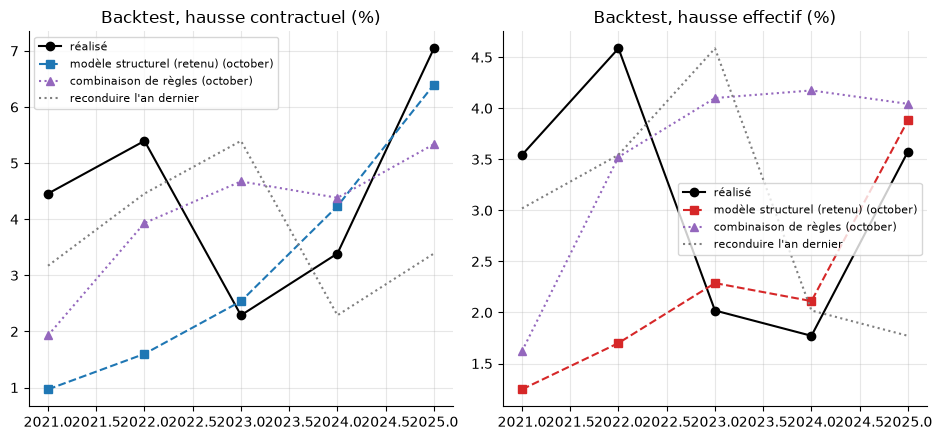

In [78]:
live_rows = backtest_table[(backtest_table.vintage == FORECAST.live_vintage) & (backtest_table.model == "structural")].set_index("year")
detail_columns = ["predicted_contract", "actual_contract", "error_contract", "predicted_effective", "actual_effective", "error_effective"]
display(live_rows[detail_columns].round(CONFIG.table_digits))
component_table = pd.DataFrame({(component, side): {year: (row.centers[key] if side == "prévu" else row.actual_components[key]) for year, row in live_rows.iterrows()}
                                for component, key in (("renouvellements QC", "renew_qc"), ("relocations QC", "reloc_qc"), ("drag (%)", "drag"))
                                for side in ("prévu", "réalisé")})
display(component_table.round(CONFIG.table_digits))

fig, axes = plt.subplots(1, 2, figsize=STYLE.figsize_wide)
ensemble_rows = backtest_table[(backtest_table.vintage == FORECAST.live_vintage) & (backtest_table.model == "ensemble")].set_index("year")
for ax, kind, title in zip(axes, ("contract", "effective"), ("contractuel", "effectif")):
    ax.plot(live_rows.index, live_rows[f"actual_{kind}"], "ko-", label="réalisé")
    ax.plot(live_rows.index, live_rows[f"predicted_{kind}"], "s--", color=PALETTE[kind], label=f"{MODEL_LABELS['structural']} ({FORECAST.live_vintage})")
    ax.plot(ensemble_rows.index, ensemble_rows[f"predicted_{kind}"], "^:", color=PALETTE["alternative"], label=f"{MODEL_LABELS['ensemble']} ({FORECAST.live_vintage})")
    persist = baseline_table[(baseline_table.method == "reconduire") & (baseline_table.kind == kind)].set_index("year").predicted
    ax.plot(persist.index, persist, ":", color=PALETTE["naive"], label="reconduire l'an dernier")
    ax.set(title=f"Backtest, hausse {title} (%)")
    ax.legend(fontsize=STYLE.legend_fontsize)
plt.tight_layout()
plt.show()

In [79]:
def mae_of(method, kind, years):
    return float(all_errors[(all_errors.method == method) & (all_errors.kind == kind) & all_errors.year.isin(years)].error.abs().mean())


structural_live = f"{MODEL_LABELS['structural']} ({FORECAST.live_vintage})"
structural_december = f"{MODEL_LABELS['structural']} (december)"
ensemble_live_label = f"{MODEL_LABELS['ensemble']} ({FORECAST.live_vintage})"
naive_methods = ["reconduire", "moyenne récente", "dérive"]
naive_mae = {kind: [mae_of(method, kind, CONFIG.backtest_years) for method in naive_methods] for kind in ("contract", "effective")}
early_years = [year for year in CONFIG.extended_backtest_years if year not in CONFIG.backtest_years]
narrate(f"**Lecture du backtest** (chiffres exacts dans les tableaux ci-dessus).\n"
        f"* **Le modèle structurel** se trompe en moyenne de **{fmt(mae_of(structural_live, 'contract', CONFIG.backtest_years), CONFIG.table_digits)} point (contractuel) et "
        f"{fmt(mae_of(structural_live, 'effective', CONFIG.backtest_years), CONFIG.table_digits)} point (effectif)** sur {CONFIG.backtest_years[0]}-{CONFIG.backtest_years[-1]}, "
        f"contre {fmt(min(naive_mae['effective']), CONFIG.table_digits)} à {fmt(max(naive_mae['effective']), CONFIG.table_digits)} point pour les références naïves (effectif) et "
        f"{fmt(mae_of(ensemble_live_label, 'effective', CONFIG.backtest_years), CONFIG.table_digits)} pour la combinaison de règles.\n"
        f"* **Hors du régime récent** ({', '.join(map(str, early_years))}), son erreur monte à {fmt(mae_of(structural_live, 'contract', early_years), CONFIG.table_digits)} point (contractuel) : "
        "les renouvellements dépassaient alors le TAL (section 6b) et le régime d'indexation des concessions n'existait pas encore. Le modèle est **bon dans le régime actuel, pas universel** : "
        "la section 11c chiffre ce risque de régime à part.\n"
        f"* **Le millésime décembre** prévoit le TAL de l'année cible **avant sa publication** par sa formule (section 10c) ; son erreur effective "
        f"({fmt(mae_of(structural_december, 'effective', CONFIG.backtest_years), CONFIG.table_digits)}) se compare à celle du millésime en direct.\n"
        "* **Prudence :** la structure a été choisie en regardant ces années (backtest dans l'échantillon pour le choix du modèle). Ce qui la rend crédible : aucun paramètre "
        "ajusté pour le niveau du drag et les relocations, deux paramètres seulement estimés à chaque date de coupure sur le passé (la pente du TAL avant sa publication, la "
        "sensibilité `k` de la pénétration), un mécanisme plausible (budget de concessions réinitialisé chaque janvier sur l'inflation des loyers) et, pour le TAL, une formule "
        "publique vérifiable. La combinaison de règles, réellement hors échantillon, montre ce qu'on obtient sans cette structure.")

**Lecture du backtest** (chiffres exacts dans les tableaux ci-dessus).
* **Le modèle structurel** se trompe en moyenne de **0,58 point (contractuel) et 0,30 point (effectif)** sur 2023-2025, contre 1,36 à 2,01 point pour les références naïves (effectif) et 1,65 pour la combinaison de règles.
* **Hors du régime récent** (2021, 2022), son erreur monte à 3,64 point (contractuel) : les renouvellements dépassaient alors le TAL (section 6b) et le régime d'indexation des concessions n'existait pas encore. Le modèle est **bon dans le régime actuel, pas universel** : la section 11c chiffre ce risque de régime à part.
* **Le millésime décembre** prévoit le TAL de l'année cible **avant sa publication** par sa formule (section 10c) ; son erreur effective (0,08) se compare à celle du millésime en direct.
* **Prudence :** la structure a été choisie en regardant ces années (backtest dans l'échantillon pour le choix du modèle). Ce qui la rend crédible : aucun paramètre ajusté pour le niveau du drag et les relocations, deux paramètres seulement estimés à chaque date de coupure sur le passé (la pente du TAL avant sa publication, la sensibilité `k` de la pénétration), un mécanisme plausible (budget de concessions réinitialisé chaque janvier sur l'inflation des loyers) et, pour le TAL, une formule publique vérifiable. La combinaison de règles, réellement hors échantillon, montre ce qu'on obtient sans cette structure.

In [80]:
backtest_headline = pd.DataFrame({
    f"MAE {CONFIG.backtest_years[0]}-{CONFIG.backtest_years[-1]}": required_summary.MAE,
    f"MAE {CONFIG.extended_backtest_years[0]}-{CONFIG.extended_backtest_years[-1]}": extended_summary.MAE}).unstack("kind")
print("Synthèse du backtest (erreur absolue moyenne, en points) :")
backtest_headline.round(CONFIG.table_digits)

Synthèse du backtest (erreur absolue moyenne, en points) :


MAE 2023-2025           MAE 2021-2025          
kind                                       contract effective      contract effective
method                                                                               
combinaison de règles (december)               1.60      1.54          1.61      1.40
combinaison de règles (january)                1.60      1.53          1.77      1.54
combinaison de règles (october)                1.70      1.65          1.82      1.59
dérive                                         3.20      2.01          2.16      1.31
modèle structurel (retenu) (december)          0.40      0.08          1.35      0.76
modèle structurel (retenu) (january)           0.58      0.30          1.80      1.22
modèle structurel (retenu) (october)           0.58      0.30          1.80      1.22
moyenne récente                                2.02      1.36          2.01      1.46
reconduire                                     2.62      1.54          2.02      1.24
réglementaire seul                             0.86       NaN          1.80       NaN

### 10f bis. Robustesse : chaque réglage déclaré, testé
Chaque réglage qui n'est pas estimé (fenêtre de `k`, fenêtre de la part de renouvellement, distribution des concessions, date de l'avis dans la fenêtre légale) est remplacé par ses alternatives raisonnables (`ForecastConfig.robustness_variants`). Pour chacune : la réponse 2026 et l'erreur du backtest 2023-2025 (millésime en direct). **Ce tableau ne sert pas à choisir le meilleur réglage** (ce serait régler le modèle sur les années testées) : il montre que la réponse n'en dépend pas, ou dit de combien elle en dépend.

In [81]:
def robustness_row(changes):
    """Réponse 2026 et erreur du backtest 2023-2025 sous des réglages modifiés (rétablis ensuite)."""
    with forecast_settings(**changes):
        forecast = forecast_mixture(leases, asking, EXTERNAL_TABLES, CONFIG.forecast_year, FORECAST.live_vintage)
        replays = [backtest(leases, year, vintage=FORECAST.live_vintage) for year in CONFIG.backtest_years]
    return {f"effectif {CONFIG.forecast_year} (médiane)": forecast["effective_p50"], f"contractuel {CONFIG.forecast_year} (médiane)": forecast["contract_p50"],
            "MAE effectif 2023-2025": np.mean([abs(replay["error_effective"]) for replay in replays]),
            "MAE contractuel 2023-2025": np.mean([abs(replay["error_contract"]) for replay in replays])}


robustness = pd.DataFrame({"réglages retenus": robustness_row({}),
                           **{label: robustness_row(changes) for label, changes in FORECAST.robustness_variants.items()}}).T
robustness["écart effectif (points)"] = robustness.iloc[:, 0] - robustness.iloc[0, 0]
robustness["écart contractuel (points)"] = robustness.iloc[:, 1] - robustness.iloc[0, 1]
robustness.round(CONFIG.table_digits)

,effectif 2026 (médiane),contractuel 2026 (médiane),MAE effectif 2023-2025,MAE contractuel 2023-2025,écart effectif (points),écart contractuel (points)
réglages retenus,6.01,4.72,0.30,0.58,0.00,0.00
k : dernière année seulement,5.92,4.72,0.30,0.58,-0.09,0.00
k : trois dernières années,6.01,4.72,0.31,0.58,-0.01,0.00
k : tout l'historique,6.52,4.72,0.38,0.58,0.50,0.00
part de renouvellement : dernière année,6.01,4.71,0.30,0.59,-0.01,-0.02
part de renouvellement : trois ans,6.04,4.76,0.30,0.59,0.03,0.04
concessions : distribution du portefeuille,6.02,4.72,0.30,0.58,0.01,0.00
avis : au plus tôt de la fenêtre légale,6.12,5.27,0.30,0.58,0.11,0.54
avis : au plus tard de la fenêtre légale,5.98,4.53,0.30,0.58,-0.03,-0.19


In [82]:
def material_settings(shift_column, error_column):
    """Réglages qui déplacent la réponse de plus que l'erreur du backtest du modèle retenu (le seuil vient du modèle lui-même)."""
    threshold = robustness.loc["réglages retenus", error_column]
    return robustness[robustness[shift_column].abs() > threshold], threshold


def describe_material(rows, shift_column, error_column, threshold, label):
    if rows.empty:
        return f"* **{label} :** aucun réglage ne déplace la réponse de plus que l'erreur du backtest ({fmt(threshold, CONFIG.table_digits)} point)."
    details = " ; ".join(f"« {name} » {fmt(row[shift_column], CONFIG.table_digits, signed=True)} point (erreur du backtest {fmt(row[error_column], CONFIG.table_digits)})"
                         for name, row in rows.iterrows())
    return f"* **{label} :** au-delà de l'erreur du backtest ({fmt(threshold, CONFIG.table_digits)} point) : {details}."


material_effective, threshold_effective = material_settings("écart effectif (points)", "MAE effectif 2023-2025")
material_contract, threshold_contract = material_settings("écart contractuel (points)", "MAE contractuel 2023-2025")
narrate(f"**Lecture.** Un réglage compte s'il déplace la réponse de plus que l'erreur du backtest du modèle retenu. Sur {len(robustness) - 1} réglages alternatifs, "
        f"la réponse effective {CONFIG.forecast_year} reste entre {fmt(robustness.iloc[:, 0].min(), CONFIG.table_digits)} et {fmt(robustness.iloc[:, 0].max(), CONFIG.table_digits)} % "
        f"(retenu : {fmt(robustness.iloc[0, 0], CONFIG.table_digits)} %), la contractuelle entre {fmt(robustness.iloc[:, 1].min(), CONFIG.table_digits)} et "
        f"{fmt(robustness.iloc[:, 1].max(), CONFIG.table_digits)} %.\n"
        + describe_material(material_effective, "écart effectif (points)", "MAE effectif 2023-2025", threshold_effective, "Effectif") + "\n"
        + describe_material(material_contract, "écart contractuel (points)", "MAE contractuel 2023-2025", threshold_contract, "Contractuel") + "\n\n"
        "Pourquoi garder les réglages retenus : `k` est estimé sur les années récentes parce qu'il dérive dans le temps (section 10c) ; l'estimer sur tout l'historique "
        "mélange l'ancien régime et dégrade le backtest. L'avis « uniforme » est le milieu de la fenêtre légale ; les deux bornes (au plus tôt, au plus tard) encadrent "
        "la réponse, et la date de l'avis ne change que 2026 (aucun changement de méthode avant), d'où un backtest identique.")

**Lecture.** Un réglage compte s'il déplace la réponse de plus que l'erreur du backtest du modèle retenu. Sur 8 réglages alternatifs, la réponse effective 2026 reste entre 5,92 et 6,52 % (retenu : 6,01 %), la contractuelle entre 4,53 et 5,27 %.
* **Effectif :** au-delà de l'erreur du backtest (0,30 point) : « k : tout l'historique » +0,50 point (erreur du backtest 0,38).
* **Contractuel :** aucun réglage ne déplace la réponse de plus que l'erreur du backtest (0,58 point).

Pourquoi garder les réglages retenus : `k` est estimé sur les années récentes parce qu'il dérive dans le temps (section 10c) ; l'estimer sur tout l'historique mélange l'ancien régime et dégrade le backtest. L'avis « uniforme » est le milieu de la fenêtre légale ; les deux bornes (au plus tôt, au plus tard) encadrent la réponse, et la date de l'avis ne change que 2026 (aucun changement de méthode avant), d'où un backtest identique.

In [83]:
# Contrôles de validité : pas de fuite d'information -----------------------------------------------------------
first_backtest_year = CONFIG.backtest_years[0]
context_first = prepare_context(*known_at(leases, asking, first_backtest_year))
assert context_first["leases"].lease_start.max() <= year_end(first_backtest_year - 1), "aucun bail postérieur à la coupure"
assert context_first["annual"].index.max() <= first_backtest_year - 1, "aucune année cible dans l'historique"
assert vintage_cutoff(first_backtest_year, "december") < vintage_cutoff(first_backtest_year, "january") < vintage_cutoff(first_backtest_year, "october")
assert first_backtest_year not in published_series(EXTERNAL_TABLES, "tal_recommended_unheated_old_method", vintage_cutoff(first_backtest_year, "december")).index, "TAL inconnu en décembre"
assert first_backtest_year in published_series(EXTERNAL_TABLES, "tal_recommended_unheated_old_method", vintage_cutoff(first_backtest_year, "january")).index, "TAL connu en janvier"
assert set(backtest_table.year) == set(CONFIG.extended_backtest_years)
print("Contrôles de la section 10 : OK")

Contrôles de la section 10 : OK


### 10g. Les loyers affichés disent-ils quelque chose sur 2026 ? (et pourquoi les `listings` n'aident pas)
Intuition séduisante : « nous affichons, nous signons un peu sous l'affichage, donc les relocations de 2026 sont déjà visibles dans les affichages actuels ». Nous la testons au lieu de la croire. **Étape qui crée deux tables** (`signed`, `last_lease_ask`) : chaque relocation, puis chaque dernier bail, associé au dernier affichage de son unité au plus `ask_match_tolerance_days` jours avant la signature.

In [84]:
ask_tolerance = pd.Timedelta(days=CONFIG.ask_match_tolerance_days)
ask_columns = asking[UNIT_KEY + ["ask_date", "rent_ask"]].sort_values("ask_date")
signed = pd.merge_asof(
    leases[leases.is_renewal == 0].assign(sign_month=lambda d: d.sign_date.dt.to_period("M").dt.to_timestamp()).sort_values("sign_month"),
    ask_columns, left_on="sign_month", right_on="ask_date", by=UNIT_KEY, direction="backward", tolerance=ask_tolerance)
signed["signed_vs_ask_pct"] = (signed.rent_contract / signed.rent_ask - 1) * 100
discount_by_year = signed.groupby("lease_year").signed_vs_ask_pct.agg(relocations_matched="count", median_signed_vs_ask="median").loc[CONFIG.first_year:]
display(discount_by_year.round(CONFIG.table_digits))
last_lease_ask = (leases.sort_values("lease_start").groupby(UNIT_KEY).tail(1)
                  .assign(sign_month=lambda d: d.sign_date.dt.to_period("M").dt.to_timestamp()).sort_values("sign_month"))
last_lease_ask = pd.merge_asof(last_lease_ask, ask_columns, left_on="sign_month", right_on="ask_date", by=UNIT_KEY, direction="backward", tolerance=ask_tolerance)
listing_check = units.merge(last_lease_ask[UNIT_KEY + ["rent_contract", "rent_ask"]], on=UNIT_KEY).dropna(subset=["rent_ask"])
listing_vs_current_ask = (listing_check.rent_listed_2025 / listing_check.rent_ask - 1) * 100
listing_vs_current_lease = (listing_check.rent_listed_2025 / listing_check.rent_contract - 1) * 100
listing_level_correlation = np.corrcoef(listing_check.rent_listed_2025, listing_check.rent_ask)[0, 1]
print(f"Loyer du fichier `listings` contre l'affichage ayant produit le bail ACTUEL : médiane {listing_vs_current_ask.median():+.2f} %, corrélation des niveaux {listing_level_correlation:.3f}")
print(f"Loyer du fichier `listings` contre le loyer du bail actuel : médiane {listing_vs_current_lease.median():+.2f} %")

,relocations_matched,median_signed_vs_ask
lease_year,,
2019,172,-2.23
2020,123,-2.18
2021,98,-1.53
2022,126,-1.95
2023,346,-1.98
2024,340,-1.62
2025,352,-1.91


Loyer du fichier `listings` contre l'affichage ayant produit le bail ACTUEL : médiane +0.45 %, corrélation des niveaux 0.998
Loyer du fichier `listings` contre le loyer du bail actuel : médiane +2.52 %


In [85]:
usual_discount = -discount_by_year.median_signed_vs_ask.median()
narrate(f"**Lecture.**\n"
        f"* **L'escompte de négociation est stable** : les relocations se signent en médiane {fmt(usual_discount)} % sous l'affichage, chaque année entre "
        f"{fmt(discount_by_year.median_signed_vs_ask.min(), signed=True)} et {fmt(discount_by_year.median_signed_vs_ask.max(), signed=True)} %. La règle « signé ≈ affiché moins un petit escompte » est solide.\n"
        f"* **Mais le fichier `listings` n'apporte aucun signal de {CONFIG.forecast_year}.** Son `rent_listed_2025` coïncide avec l'affichage qui a produit le **bail actuel** "
        f"(écart médian {fmt(listing_vs_current_ask.median(), CONFIG.table_digits, signed=True)} %, corrélation des niveaux {fmt(listing_level_correlation, CONFIG.fine_digits)}) "
        f"et dépasse le loyer du bail de {fmt(listing_vs_current_lease.median(), signed=True)} % : c'est exactement l'escompte habituel, pas une hausse annoncée. "
        "Lire cet écart comme une hausse de 2026 serait **une erreur de lecture** : les dates de disponibilité (`available_date`) ne sont pas liées aux fins de bail, "
        "et ce fichier décrit le niveau de 2025, pas un prix 2026.\n"
        "* **Conséquence :** nous n'utilisons pas `listings` comme variable prédictive ; la **variation** des loyers affichés d'Équinoxe (série `ask`) reste une règle candidate "
        "du comparateur (section 10a) et l'escompte sert de preuve de cohérence.")

**Lecture.**
* **L'escompte de négociation est stable** : les relocations se signent en médiane 2,0 % sous l'affichage, chaque année entre −2,2 et −1,5 %. La règle « signé ≈ affiché moins un petit escompte » est solide.
* **Mais le fichier `listings` n'apporte aucun signal de 2026.** Son `rent_listed_2025` coïncide avec l'affichage qui a produit le **bail actuel** (écart médian +0,45 %, corrélation des niveaux 0,998) et dépasse le loyer du bail de +2,5 % : c'est exactement l'escompte habituel, pas une hausse annoncée. Lire cet écart comme une hausse de 2026 serait **une erreur de lecture** : les dates de disponibilité (`available_date`) ne sont pas liées aux fins de bail, et ce fichier décrit le niveau de 2025, pas un prix 2026.
* **Conséquence :** nous n'utilisons pas `listings` comme variable prédictive ; la **variation** des loyers affichés d'Équinoxe (série `ask`) reste une règle candidate du comparateur (section 10a) et l'escompte sert de preuve de cohérence.

### 10h. Défi de l'apprentissage automatique : XGBoost, gardé seulement s'il bat la méthode structurelle
L'énoncé permet un modèle de régression « s'il est justifié ». Le risque est connu : quelques milliers de paires, mais seulement **quelques années distinctes** de conditions de marché. Un modèle flexible peut apprendre le bruit propre à chaque année. Nous lui donnons donc toutes ses chances, avec des garde-fous :
* **variables connues au moment de fixer le loyer** : propriété, chambres, superficie, étage, renouvellement ou non, durée et concession du bail précédent, écart de loyer du bail précédent au niveau de son segment (*loss-to-lease*), et variables de marché (taux TAL connu, IPC décalé, affichages décalés, inoccupation décalée) ;
* **ni année ni date** (elles ne s'extrapolent pas à 2026) ;
* **contraintes de monotonie** : la hausse ne diminue pas quand le TAL, l'IPC décalé ou les affichages décalés augmentent ;
* **validation à origine glissante** : on entraîne sur les années `≤ t−1` et on prédit `t` ; hyperparamètres petits et **fixés avant** de regarder les résultats ;
* **gardé seulement s'il bat la méthode structurelle** sur le même backtest.

In [86]:
# CONFIG (apprentissage automatique) : hyperparamètres petits, fixés a priori
XGB_PARAMS = dict(max_depth=3, n_estimators=200, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, min_child_weight=20, reg_lambda=5.0,
                  random_state=CONFIG.random_seed, n_jobs=1, tree_method="hist")
ML_MIN_TRAINING_YEARS = 3          # au moins trois années d'entraînement avant la première année prédite
SHAP_SAMPLE_SIZE = 5000            # paires expliquées par SHAP (au plus)
SHAP_TOP_FEATURES = 3              # variables citées dans la lecture
FEATURE_COLUMNS = ["building_code", "beds", "sqft", "floor", "is_renewal", "prev_term_months", "prev_drag", "loss_to_lease", "tal_rate", "cpi_lag", "ask_lag", "vacancy_lag"]
MONOTONE = {"tal_rate": 1, "cpi_lag": 1, "ask_lag": 1}

In [87]:
ml_backtest_years = [year for year in CONFIG.extended_backtest_years if year - CONFIG.first_year >= ML_MIN_TRAINING_YEARS]
building_codes = {code: index for index, code in enumerate(sorted(leases.prop_code.unique()))}


def market_features(year, vintage=FORECAST.live_vintage):
    """Variables de marché de l'année `year`, telles que connues à la date de coupure du millésime (TAL sur l'échelle de l'ancienne méthode)."""
    cutoff = vintage_cutoff(year, vintage)
    asking_previous = same_unit_asking_growth(asking[asking.ask_date <= year_end(year - 1)]).groupby("ask_year").growth_pct.median()
    vacancy_known = external[(external.series == "cmhc_vacancy_rate") & (external.geo == "Montreal CMA") & (external.published_on <= cutoff)].set_index("year").value
    return {"tal_rate": tal_old_method_rate(EXTERNAL_TABLES, year, cutoff), "cpi_lag": cpi_driver(EXTERNAL_TABLES, year - 1, cutoff),
            "ask_lag": float(asking_previous.get(year - 1, np.nan)), "vacancy_lag": float(vacancy_known.get(year - 1, np.nan))}


def segment_median_rent(year):
    """Loyer contractuel médian des baux ayant débuté en `year`, par propriété × chambres."""
    return leases[leases.lease_year == year].groupby(["prop_code", "beds"]).rent_contract.median()


def feature_table(rows, year, previous_rent, previous_drag, previous_term, renewal_flag):
    """Variables d'apprentissage pour des baux de l'année `year` (aucune variable ex post)."""
    medians = segment_median_rent(year - 1)
    segment_level = np.array([medians.get(key, np.nan) for key in zip(rows.prop_code, rows.beds)])
    table = pd.DataFrame({
        "building_code": rows.prop_code.map(building_codes).to_numpy(), "beds": rows.beds.to_numpy(), "sqft": rows.sqft.to_numpy(),
        "floor": rows.floor.to_numpy(), "is_renewal": np.asarray(renewal_flag, dtype=float), "prev_term_months": np.asarray(previous_term, dtype=float),
        "prev_drag": np.asarray(previous_drag, dtype=float), "loss_to_lease": np.log(segment_level) - np.log(np.asarray(previous_rent, dtype=float))})
    for name, value in market_features(year).items():
        table[name] = value
    return table[FEATURE_COLUMNS]


def training_set(last_training_year):
    """Paires des années first_year..last_training_year avec leurs variables ex ante et la cible contractuelle."""
    frames, targets = [], []
    for year in range(CONFIG.first_year, last_training_year + 1):
        subset = pairs[pairs.lease_year == year]
        frames.append(feature_table(subset, year, subset.prev_rent_contract, subset.prev_drag, subset.prev_term_months, subset.is_renewal))
        targets.append(subset.growth_contract_pct.to_numpy())
    features = pd.concat(frames, ignore_index=True)
    complete = features.notna().all(axis=1).to_numpy()
    return features[complete], np.concatenate(targets)[complete]


def fit_model(last_training_year):
    features, target = training_set(last_training_year)
    model = xgboost_library.XGBRegressor(**XGB_PARAMS, monotone_constraints=tuple(MONOTONE.get(name, 0) for name in FEATURE_COLUMNS))
    model.fit(features, target)
    return model


def predict_median_for_cohort(model, context, year):
    """Prévision de la médiane des paires de la cohorte : chaque unité reçoit p × (prévision si renouvellement) + (1 − p) × (prévision si relocation)."""
    cohort = build_cohort(context, year)
    probability = renewal_probability(context, year, cohort)
    common = dict(rows=cohort, year=year, previous_rent=cohort.rent_contract, previous_drag=cohort.drag, previous_term=cohort.term_months)
    as_renewal = model.predict(feature_table(renewal_flag=np.ones(len(cohort)), **common))
    as_relocation = model.predict(feature_table(renewal_flag=np.zeros(len(cohort)), **common))
    return float(np.median(probability * as_renewal + (1 - probability) * as_relocation))


ml_rows = []
for target_year in ml_backtest_years:
    context_ml = prepare_context(*known_at(leases, asking, target_year))
    ml_rows.append({"year": target_year, "XGBoost": predict_median_for_cohort(fit_model(target_year - 1), context_ml, target_year),
                    "actual_contract": realised_growth(leases, target_year)["contract"]})
ml_backtest = pd.DataFrame(ml_rows).set_index("year")
for model_name, label in MODEL_LABELS.items():
    ml_backtest[label] = backtest_table[(backtest_table.vintage == FORECAST.live_vintage) & (backtest_table.model == model_name)].set_index("year").predicted_contract.reindex(ml_backtest.index)
ml_mae = {name: (ml_backtest[name] - ml_backtest.actual_contract).abs().mean() for name in ["XGBoost", *MODEL_LABELS.values()]}
display(ml_backtest.round(CONFIG.table_digits))
print(f"Erreur absolue moyenne (contractuel), {ml_backtest_years[0]}-{ml_backtest_years[-1]} :", {name: round(value, CONFIG.table_digits) for name, value in ml_mae.items()})

,XGBoost,actual_contract,modèle structurel (retenu),combinaison de règles
year,,,,
2022,4.24,5.40,1.60,3.93
2023,5.15,2.29,2.54,4.67
2024,2.17,3.39,4.23,4.38
2025,3.62,7.04,6.40,5.34


Erreur absolue moyenne (contractuel), 2022-2025 : {'XGBoost': np.float64(2.17), 'modèle structurel (retenu)': np.float64(1.38), 'combinaison de règles': np.float64(1.64)}


In [88]:
narrate(f"**Verdict.** Hors période, XGBoost se trompe en moyenne de {fmt(ml_mae['XGBoost'], CONFIG.table_digits)} point sur la hausse contractuelle, contre "
        f"{fmt(ml_mae[MODEL_LABELS['structural']], CONFIG.table_digits)} pour le modèle structurel et {fmt(ml_mae[MODEL_LABELS['ensemble']], CONFIG.table_digits)} pour la combinaison de règles "
        f"({ml_backtest_years[0]}-{ml_backtest_years[-1]}). Le modèle à gradient n'a pas assez d'années distinctes de marché pour apprendre les effets d'année : "
        "**nous ne le retenons pas comme prévision**, mais nous le conservons comme **défi indépendant** et nous livrons le modèle entraîné jusqu'à la dernière année observée "
        "(`outputs/model_2026.json`). L'explication SHAP ci-dessous dit ce qu'il a appris.")

**Verdict.** Hors période, XGBoost se trompe en moyenne de 2,17 point sur la hausse contractuelle, contre 1,38 pour le modèle structurel et 1,64 pour la combinaison de règles (2022-2025). Le modèle à gradient n'a pas assez d'années distinctes de marché pour apprendre les effets d'année : **nous ne le retenons pas comme prévision**, mais nous le conservons comme **défi indépendant** et nous livrons le modèle entraîné jusqu'à la dernière année observée (`outputs/model_2026.json`). L'explication SHAP ci-dessous dit ce qu'il a appris.

**Le modèle final et ce qu'il a appris.** On entraîne XGBoost sur toutes les années observées, on l'applique à la cohorte 2026 (pour mémoire) et on mesure l'importance de chaque variable (SHAP si la librairie est installée, sinon le gain de XGBoost).

In [89]:
final_model = fit_model(CONFIG.last_observed_year)
final_model.save_model(CONFIG.output_dir / "model_2026.json")
context_live = prepare_context(leases, asking)
market_live = market_features(CONFIG.forecast_year)
xgboost_2026 = predict_median_for_cohort(final_model, context_live, CONFIG.forecast_year)
print(f"XGBoost, hausse contractuelle {CONFIG.forecast_year} (médiane de la cohorte) : {xgboost_2026:.2f} %   | variables de marché : { {k: round(v, CONFIG.table_digits) for k, v in market_live.items()} }")
print(f"(Le modèle a été entraîné sur l'échelle de l'ancienne méthode du TAL : il reçoit l'équivalent ancienne méthode ({market_live['tal_rate']:.2f} %), "
      f"pas le pourcentage de base ({TAL_NEW_FORMAT[CONFIG.forecast_year]:.1f} %).)")
if shap is not None:
    training_features, _ = training_set(CONFIG.last_observed_year)
    shap_values = shap.TreeExplainer(final_model).shap_values(training_features.sample(min(len(training_features), SHAP_SAMPLE_SIZE), random_state=CONFIG.random_seed))
    shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLUMNS).sort_values(ascending=False)
    display(shap_importance.round(CONFIG.fine_digits).rename("importance SHAP moyenne (points de %)").to_frame().T)
else:
    shap_importance = pd.Series(final_model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
    print("SHAP indisponible : importance par gain de XGBoost à la place")

XGBoost, hausse contractuelle 2026 (médiane de la cohorte) : 5.11 %   | variables de marché : {'tal_rate': 5.06, 'cpi_lag': 7.72, 'ask_lag': 8.05, 'vacancy_lag': 2.9}
(Le modèle a été entraîné sur l'échelle de l'ancienne méthode du TAL : il reçoit l'équivalent ancienne méthode (5.06 %), pas le pourcentage de base (3.1 %).)


,tal_rate,vacancy_lag,is_renewal,cpi_lag,loss_to_lease,prev_term_months,prev_drag,sqft,floor,building_code,ask_lag,beds
importance SHAP moyenne (points de %),1.05,0.80,0.40,0.34,0.13,0.10,0.07,0.06,0.06,0.03,0.03,0.01


In [90]:
market_names = {"tal_rate", "cpi_lag", "ask_lag", "vacancy_lag"}
market_share = shap_importance[shap_importance.index.isin(market_names)].sum() / shap_importance.sum()
narrate(f"**Lecture.** Les variables les plus importantes sont {', '.join(f'`{name}`' for name in shap_importance.index[:SHAP_TOP_FEATURES])} ; les variables **de marché** "
        f"({', '.join(f'`{name}`' for name in sorted(market_names))}) portent {fmt(market_share * 100, 0)} % de l'importance totale. Cela confirme la structure par composantes, "
        "mais c'est aussi un **avertissement** : avec peu d'années de marché, des variables « de marché » prennent la place d'un effet d'année, et c'est précisément ce qui nuit "
        "à sa précision hors période. Le modèle ne trouve pas de signal caché au niveau de l'unité.")

**Lecture.** Les variables les plus importantes sont `tal_rate`, `vacancy_lag`, `is_renewal` ; les variables **de marché** (`ask_lag`, `cpi_lag`, `tal_rate`, `vacancy_lag`) portent 72 % de l'importance totale. Cela confirme la structure par composantes, mais c'est aussi un **avertissement** : avec peu d'années de marché, des variables « de marché » prennent la place d'un effet d'année, et c'est précisément ce qui nuit à sa précision hors période. Le modèle ne trouve pas de signal caché au niveau de l'unité.

### 10i. 2026 : le modèle structurel en direct, et ce que pèsent les concessions
Le modèle structurel est calculé **une fois** pour 2026 (millésime en direct), avec les médianes par propriété et par propriété × chambres ; la section 11 réutilise ce calcul. Le tableau suivant isole l'effet des concessions : même ancrage de renouvellement (daté par l'avis), trois trajectoires du drag (section 10d) et, pour mémoire, la **tendance extrapolée** de la combinaison de règles (rejetée : elle n'a pas de mécanisme).

In [91]:
SEGMENT_KEYS = (("prop_code",), ("prop_code", "beds"))
mixture = forecast_mixture(leases, asking, EXTERNAL_TABLES, CONFIG.forecast_year, FORECAST.live_vintage, segment_keys=SEGMENT_KEYS)
ensemble_live = forecast_detail(leases, asking, EXTERNAL_TABLES, CONFIG.forecast_year, FORECAST.live_vintage, CONFIG.n_simulations)


def run_scenario(renewal_reading, drag_level, ontario_regime="exempt", ontario_guideline=None, n_draws=CONFIG.n_simulations):
    """Une simulation de la cohorte 2026 avec une lecture de renouvellement et un niveau de drag donnés (mêmes nombres aléatoires partout)."""
    return simulate_cohort(mixture["context"], mixture["cohort"], CONFIG.forecast_year, mixture["readings"][renewal_reading], mixture["lagged_cpi"], drag_level,
                           n_draws, CONFIG.random_seed, ontario_regime=ontario_regime, ontario_guideline=ontario_guideline)


drag_levels = {**mixture["paths"], "tendance extrapolée (rejetée)": ensemble_live["components"]["drag"]["rules"]["tendance"]}
concession_rows = []
for name, level in drag_levels.items():
    summary = summarise_simulation(run_scenario(LAW_READING, level))
    concession_rows.append({"trajectoire": name, "drag 2026 (%)": level, "contractuel (médiane)": np.median(summary["contract"]),
                            "effectif (médiane)": np.median(summary["effective"]), "effectif (moyenne pondérée)": np.median(summary["effective_mean"])})
concession_table = pd.DataFrame(concession_rows).set_index("trajectoire")
concession_table.round(CONFIG.table_digits)

,drag 2026 (%),contractuel (médiane),effectif (médiane),effectif (moyenne pondérée)
trajectoire,,,,
indexées sur l'IPC,7.72,4.73,6.63,7.42
à mi-chemin,8.43,4.73,5.87,6.60
cliquet,9.13,4.73,5.11,5.79
tendance extrapolée (rejetée),12.56,4.73,1.97,2.38


In [92]:
drag_sensitivity = ((concession_table.loc[INDEXED_PATH, "effectif (médiane)"] - concession_table.loc[RATCHET_PATH, "effectif (médiane)"])
                    / (concession_table.loc[RATCHET_PATH, "drag 2026 (%)"] - concession_table.loc[INDEXED_PATH, "drag 2026 (%)"]))
narrate(f"**Lecture.** À hausse contractuelle donnée ({fmt(concession_table['contractuel (médiane)'].iloc[0])} %), l'effectif {CONFIG.forecast_year} dépend presque uniquement "
        f"de la trajectoire des concessions : chaque point de drag supplémentaire sur les nouveaux baux retire **{fmt(drag_sensitivity, CONFIG.table_digits)} point** à la hausse effective. "
        f"Indexées sur l'IPC ({fmt(concession_table.loc[INDEXED_PATH, 'drag 2026 (%)'])} %), les concessions donnent {fmt(concession_table.loc[INDEXED_PATH, 'effectif (médiane)'])} % ; "
        f"en cliquet ({fmt(concession_table.loc[RATCHET_PATH, 'drag 2026 (%)'])} %), {fmt(concession_table.loc[RATCHET_PATH, 'effectif (médiane)'])} %. "
        f"La tendance extrapolée ({fmt(drag_levels['tendance extrapolée (rejetée)'])} %) donnerait {fmt(concession_table.loc['tendance extrapolée (rejetée)', 'effectif (médiane)'])} % : "
        "rejetée, parce qu'elle prolonge une hausse sans mécanisme.")

**Lecture.** À hausse contractuelle donnée (4,7 %), l'effectif 2026 dépend presque uniquement de la trajectoire des concessions : chaque point de drag supplémentaire sur les nouveaux baux retire **1,08 point** à la hausse effective. Indexées sur l'IPC (7,7 %), les concessions donnent 6,6 % ; en cliquet (9,1 %), 5,1 %. La tendance extrapolée (12,6 %) donnerait 2,0 % : rejetée, parce qu'elle prolonge une hausse sans mécanisme.

In [93]:
# Contrôles de validité ----------------------------------------------------------------------------------------
assert concession_table.loc[INDEXED_PATH, "effectif (médiane)"] > concession_table.loc[RATCHET_PATH, "effectif (médiane)"], "moins de drag (indexé) = plus d'effectif que le cliquet"
assert np.isfinite(xgboost_2026), "prévision XGBoost finie"
assert (CONFIG.output_dir / "model_2026.json").exists()
print("Contrôles de la section 10 (suite) : OK")

Contrôles de la section 10 (suite) : OK


## 11. La prévision 2026 : réponse, scénarios, intervalles, immeuble × chambres

### 11a. Estimation selon chaque définition
Prévision de la cohorte réelle de 2026 (les unités dont le bail échoit en 2026) par le modèle structurel calculé en section 10i, avec l'information publique à la date de retrait (millésime `october`). **La définition principale est l'effectif, médiane des paires.** Les valeurs sont les médianes de la distribution du modèle (a priori uniforme sur les lectures de la section 10d) ; l'incertitude est en 11c.

In [94]:
pooled, pooled_weights = mixture["pooled"], mixture["weights"]


def mixture_percentile(statistic, percentile, source=None):
    """Percentile pondéré d'une statistique du modèle structurel (tirages de toutes les combinaisons, pondérés par leurs a priori)."""
    result = source or mixture
    return weighted_percentile(result["pooled"][statistic], result["weights"], percentile)


expected_renewal_share = renewal_probability(mixture["context"], CONFIG.forecast_year, mixture["cohort"]).mean()
definitions_2026 = pd.DataFrame({
    f"{CONFIG.last_observed_year} réalisé": [definition_series_all[name][CONFIG.last_observed_year] for name in DEFINITIONS],
    f"{CONFIG.forecast_year} prévu (médiane du modèle)": [mixture_percentile(statistic, MEDIAN_PERCENTILE) for statistic in ("contract", "effective", "renewal_contract", "relocation_contract")]},
    index=list(DEFINITIONS))
definitions_2026["variation (points)"] = definitions_2026.iloc[:, 1] - definitions_2026.iloc[:, 0]
print(f"Cohorte {CONFIG.forecast_year} : {mixture['n_units']} unités ; part de renouvellement attendue : {expected_renewal_share:.1%}")
definitions_2026.round(CONFIG.table_digits)

Cohorte 2026 : 940 unités ; part de renouvellement attendue : 60.6%


,2025 réalisé,2026 prévu (médiane du modèle),variation (points)
"1. même unité, contractuel",7.04,4.72,-2.32
"2. même unité, effectif (RETENU)",3.58,6.01,2.44
3. renouvellements seulement (contractuel),6.41,3.68,-2.73
4. relocations seulement (contractuel),8.98,7.72,-1.26


In [95]:
cohort_live = mixture["cohort"]
start_quarter = cohort_live.next_start.dt.quarter.to_numpy()
notice_timing = pd.DataFrame({"unités": pd.Series(start_quarter).value_counts().sort_index(),
                              "part de la fenêtre d'avis avant la réforme": pd.Series(mixture["share_old"]).groupby(start_quarter).mean(),
                              **{f"ancrage « {name} » (%)": pd.Series(values).groupby(start_quarter).mean() for name, values in mixture["readings"].items()}})
notice_timing.index.name = f"trimestre de début du bail {CONFIG.forecast_year}"
display(notice_timing.round(CONFIG.table_digits))
law_anchor = mixture["readings"][LAW_READING]
narrate(f"**Lecture.** La cohorte compte {mixture['n_units']} unités ; {fmt(expected_renewal_share * 100, 0)} % devraient renouveler. Les renouvellements des définitions 3 et 4 "
        f"se lisent face au droit : l'ancrage **daté par l'avis** vaut en moyenne {fmt(law_anchor.mean(), CONFIG.table_digits)} % sur la cohorte, de "
        f"{fmt(notice_timing.iloc[0, -2], CONFIG.table_digits)} % pour les baux du premier trimestre (avis donnés en {CONFIG.last_observed_year}, ancienne méthode) à "
        f"{fmt(notice_timing.iloc[-1, -2], CONFIG.table_digits)} % pour ceux du dernier trimestre (pourcentage de base). La définition 5 (médiane du portefeuille) n'apparaît pas : "
        "elle dépend du niveau des loyers de nouveaux immeubles qu'on ne peut pas prévoir à partir de la cohorte, et elle mesure le mix (section 3).")

,unités,part de la fenêtre d'avis avant la réforme,ancrage « pourcentage de base pour tous » (%),ancrage « daté par l'avis (loi) » (%),ancrage « ancienne méthode pour tous » (%)
trimestre de début du bail 2026,,,,,
1,147,0.99,3.10,5.89,5.90
2,254,0.43,3.10,4.01,5.12
3,322,0.00,3.10,3.11,5.06
4,217,0.00,3.10,3.10,5.06


**Lecture.** La cohorte compte 940 unités ; 61 % devraient renouveler. Les renouvellements des définitions 3 et 4 se lisent face au droit : l'ancrage **daté par l'avis** vaut en moyenne 3,78 % sur la cohorte, de 5,89 % pour les baux du premier trimestre (avis donnés en 2025, ancienne méthode) à 3,10 % pour ceux du dernier trimestre (pourcentage de base). La définition 5 (médiane du portefeuille) n'apparaît pas : elle dépend du niveau des loyers de nouveaux immeubles qu'on ne peut pas prévoir à partir de la cohorte, et elle mesure le mix (section 3).

### 11b. La grille des scénarios, et ce que pèse chaque jugement
Chaque case est une simulation de la cohorte (mêmes nombres aléatoires partout) : lignes = lecture de renouvellement, colonnes = trajectoire des concessions (section 10d). Trois coins sont nommés : **bas** (pourcentage de base pour tous, cliquet), **coin indexé** (pourcentage de base pour tous, concessions indexées) et **haut** (ancienne méthode pour tous, concessions indexées). Le tableau des a priori montre ensuite la réponse sous d'autres poids : si elle bougeait beaucoup, le jugement compterait plus que les données.

In [96]:
renewal_names, concession_names = list(MIXTURE.renewal_readings), list(MIXTURE.concession_paths)
run_medians = mixture["frame"].assign(effective=[np.median(mixture["runs"][key]["effective"]) for key in mixture["frame"].run],
                                      contract=[np.median(mixture["runs"][key]["contract"]) for key in mixture["frame"].run])
grid_effective = run_medians.pivot(index="renouvellements", columns="concessions", values="effective").loc[renewal_names, concession_names]
grid_contract = run_medians.pivot(index="renouvellements", columns="concessions", values="contract").loc[renewal_names, concession_names]
NAMED_SCENARIOS = {"bas (cliquet)": (renewal_names[0], concession_names[-1]), "coin indexé + pourcentage de base": (renewal_names[0], concession_names[0]),
                   "haut (ancienne méthode)": (renewal_names[-1], concession_names[0])}
scenarios = pd.DataFrame({name: {"renouvellements": reading, "concessions": path, "contractuel (médiane)": grid_contract.loc[reading, path],
                                 "effectif (médiane)": grid_effective.loc[reading, path]} for name, (reading, path) in NAMED_SCENARIOS.items()}).T
print("Hausse effective (médiane) par case de la grille :")
display(grid_effective.round(CONFIG.table_digits))
display(scenarios)
marginal_effects = pd.concat({dimension: run_medians.groupby(dimension).apply(lambda group: np.average(group.effective, weights=group.poids), include_groups=False)
                              for dimension in ("renouvellements", "concessions")}).rename("effectif (médiane, moyenne pondérée sur l'autre dimension)")
display(marginal_effects.round(CONFIG.table_digits).to_frame())
prior_options = {"loi seule (concessions uniformes)": ({LAW_READING: 1}, uniform_prior(concession_names)),
                 "concessions indexées seules (renouvellements uniformes)": (uniform_prior(renewal_names), {INDEXED_PATH: 1}),
                 "règles observées seules (loi, concessions indexées)": ({LAW_READING: 1}, {INDEXED_PATH: 1})}
prior_variants = {"a priori uniforme (headline)": mixture,
                  **{name: forecast_mixture(leases, asking, EXTERNAL_TABLES, CONFIG.forecast_year, FORECAST.live_vintage, priors=priors) for name, priors in prior_options.items()}}
prior_table = pd.DataFrame({name: {"effectif (médiane)": result["effective_p50"], "contractuel (médiane)": result["contract_p50"]} for name, result in prior_variants.items()}).T
prior_table.round(CONFIG.table_digits)

Hausse effective (médiane) par case de la grille :


concessions,indexées sur l'IPC,à mi-chemin,cliquet
renouvellements,,,
pourcentage de base pour tous,6.10,5.33,4.57
daté par l'avis (loi),6.63,5.85,5.11
ancienne méthode pour tous,7.57,6.81,6.07


,renouvellements,concessions,contractuel (médiane),effectif (médiane)
bas (cliquet),pourcentage de base pour tous,cliquet,4.09,4.57
coin indexé + pourcentage de base,pourcentage de base pour tous,indexées sur l'IPC,4.09,6.10
haut (ancienne méthode),ancienne méthode pour tous,indexées sur l'IPC,5.81,7.57


effectif (médiane, moyenne pondérée sur l'autre dimension)
renouvellements ancienne méthode pour tous                                                  6.81         
                daté par l'avis (loi)                                                       5.86         
                pourcentage de base pour tous                                               5.34         
concessions     cliquet                                                                     5.25         
                indexées sur l'IPC                                                          6.77         
                à mi-chemin                                                                 6.00

,effectif (médiane),contractuel (médiane)
a priori uniforme (headline),6.01,4.72
loi seule (concessions uniformes),5.85,4.72
concessions indexées seules (renouvellements uniformes),6.63,4.72
"règles observées seules (loi, concessions indexées)",6.63,4.72


In [97]:
renewal_effect = marginal_effects.loc["renouvellements"].max() - marginal_effects.loc["renouvellements"].min()
concession_effect_range = marginal_effects.loc["concessions"].max() - marginal_effects.loc["concessions"].min()
cell_mass = 1 / (len(renewal_names) * len(concession_names))
narrate(f"**Lecture.** La grille va de {fmt(grid_effective.min().min())} % à {fmt(grid_effective.max().max())} % de hausse effective. En moyenne sur l'autre dimension, "
        f"la trajectoire des concessions déplace le résultat de {fmt(concession_effect_range)} point et la lecture du TAL de {fmt(renewal_effect)} point : *la hausse effective de "
        f"{CONFIG.forecast_year} se joue dans deux décisions de l'entreprise*, sa politique de concessions (indexée jusqu'ici sur l'inflation des loyers de l'année précédente) et sa "
        f"lecture du changement de méthode du TAL. Les coins nommés sont des queues de distribution (chacune des {len(renewal_names) * len(concession_names)} cases pèse {fmt(cell_mass * 100)} %). "
        f"Si l'on ne retient que les règles observées (la loi, des concessions indexées), la réponse monte à {fmt(prior_table.iloc[-1, 0])} % ; selon la lecture retenue, "
        f"elle va de {fmt(prior_table.iloc[:, 0].min())} à {fmt(prior_table.iloc[:, 0].max())} % : c'est la sensibilité de la réponse au jugement.")

**Lecture.** La grille va de 4,6 % à 7,6 % de hausse effective. En moyenne sur l'autre dimension, la trajectoire des concessions déplace le résultat de 1,5 point et la lecture du TAL de 1,5 point : *la hausse effective de 2026 se joue dans deux décisions de l'entreprise*, sa politique de concessions (indexée jusqu'ici sur l'inflation des loyers de l'année précédente) et sa lecture du changement de méthode du TAL. Les coins nommés sont des queues de distribution (chacune des 9 cases pèse 11,1 %). Si l'on ne retient que les règles observées (la loi, des concessions indexées), la réponse monte à 6,6 % ; selon la lecture retenue, elle va de 5,9 à 6,6 % : c'est la sensibilité de la réponse au jugement.

### 11c. Intervalles : trois sources d'incertitude, mesurées séparément
1. **Échantillonnage** : quelles unités renouvellent, dispersion des locataires (écart-type des médianes simulées à l'intérieur d'une case).
2. **Structure** : les deux choix de politique incertains de la section 10d (écart-type pondéré entre les cases de la grille).
3. **Erreur de modèle** : l'erreur quadratique moyenne du backtest du **même modèle, au même millésime**, sur les années exigées. Elle couvre ce que le modèle ne capte pas d'une année à l'autre (relocations autour de l'IPC, part de renouvellements…) ; elle est *optimiste*, car la structure a été choisie sur ces années.

La **distribution prédictive** ajoute l'erreur de modèle (loi normale) aux tirages du modèle ; le headline reste la médiane du modèle structurel ; les percentiles prédictifs `ci_low`/`ci_high` forment la bande. **Risque de régime, à part :** hors du régime récent, le modèle sous-prédisait nettement (erreurs toutes du même signe), ce que la bande symétrique ne montre pas.

In [98]:
structural_live_rows = backtest_table[(backtest_table.model == "structural") & (backtest_table.vintage == FORECAST.live_vintage)].set_index("year")
model_sd = {kind: float(np.sqrt((structural_live_rows.loc[list(CONFIG.backtest_years), f"error_{kind}"] ** 2).mean())) for kind in ("effective", "contract")}
model_bias = {kind: float(structural_live_rows.loc[list(CONFIG.backtest_years), f"error_{kind}"].mean()) for kind in ("effective", "contract")}
bias_sensitivity = pd.DataFrame({kind: {"médiane structurelle (%)": mixture[f"{kind}_p50"],
    "biais moyen prévu − réalisé (points)": model_bias[kind],
    "sensibilité : médiane moins biais (%)": mixture[f"{kind}_p50"] - model_bias[kind]}
    for kind in ("effective", "contract")}).T
display(bias_sensitivity.round(CONFIG.table_digits))
narrate(f"**Biais récent.** Le modèle surestime l’effectif en moyenne de {fmt(model_bias['effective'], CONFIG.table_digits)} point ; "
        f"soustraire ce biais mettrait la médiane à {fmt(bias_sensitivity.loc['effective', 'sensibilité : médiane moins biais (%)'], CONFIG.table_digits)} %. "
        "C’est une sensibilité, pas une correction validée : les mêmes années ont servi à repérer la structure. "
        "Le headline reste structurel et la bande utilise l’erreur quadratique totale, biais inclus.")
noise_rng = np.random.default_rng(CONFIG.random_seed)
predictive = {kind: pooled[kind] + noise_rng.normal(0, model_sd[kind], len(pooled[kind])) for kind in ("effective", "contract")}


def run_spread(kind):
    """Écarts-types d'échantillonnage (dans une case) et de structure (entre cases), pondérés par les a priori."""
    weights = mixture["frame"].poids.to_numpy()
    means = np.array([mixture["runs"][key][kind].mean() for key in mixture["frame"].run])
    within = np.array([mixture["runs"][key][kind].std() for key in mixture["frame"].run])
    center = np.average(means, weights=weights)
    return float(np.sqrt(np.average(within ** 2, weights=weights))), float(np.sqrt(np.average((means - center) ** 2, weights=weights)))


uncertainty_rows = {}
for kind, label in (("effective", "effectif"), ("contract", "contractuel")):
    sampling_sd, structural_sd = run_spread(kind)
    uncertainty_rows[label] = {
        "écart-type : échantillonnage": sampling_sd, "écart-type : structure (grille)": structural_sd, "écart-type : erreur de modèle (backtest)": model_sd[kind],
        f"p{CONFIG.ci_low:.0f} (modèle seul)": weighted_percentile(pooled[kind], pooled_weights, CONFIG.ci_low),
        "médiane": weighted_percentile(pooled[kind], pooled_weights, MEDIAN_PERCENTILE),
        f"p{CONFIG.ci_high:.0f} (modèle seul)": weighted_percentile(pooled[kind], pooled_weights, CONFIG.ci_high),
        f"p{CONFIG.ci_low:.0f} (prédictive)": weighted_percentile(predictive[kind], pooled_weights, CONFIG.ci_low),
        f"p{CONFIG.ci_high:.0f} (prédictive)": weighted_percentile(predictive[kind], pooled_weights, CONFIG.ci_high),
        "moyenne pondérée par le loyer": weighted_percentile(pooled[f"{kind}_mean"], pooled_weights, MEDIAN_PERCENTILE)}
uncertainty = pd.DataFrame(uncertainty_rows).T
mc_headlines = [forecast_mixture(leases, asking, EXTERNAL_TABLES, CONFIG.forecast_year, FORECAST.live_vintage, seed=CONFIG.random_seed + offset)["effective_p50"]
                for offset in range(1, FORECAST.mc_precision_seeds + 1)]
mc_precision = float(np.std(mc_headlines, ddof=1))
print(f"Précision Monte-Carlo du headline : {FORECAST.mc_precision_seeds} graines indépendantes → {np.round(mc_headlines, CONFIG.table_digits)} (écart-type {mc_precision:.3f} point)")
display(uncertainty.round(CONFIG.table_digits))
early_years = [year for year in CONFIG.extended_backtest_years if year not in CONFIG.backtest_years]
regime_errors = structural_live_rows.loc[early_years, ["error_contract", "error_effective"]]
print("Risque de régime (erreurs prévu − réalisé hors du régime récent) :")
display(regime_errors.round(CONFIG.table_digits))

,médiane structurelle (%),biais moyen prévu − réalisé (points),sensibilité : médiane moins biais (%)
effective,6.01,0.30,5.71
contract,4.72,0.15,4.57


**Biais récent.** Le modèle surestime l’effectif en moyenne de 0,30 point ; soustraire ce biais mettrait la médiane à 5,71 %. C’est une sensibilité, pas une correction validée : les mêmes années ont servi à repérer la structure. Le headline reste structurel et la bande utilise l’erreur quadratique totale, biais inclus.

Précision Monte-Carlo du headline : 5 graines indépendantes → [6.03 6.03 6.03 6.02 6.02] (écart-type 0.007 point)


,écart-type : échantillonnage,écart-type : structure (grille),écart-type : erreur de modèle (backtest),p10 (modèle seul),médiane,p90 (modèle seul),p10 (prédictive),p90 (prédictive),moyenne pondérée par le loyer
effectif,0.18,0.87,0.31,4.77,6.01,7.35,4.74,7.26,6.72
contractuel,0.10,0.73,0.63,4.01,4.72,5.87,3.66,6.22,5.47


Risque de régime (erreurs prévu − réalisé hors du régime récent) :


,error_contract,error_effective
year,,
2021,-3.49,-2.30
2022,-3.80,-2.89


In [99]:
effective_p50, contract_p50 = mixture["effective_p50"], mixture["contract_p50"]
concession_effect_mean = float(np.average(pooled["concession_effect"], weights=pooled_weights))
attribution = pd.Series({"hausse contractuelle (médiane des paires)": contract_p50, "+ effet moyen des concessions sur les paires": concession_effect_mean,
                         "+ effet de forme de la médiane": effective_p50 - contract_p50 - concession_effect_mean, "= hausse effective (médiane des paires)": effective_p50},
                        name="points de %")
display(attribution.round(CONFIG.table_digits).to_frame())
low_label, high_label = f"p{CONFIG.ci_low:.0f} (prédictive)", f"p{CONFIG.ci_high:.0f} (prédictive)"
narrate(f"**Lecture.** La distribution prédictive de la hausse effective va de **{fmt(uncertainty.loc['effectif', low_label])} % à {fmt(uncertainty.loc['effectif', high_label])} %** "
        f"(bande {CONFIG.ci_low:.0f}-{CONFIG.ci_high:.0f} %), autour d'une médiane de {fmt(effective_p50)} %. La plus grande source d'incertitude est "
        f"{'la structure, c’est-à-dire les deux inconnues de 2026' if uncertainty.loc['effectif', 'écart-type : structure (grille)'] > model_sd['effective'] else 'l’erreur de modèle'} "
        f"(écarts-types : structure {fmt(uncertainty.loc['effectif', 'écart-type : structure (grille)'], CONFIG.table_digits)}, erreur de modèle {fmt(model_sd['effective'], CONFIG.table_digits)}, "
        f"échantillonnage {fmt(uncertainty.loc['effectif', 'écart-type : échantillonnage'], CONFIG.table_digits)}). Le nombre de tirages suffit : relancé avec "
        f"{FORECAST.mc_precision_seeds} autres graines, le headline varie de {fmt(mc_precision, CONFIG.table_digits)} point (écart-type). La mesure historique est précise ; "
        "c'est la prévision qui est incertaine.\n\n"
        f"**D'où vient l'écart entre contractuel et effectif ?** La hausse contractuelle médiane ({fmt(contract_p50)} %) plus l'effet moyen des concessions sur les paires "
        f"({fmt(concession_effect_mean, signed=True)} point) plus un effet de forme de la médiane ({fmt(attribution.iloc[2], signed=True)} point) donnent exactement la hausse effective "
        f"médiane ({fmt(effective_p50)} %). L'effet de forme n'est pas un revenu : il vient de ce que la médiane des paires change de groupe (renouvellements, relocations) quand la "
        f"dispersion des concessions s'ajoute ; c'est pourquoi la **moyenne pondérée par le loyer** ({fmt(uncertainty.loc['effectif', 'moyenne pondérée par le loyer'])} %) est publiée à côté.\n\n"
        f"**Risque de régime.** Hors du régime récent ({', '.join(map(str, early_years))}), le modèle se trompait de {', '.join(fmt(value, signed=True) for value in regime_errors.error_effective)} "
        "point(s) sur l'effectif, toujours vers le bas : si la société revenait à des renouvellements au-dessus du TAL, la hausse serait plus forte que la bande ne le dit.")

,points de %
hausse contractuelle (médiane des paires),4.72
+ effet moyen des concessions sur les paires,0.94
+ effet de forme de la médiane,0.34
= hausse effective (médiane des paires),6.01


**Lecture.** La distribution prédictive de la hausse effective va de **4,7 % à 7,3 %** (bande 10-90 %), autour d'une médiane de 6,0 %. La plus grande source d'incertitude est la structure, c’est-à-dire les deux inconnues de 2026 (écarts-types : structure 0,87, erreur de modèle 0,31, échantillonnage 0,18). Le nombre de tirages suffit : relancé avec 5 autres graines, le headline varie de 0,01 point (écart-type). La mesure historique est précise ; c'est la prévision qui est incertaine.

**D'où vient l'écart entre contractuel et effectif ?** La hausse contractuelle médiane (4,7 %) plus l'effet moyen des concessions sur les paires (+0,9 point) plus un effet de forme de la médiane (+0,3 point) donnent exactement la hausse effective médiane (6,0 %). L'effet de forme n'est pas un revenu : il vient de ce que la médiane des paires change de groupe (renouvellements, relocations) quand la dispersion des concessions s'ajoute ; c'est pourquoi la **moyenne pondérée par le loyer** (6,7 %) est publiée à côté.

**Risque de régime.** Hors du régime récent (2021, 2022), le modèle se trompait de −2,3, −2,9 point(s) sur l'effectif, toujours vers le bas : si la société revenait à des renouvellements au-dessus du TAL, la hausse serait plus forte que la bande ne le dit.

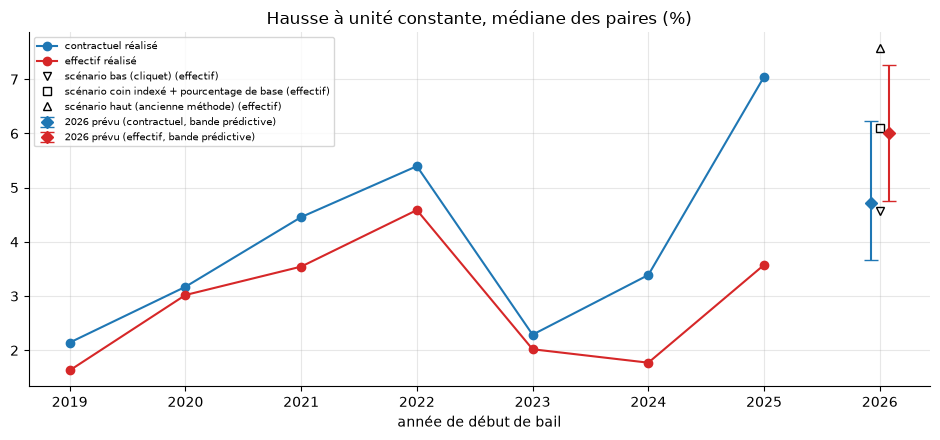

In [100]:
fig, ax = plt.subplots(figsize=STYLE.figsize_wide)
history_years = range(CONFIG.first_year, CONFIG.last_observed_year + 1)
ax.plot(history_years, same_unit.loc[history_years, ("contractuel", "median")], "o-", color=PALETTE["contract"], label="contractuel réalisé")
ax.plot(history_years, same_unit.loc[history_years, ("effectif", "median")], "o-", color=PALETTE["effective"], label="effectif réalisé")
for kind, label, offset in (("contract", "contractuel", -STYLE.marker_jitter_years), ("effective", "effectif", STYLE.marker_jitter_years)):
    row = uncertainty.loc[label]
    ax.errorbar(CONFIG.forecast_year + offset, row["médiane"], yerr=[[row["médiane"] - row[low_label]], [row[high_label] - row["médiane"]]],
                fmt="D", color=PALETTE[kind], capsize=STYLE.error_capsize, label=f"{CONFIG.forecast_year} prévu ({label}, bande prédictive)")
for name, marker in zip(NAMED_SCENARIOS, ("v", "s", "^")):
    ax.plot(CONFIG.forecast_year, scenarios.loc[name, "effectif (médiane)"], marker, color="black", fillstyle="none", label=f"scénario {name} (effectif)")
ax.set(title="Hausse à unité constante, médiane des paires (%)", xlabel="année de début de bail")
ax.legend(fontsize=STYLE.small_fontsize, loc="upper left")
plt.tight_layout()
plt.show()

### 11d. The Met sous les règles de l'Ontario : la valeur de l'exemption
Régime central : *exempté* (section 6d). Régime contrefactuel : les renouvellements de The Met plafonnés à la ligne directrice de l'année prévue. Même case de la grille (règles observées : la loi, des concessions indexées) et mêmes tirages aléatoires dans les deux cas, pour que la différence ne vienne que de la règle.

In [101]:
guideline_2026 = float(ONTARIO_GUIDELINE[CONFIG.forecast_year])
exempt = run_scenario(LAW_READING, mixture["paths"][INDEXED_PATH])
capped = run_scenario(LAW_READING, mixture["paths"][INDEXED_PATH], ontario_regime="capped", ontario_guideline=guideline_2026)
met_columns = (exempt["cohort"].province == "Ontario").to_numpy()
met_rents = exempt["weights"][met_columns]
value_of_exemption_pct = float(((exempt["contract"][:, met_columns] - capped["contract"][:, met_columns]) @ met_rents).mean() / met_rents.sum())
value_of_exemption_dollars = value_of_exemption_pct / 100 * met_rents.sum() * CONFIG.months_per_year
ontario_regimes = pd.DataFrame({
    "The Met : hausse contractuelle (moyenne pondérée, %)": [(simulation["contract"][:, met_columns] @ met_rents).mean() / met_rents.sum() for simulation in (exempt, capped)],
    "portefeuille : contractuel (médiane, %)": [np.median(simulation["contract"], axis=1).mean() for simulation in (exempt, capped)],
    "portefeuille : effectif (médiane, %)": [np.median(simulation["effective"], axis=1).mean() for simulation in (exempt, capped)]},
    index=["exempté (central)", f"plafonné à {guideline_2026} % (contrefactuel)"])
display(ontario_regimes.round(CONFIG.table_digits))
narrate(f"**Lecture.** {int(met_columns.sum())} unités de The Met échoient en {CONFIG.forecast_year} ({fmt(met_columns.mean() * 100, 0)} % de la cohorte). "
        f"L'exemption vaut **{fmt(value_of_exemption_pct, CONFIG.table_digits, signed=True)} point de hausse contractuelle** sur le loyer de The Met, soit environ "
        f"{fmt(value_of_exemption_dollars, 0)} $ de loyer contractuel annuel. L'effet sur la médiane du portefeuille est de "
        f"{fmt(ontario_regimes.iloc[0, 2] - ontario_regimes.iloc[1, 2], CONFIG.table_digits, signed=True)} point (effectif). Nous gardons les deux régimes visibles. "
        "**The Met, exempté de la ligne directrice, reçoit la politique de renouvellement de la société ; la ligne directrice de l'Ontario n'apparaît que comme contrefactuel "
        "et n'est jamais appliquée aux cinq immeubles du Québec.**")

,"The Met : hausse contractuelle (moyenne pondérée, %)","portefeuille : contractuel (médiane, %)","portefeuille : effectif (médiane, %)"
exempté (central),5.58,4.73,6.64
plafonné à 2.1 % (contrefactuel),4.47,4.55,6.45


**Lecture.** 121 unités de The Met échoient en 2026 (13 % de la cohorte). L'exemption vaut **+1,11 point de hausse contractuelle** sur le loyer de The Met, soit environ 54 470 $ de loyer contractuel annuel. L'effet sur la médiane du portefeuille est de +0,19 point (effectif). Nous gardons les deux régimes visibles. **The Met, exempté de la ligne directrice, reçoit la politique de renouvellement de la société ; la ligne directrice de l'Ontario n'apparaît que comme contrefactuel et n'est jamais appliquée aux cinq immeubles du Québec.**

### 11e. Par propriété et par nombre de chambres (bonus)
Mêmes simulations que le headline, regroupées : pour chaque segment, la médiane des paires simulées de ses unités, sur toutes les cases de la grille pondérées par leurs a priori. **Règle de petites cellules** : une propriété × chambres avec moins de `min_cell_size` unités n'est pas publiée seule ; elle affiche la valeur de sa propriété, signalée. Les sorties n'ont aucun identifiant d'unité (**aucune donnée CRM**).

In [102]:
property_names = leases.groupby("prop_code").building.first()
segment_ids = list(next(iter(mixture["runs"].values()))["segments"])


def pooled_segment(segment_id, statistic):
    values = [mixture["runs"][row.run]["segments"][segment_id][statistic] for row in mixture["frame"].itertuples()]
    weights = [np.full(len(draws), row.poids / len(draws)) for draws, row in zip(values, mixture["frame"].itertuples())]
    return np.concatenate(values), np.concatenate(weights)


def segment_row(segment_id, last_year_pairs_segment):
    effective_draws, weights = pooled_segment(segment_id, "effective")
    contract_draws, _ = pooled_segment(segment_id, "contract")
    return {"unités 2026": mixture["runs"][mixture["frame"].run.iloc[0]]["segments"][segment_id]["units"],
            "contractuel": weighted_percentile(contract_draws, weights, MEDIAN_PERCENTILE), "effectif": weighted_percentile(effective_draws, weights, MEDIAN_PERCENTILE),
            f"effectif bas ({CONFIG.ci_low:.0f} %)": weighted_percentile(effective_draws, weights, CONFIG.ci_low),
            f"effectif haut ({CONFIG.ci_high:.0f} %)": weighted_percentile(effective_draws, weights, CONFIG.ci_high),
            f"{CONFIG.last_observed_year} réalisé (effectif)": last_year_pairs_segment.growth_effective_pct.median(), "estimation reportée à la propriété": False}


property_rows = {}
for keys, label in [segment_id for segment_id in segment_ids if segment_id[0] == ("prop_code",)]:
    code = label[0]
    property_rows[code] = {"propriété": f"{property_names[code]} ({code})", "chambres": "toutes",
                           **segment_row((keys, label), last_year_pairs[last_year_pairs.prop_code == code])}
segment_rows = list(property_rows.values())
for keys, label in [segment_id for segment_id in segment_ids if segment_id[0] == ("prop_code", "beds")]:
    code, beds = label
    row = segment_row((keys, label), last_year_pairs[(last_year_pairs.prop_code == code) & (last_year_pairs.beds == beds)])
    if row["unités 2026"] < CONFIG.min_cell_size:
        row = {**property_rows[code], "unités 2026": row["unités 2026"], "estimation reportée à la propriété": True}
    segment_rows.append({**row, "propriété": f"{property_names[code]} ({code})", "chambres": int(beds)})
aggregates_2026 = pd.DataFrame(segment_rows).sort_values(["propriété", "chambres"], key=lambda column: column.astype(str)).reset_index(drop=True)
aggregates_2026.round(CONFIG.table_digits)

,propriété,chambres,unités 2026,contractuel,effectif,effectif bas (10 %),effectif haut (90 %),2025 réalisé (effectif),estimation reportée à la propriété
0,Daniel-Johnson (dj1),1,21,5.17,5.15,3.25,7.00,4.76,False
1,Daniel-Johnson (dj1),2,32,5.00,6.16,4.52,7.86,3.86,False
2,Daniel-Johnson (dj1),3,3,5.01,5.77,4.29,7.22,3.98,True
3,Daniel-Johnson (dj1),toutes,56,5.01,5.77,4.29,7.22,3.98,False
4,Daniel-Johnson (dj2),0,12,4.76,5.39,3.94,6.82,3.38,True
5,Daniel-Johnson (dj2),1,33,4.74,4.73,3.07,6.46,4.58,False
6,Daniel-Johnson (dj2),2,26,5.12,6.09,4.37,7.87,3.26,False
7,Daniel-Johnson (dj2),3,1,4.76,5.39,3.94,6.82,3.38,True
8,Daniel-Johnson (dj2),toutes,72,4.76,5.39,3.94,6.82,3.38,False
9,Le Carlyle (carlyle),1,69,4.83,6.31,4.90,7.74,2.92,False


In [103]:
by_property = aggregates_2026[aggregates_2026.chambres == "toutes"].set_index("propriété")
narrate(f"**Lecture.** La hausse effective médiane va de {fmt(by_property.effectif.min())} % ({by_property.effectif.idxmin()}) à {fmt(by_property.effectif.max())} % "
        f"({by_property.effectif.idxmax()}). Les écarts entre propriétés viennent de la **composition connue** de chaque cohorte (concessions des baux qui échoient, durée, "
        "part de renouvellements) et de la distribution des concessions propre à chaque propriété ; ils restent petits devant l'incertitude globale. Les cellules à peu d'unités "
        "sont rapportées au niveau de la propriété plutôt que publiées seules, parce qu'une médiane sur quelques unités est du bruit.")

**Lecture.** La hausse effective médiane va de 5,0 % (Saint-Elzear (stelz2)) à 6,8 % (The Met (metcalfe)). Les écarts entre propriétés viennent de la **composition connue** de chaque cohorte (concessions des baux qui échoient, durée, part de renouvellements) et de la distribution des concessions propre à chaque propriété ; ils restent petits devant l'incertitude globale. Les cellules à peu d'unités sont rapportées au niveau de la propriété plutôt que publiées seules, parce qu'une médiane sur quelques unités est du bruit.

**Les écarts entre segments persistent-ils d'une année à l'autre ?** Si une propriété ou un nombre de chambres croissait durablement plus vite que le portefeuille, la prévision par segment devrait en tenir compte. Test : l'écart (médiane effective du segment − médiane du portefeuille) de l'année `t−1` prédit-il celui de `t` ? On compare à l'hypothèse « aucun écart » sur les segments d'au moins `min_cell_size` paires.

In [104]:
segment_year = pairs.groupby(["prop_code", "beds", "lease_year"]).growth_effective_pct.agg(median="median", pairs="size").reset_index()
segment_year = segment_year[segment_year.pairs >= CONFIG.min_cell_size]
segment_year["deviation"] = segment_year["median"] - segment_year.lease_year.map(pairs.groupby("lease_year").growth_effective_pct.median())
previous_deviation = segment_year.assign(lease_year=segment_year.lease_year + 1)[["prop_code", "beds", "lease_year", "deviation"]].rename(columns={"deviation": "deviation_previous_year"})
persistence_test = segment_year.merge(previous_deviation, on=["prop_code", "beds", "lease_year"])
persistence_test = persistence_test[persistence_test.lease_year >= CONFIG.backtest_years[0]]
persistence_labels = {"tested": "segments testés (segment × année)", "correlation": "corrélation écart(t) × écart(t−1)",
                      "no_deviation": "erreur si l'on prédit « aucun écart » (points)", "carry_over": "erreur si l'on reconduit l'écart de l'an dernier (points)"}
persistence_summary = pd.Series({
    persistence_labels["tested"]: len(persistence_test),
    persistence_labels["correlation"]: persistence_test.deviation.corr(persistence_test.deviation_previous_year),
    persistence_labels["no_deviation"]: persistence_test.deviation.abs().mean(),
    persistence_labels["carry_over"]: (persistence_test.deviation - persistence_test.deviation_previous_year).abs().mean()})
display(persistence_summary.round(CONFIG.table_digits).to_frame("valeur"))
persistence = {key: persistence_summary[label] for key, label in persistence_labels.items()}
reconduction_worse = persistence["carry_over"] > persistence["no_deviation"]
narrate(f"**Lecture.** Sur {int(persistence['tested'])} segments × années, la corrélation entre l'écart d'une année et celui de la suivante vaut "
        f"{fmt(persistence['correlation'], CONFIG.table_digits)}, et reconduire l'écart de l'an dernier donne une erreur de {fmt(persistence['carry_over'], CONFIG.table_digits)} point "
        f"contre {fmt(persistence['no_deviation'], CONFIG.table_digits)} si l'on n'en prédit aucun : "
        + ("**reconduire est pire**. La prévision par segment ne diffère donc du portefeuille que par ce qui est connu de chaque cohorte, ce que fait notre simulation : "
           "c'est une conclusion, pas une paresse de modélisation." if reconduction_worse else
           "les écarts persistent en partie, une piste d'amélioration pour une prévision par segment."))

,valeur
segments testés (segment × année),29.00
corrélation écart(t) × écart(t−1),-0.14
erreur si l'on prédit « aucun écart » (points),0.49
erreur si l'on reconduit l'écart de l'an dernier (points),0.68


**Lecture.** Sur 29 segments × années, la corrélation entre l'écart d'une année et celui de la suivante vaut −0,14, et reconduire l'écart de l'an dernier donne une erreur de 0,68 point contre 0,49 si l'on n'en prédit aucun : **reconduire est pire**. La prévision par segment ne diffère donc du portefeuille que par ce qui est connu de chaque cohorte, ce que fait notre simulation : c'est une conclusion, pas une paresse de modélisation.

In [105]:
aggregates_2026.to_csv(CONFIG.output_dir / "aggregates_2026.csv", index=False)
forbidden_columns = {"unit_code", "unit_id", "lease_id", "sign_date", "lease_start", "rent_contract", "rent_effective"}
assert not forbidden_columns & set(aggregates_2026.columns), "aucun identifiant d'unité ni loyer de bail dans les sorties"
assert (aggregates_2026[~aggregates_2026["estimation reportée à la propriété"]]["unités 2026"] >= CONFIG.min_cell_size).all(), "règle de petites cellules"
if plotly_go is not None:
    property_view = aggregates_2026[aggregates_2026.chambres == "toutes"]
    high_column, low_column = f"effectif haut ({CONFIG.ci_high:.0f} %)", f"effectif bas ({CONFIG.ci_low:.0f} %)"
    dashboard = make_subplots(rows=1, cols=2, subplot_titles=(f"Hausse {CONFIG.forecast_year} par propriété (médiane, bande {CONFIG.ci_low:.0f}-{CONFIG.ci_high:.0f} %)",
                                                              "Effectif par propriété × chambres"))
    dashboard.add_trace(plotly_go.Bar(x=property_view["propriété"], y=property_view["effectif"], name="effectif",
                                      error_y=dict(type="data", symmetric=False, array=property_view[high_column] - property_view["effectif"],
                                                   arrayminus=property_view["effectif"] - property_view[low_column]), marker_color=PALETTE["effective"]), row=1, col=1)
    dashboard.add_trace(plotly_go.Bar(x=property_view["propriété"], y=property_view["contractuel"], name="contractuel", marker_color=PALETTE["contract"]), row=1, col=1)
    detail_view = aggregates_2026[aggregates_2026.chambres != "toutes"]
    dashboard.add_trace(plotly_go.Heatmap(x=detail_view["propriété"], y=detail_view.chambres.astype(str), z=detail_view["effectif"], colorscale="RdYlGn",
                                          colorbar=dict(title="%")), row=1, col=2)
    dashboard.update_layout(title=f"Collection Équinoxe : hausse de loyer {CONFIG.forecast_year} (agrégats seulement, aucune donnée CRM)", barmode="group")
    dashboard.write_html(CONFIG.output_dir / "dashboard_2026.html", include_plotlyjs="cdn")
    print("Tableau de bord écrit : outputs/dashboard_2026.html (agrégats seulement)")
else:
    print("plotly absent : le tableau de bord HTML est facultatif ; les agrégats sont dans outputs/aggregates_2026.csv")

Tableau de bord écrit : outputs/dashboard_2026.html (agrégats seulement)


### 11f. Réponse finale
Le headline est la **médiane du modèle structurel** de la hausse effective ; la bande est celle de 11c. Le fichier `outputs/final_answer.json` reprend ces valeurs (agrégats seulement).

In [106]:
headline = effective_p50
final_answer = {
    "definition": f"Croissance à unité constante du loyer effectif (net des concessions), médiane des paires, baux débutant en {CONFIG.forecast_year} (renouvellements + relocations)",
    "headline_effective_pct": round(headline, CONFIG.table_digits),
    "headline_band_pct": [round(uncertainty.loc["effectif", low_label], CONFIG.table_digits), round(uncertainty.loc["effectif", high_label], CONFIG.table_digits)],
    "headline_method": "modèle structurel (TAL daté par l'avis, IPC loyers de l'année précédente, concessions à deux marges) ; grille des inconnues de 2026 pondérée uniformément ; "
                       "bande = grille + échantillonnage + erreur de modèle du backtest",
    "effective_weighted_mean_pct": round(uncertainty.loc["effectif", "moyenne pondérée par le loyer"], CONFIG.table_digits),
    "contract_pct": round(contract_p50, CONFIG.table_digits),
    "contract_band_pct": [round(uncertainty.loc["contractuel", low_label], CONFIG.table_digits), round(uncertainty.loc["contractuel", high_label], CONFIG.table_digits)],
    "renewal_anchor_law_pct": round(float(law_anchor.mean()), CONFIG.table_digits),
    "attribution_points": {name: round(value, CONFIG.table_digits) for name, value in attribution.items()},
    "scenarios_effective_pct": {name: round(float(value), CONFIG.table_digits) for name, value in scenarios["effectif (médiane)"].items()},
    "prior_sensitivity_effective_pct": {name: round(float(value), CONFIG.table_digits) for name, value in prior_table["effectif (médiane)"].items()},
    "backtest_bias_points": {kind: round(value, CONFIG.table_digits) for kind, value in model_bias.items()},
    "bias_adjusted_sensitivity_pct": {kind: round(float(value), CONFIG.table_digits) for kind, value in bias_sensitivity["sensibilité : médiane moins biais (%)"].items()},
    "robustness_effective_range_pct": [round(float(robustness.iloc[:, 0].min()), CONFIG.table_digits), round(float(robustness.iloc[:, 0].max()), CONFIG.table_digits)],
    "mc_precision_sd_points": round(mc_precision, CONFIG.fine_digits),
    "backtest_mae_points": {kind: round(float(structural_live_rows.loc[list(CONFIG.backtest_years), f"error_{kind}"].abs().mean()), CONFIG.table_digits) for kind in ("effective", "contract")},
    "presentation_diagnostics": {"mix_year": int(naive_peak_year), "naive_growth_pct": round(float(naive.yoy_pct[naive_peak_year]), CONFIG.table_digits),
        "fixed_panel_growth_pct": round(float(panel_yoy[naive_peak_year]), CONFIG.table_digits), "fisher_growth_pct": round(float(fisher[naive_peak_year]), CONFIG.table_digits),
        "reconstruction_share_pct": round(float(close.mean() * 100), CONFIG.table_digits), "reconstruction_tolerance_dollars": CONFIG.exact_tolerance_dollars,
        "concession_penetration_pct": round(float(profile_by_year.penetration_pct[CONFIG.last_observed_year]), CONFIG.table_digits)},
    "information_vintage": FORECAST.live_vintage, "data_as_of": CONFIG.data_as_of, "cohort_units": int(mixture["n_units"])}
(CONFIG.output_dir / "final_answer.json").write_text(json.dumps(final_answer, ensure_ascii=False, indent=2), encoding="utf-8")
# Tables agrégées utilisées par les graphiques du jury et la vérification de livraison.
evidence = {
    "backtest": backtest_table.drop(columns=["centers", "actual_components"]).to_dict(orient="records"),
    "baselines": baseline_table.to_dict(orient="records"),
    "historical_growth": [{"year": int(year), "contract": float(same_unit.loc[year, ("contractuel", "median")]),
        "effective": float(same_unit.loc[year, ("effectif", "median")])} for year in range(CONFIG.first_year, CONFIG.last_observed_year + 1)],
    "pair_counts": {str(year): int(count) for year, count in pairs.groupby("lease_year").size().items()},
    "uncertainty": uncertainty.reset_index(names="kind").to_dict(orient="records"),
    "robustness": robustness.reset_index(names="setting").to_dict(orient="records"),
    "policy_sensitivity": prior_table.reset_index(names="policy").to_dict(orient="records"),
    "sources": sorted(set(external.source_url)),
    "annualisation": "Exact elapsed days between lease starts / days_per_year, matching build_pairs",
    "data_as_of": CONFIG.data_as_of,
    "backtest_years": list(CONFIG.backtest_years), "live_vintage": FORECAST.live_vintage}
(CONFIG.output_dir / "evidence.json").write_text(json.dumps(evidence, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")

print(f"HAUSSE DE LOYER {CONFIG.forecast_year} (définition principale) : {headline:.1f} %  [bande {CONFIG.ci_low:.0f}-{CONFIG.ci_high:.0f} % : "
      f"{final_answer['headline_band_pct'][0]:.1f} à {final_answer['headline_band_pct'][1]:.1f} %]")
print(f"   {final_answer['definition']}")
print(f"HAUSSE CONTRACTUELLE {CONFIG.forecast_year} (même unité, loyer au bail) : {final_answer['contract_pct']:.1f} %  "
      f"[{final_answer['contract_band_pct'][0]:.1f} à {final_answer['contract_band_pct'][1]:.1f} %]")

HAUSSE DE LOYER 2026 (définition principale) : 6.0 %  [bande 10-90 % : 4.7 à 7.3 %]
   Croissance à unité constante du loyer effectif (net des concessions), médiane des paires, baux débutant en 2026 (renouvellements + relocations)
HAUSSE CONTRACTUELLE 2026 (même unité, loyer au bail) : 4.7 %  [3.7 à 6.2 %]


In [107]:
narrate(f"### Réponse : **{fmt(headline)} %** de hausse effective en {CONFIG.forecast_year} (bande {CONFIG.ci_low:.0f}-{CONFIG.ci_high:.0f} % : "
        f"{fmt(final_answer['headline_band_pct'][0])} à {fmt(final_answer['headline_band_pct'][1])} %)\n\n"
        f"1. **Contractuel : {fmt(contract_p50)} %** ({fmt(final_answer['contract_band_pct'][0])} à {fmt(final_answer['contract_band_pct'][1])} %). Les renouvellements suivent "
        f"une politique commune ancrée sur le calendrier du TAL (proxy pour The Met, pas droit québécois) (en moyenne {fmt(law_anchor.mean(), CONFIG.table_digits)} % : ni le pourcentage de base de "
        f"{fmt(TAL_NEW_FORMAT[CONFIG.forecast_year])} % pour tous, ni l'ancienne méthode) ; les relocations suivent l'IPC loyers du Québec de l'année précédente "
        f"({fmt(mixture['lagged_cpi'], CONFIG.table_digits)} %).\n"
        f"2. **Effectif : {fmt(headline)} %**, au-dessus du contractuel parce que les concessions des nouveaux baux devraient se situer sous ou au niveau de celles des baux qui échoient "
        f"(drag {CONFIG.last_observed_year} : {fmt(mixture['last_drag'])} % ; indexé sur l'IPC : {fmt(mixture['lagged_cpi'])} %). Moyenne pondérée par le loyer : "
        f"{fmt(final_answer['effective_weighted_mean_pct'])} %.\n"
        f"3. **Ce qui est jugement :** deux choix de politique incertains (suivi de la loi par la société, comportement des concessions quand l'IPC baisse), pondérées uniformément "
        f"faute de preuve suffisante pour les départager ; selon la lecture retenue, la réponse va de {fmt(prior_table['effectif (médiane)'].min())} à {fmt(prior_table['effectif (médiane)'].max())} % "
        f"({fmt(prior_table.iloc[-1, 0])} % si l'on ne retient que les règles observées).\n"
        f"4. **Ce qui est mesuré :** le même modèle, rejoué sur {CONFIG.backtest_years[0]}-{CONFIG.backtest_years[-1]}, se trompe en moyenne de "
        f"{fmt(final_answer['backtest_mae_points']['effective'], CONFIG.table_digits)} point sur l'effectif et {fmt(final_answer['backtest_mae_points']['contract'], CONFIG.table_digits)} "
        "point sur le contractuel ; en cas de changement de régime, l'erreur historique est plus grande et à sens unique (11c).")

### Réponse : **6,0 %** de hausse effective en 2026 (bande 10-90 % : 4,7 à 7,3 %)

1. **Contractuel : 4,7 %** (3,7 à 6,2 %). Les renouvellements suivent une politique commune ancrée sur le calendrier du TAL (proxy pour The Met, pas droit québécois) (en moyenne 3,78 % : ni le pourcentage de base de 3,1 % pour tous, ni l'ancienne méthode) ; les relocations suivent l'IPC loyers du Québec de l'année précédente (7,72 %).
2. **Effectif : 6,0 %**, au-dessus du contractuel parce que les concessions des nouveaux baux devraient se situer sous ou au niveau de celles des baux qui échoient (drag 2025 : 9,1 % ; indexé sur l'IPC : 7,7 %). Moyenne pondérée par le loyer : 6,7 %.
3. **Ce qui est jugement :** deux choix de politique incertains (suivi de la loi par la société, comportement des concessions quand l'IPC baisse), pondérées uniformément faute de preuve suffisante pour les départager ; selon la lecture retenue, la réponse va de 5,9 à 6,6 % (6,6 % si l'on ne retient que les règles observées).
4. **Ce qui est mesuré :** le même modèle, rejoué sur 2023-2025, se trompe en moyenne de 0,30 point sur l'effectif et 0,58 point sur le contractuel ; en cas de changement de régime, l'erreur historique est plus grande et à sens unique (11c).

In [108]:
assert final_answer["headline_band_pct"][0] <= final_answer["headline_effective_pct"] <= final_answer["headline_band_pct"][1]
scenario_values = [scenarios.loc[name, "effectif (médiane)"] for name in NAMED_SCENARIOS]
assert scenario_values == sorted(scenario_values), "scénarios ordonnés du bas vers le haut"
observed_rules_cell = grid_effective.loc[LAW_READING, INDEXED_PATH]
assert final_answer["headline_band_pct"][0] <= observed_rules_cell <= final_answer["headline_band_pct"][1], "la bande couvre la case des règles observées"
assert predictive["effective"].min() <= min(scenario_values) and max(scenario_values) <= predictive["effective"].max(), "les coins nommés sont dans le support prédictif"
assert np.isclose(estimate_2026(leases, asking), headline), "estimate_2026() doit reproduire exactement la réponse (mêmes nombres aléatoires)"
print("Contrôles de la section 11 : OK")

Contrôles de la section 11 : OK


### 11g. Aperçu 2027 : le prochain budget est déjà lisible dans les données publiques
Les règles qui pilotent le modèle sont publiques **avant** que l'année commence : le pourcentage de base du TAL (moyenne des trois variations annuelles de l'IPC d'ensemble du Québec) et l'IPC loyers de l'année écoulée (qui fixe les relocations et les concessions). Sans changer le modèle, on peut donc lire 2027 dès aujourd'hui, avec les mois déjà publiés.

In [109]:
next_year = CONFIG.forecast_year + 1
all_items_ytd = external_series("cpi_all_items_ytd_yoy", "Quebec")
all_items_with_current = pd.concat([all_items, all_items_ytd.loc[[CONFIG.forecast_year]]])
tal_next_year = max(float(all_items_with_current.loc[next_year - FORECAST.tal_new_method_window_years:next_year - 1].mean()), 0.0)
rent_cpi_current = cpi_driver(EXTERNAL_TABLES, CONFIG.forecast_year, live_cutoff)
current_year_cpi = cpi_monthly[(cpi_monthly.geo == "Quebec") & (cpi_monthly.month.dt.year == CONFIG.forecast_year)].set_index("month").yoy_pct
preview_next_year = pd.DataFrame({
    f"{CONFIG.forecast_year} (prévu)": [TAL_NEW_FORMAT[CONFIG.forecast_year], mixture["lagged_cpi"], mixture["centers"]["drag"]],
    f"{next_year} (aperçu)": [tal_next_year, rent_cpi_current, rent_cpi_current]},
    index=["renouvellements : pourcentage de base du TAL (%)", "relocations : IPC loyers QC de l'année précédente (%)", "concessions : drag moyen de la grille (%)"])
print(f"IPC publié jusqu'en {current_year_cpi.index.max():%Y-%m} ; variation annuelle de l'IPC loyers QC, mois par mois :", current_year_cpi.round(CONFIG.prose_digits).to_dict())
preview_next_year.round(CONFIG.table_digits)

IPC publié jusqu'en 2026-08 ; variation annuelle de l'IPC loyers QC, mois par mois : {Timestamp('2026-01-01 00:00:00'): 8.5, Timestamp('2026-02-01 00:00:00'): 8.7, Timestamp('2026-03-01 00:00:00'): 5.0, Timestamp('2026-04-01 00:00:00'): 5.4, Timestamp('2026-05-01 00:00:00'): 5.7, Timestamp('2026-06-01 00:00:00'): 5.4, Timestamp('2026-07-01 00:00:00'): 4.0, Timestamp('2026-08-01 00:00:00'): 3.0}


,2026 (prévu),2027 (aperçu)
renouvellements : pourcentage de base du TAL (%),3.10,2.64
relocations : IPC loyers QC de l'année précédente (%),7.72,5.72
concessions : drag moyen de la grille (%),8.43,5.72


In [110]:
narrate(f"**Lecture.** Sous les règles observées, le pourcentage de base du TAL passerait de {fmt(TAL_NEW_FORMAT[CONFIG.forecast_year])} % à **{fmt(tal_next_year)} %** en {next_year}, "
        f"et les relocations comme les concessions (liées à l'IPC loyers de {CONFIG.forecast_year}, qui décélère de {fmt(current_year_cpi.iloc[0])} % en janvier à "
        f"{fmt(current_year_cpi.iloc[-1])} % au dernier mois publié) à **{fmt(rent_cpi_current)} %** contre {fmt(mixture['lagged_cpi'])} % pour {CONFIG.forecast_year}. "
        "C'est un **aperçu**, pas une prévision validée : il suppose que les règles tiennent encore et que les mois restants ressemblent aux mois déjà publiés.")

**Lecture.** Sous les règles observées, le pourcentage de base du TAL passerait de 3,1 % à **2,6 %** en 2027, et les relocations comme les concessions (liées à l'IPC loyers de 2026, qui décélère de 8,5 % en janvier à 3,0 % au dernier mois publié) à **5,7 %** contre 7,7 % pour 2026. C'est un **aperçu**, pas une prévision validée : il suppose que les règles tiennent encore et que les mois restants ressemblent aux mois déjà publiés.

In [111]:
assert 0 < tal_next_year < TAL_NEW_FORMAT[CONFIG.forecast_year] + 1, "le pourcentage de base de l'année suivante doit rester plausible"
print("Contrôles de la section 11g : OK")

Contrôles de la section 11g : OK


## 12. Limites et hypothèses (énoncées, pas cachées)

**Hypothèses de la prévision**
1. **Définition** : hausse à unité constante du loyer *effectif*, médiane des paires annualisées, baux débutant en 2026 ; le contractuel est publié à côté.
2. **Cohorte** : les unités dont le dernier bail connu se termine de sorte que le suivant débute en 2026 (le nouveau bail commence le lendemain de la fin de l'ancien). La couverture de cette hypothèse est mesurée ci-dessous sur les années passées.
3. **Renouvellements** : le taux du TAL applicable à chaque unité, selon la fenêtre de validité du taux et la date légale de l'avis (sections 6b et 10d). C'est la loi ; la société pourrait s'en écarter, d'où les deux lectures extrêmes de la grille.
4. **Relocations** : variation de l'IPC loyers du Québec de l'année précédente, sans paramètre ajusté (sections 8b et 10c).
5. **Concessions** : le niveau du drag suit l'IPC loyers du Québec de l'année précédente ; sa forme suit deux marges (pénétration `1 − exp(−k × drag)`, `k` estimé à la date de coupure ; profondeur tirée de la distribution de chaque propriété). **Le drag n'a jamais baissé dans les données** : le cliquet et le demi-cliquet restent dans la grille.
6. **Dispersion** : les écarts entre paires d'un même type ressemblent à ceux de l'année précédente (résidus rééchantillonnés).
7. **Ontario (The Met)** : exempté de la ligne directrice (immeuble livré en 2023, sources publiques) ; suit la politique de renouvellement de la société (sections 6c bis et 6d). Régime plafonné présenté en contrefactuel.
8. **Information** : la prévision en direct utilise les données publiques à la date de retrait (millésime `october`) ; le backtest rejoue chaque millésime avec les seules valeurs publiées à la date de coupure.
9. **A priori** : les lectures des deux inconnues de 2026 sont pondérées uniformément, faute de preuve suffisante pour les départager (section 10d ; précédent historique affiché) ; la section 11b montre la réponse sous les seules règles observées, et la section 10f bis la sensibilité à chaque réglage déclaré.

**Couverture de la cohorte.** Les unités d'une cohorte sont-elles réellement relouées dans l'année ? On le vérifie sur les années du backtest, avec la cohorte telle qu'elle était connue à chaque date de coupure.

In [112]:
coverage_rows = []
for target_year in CONFIG.backtest_years:
    cohort_year = build_cohort(prepare_context(*known_at(leases, asking, target_year)), target_year)
    started = set(zip(leases[leases.lease_year == target_year].prop_code, leases[leases.lease_year == target_year].unit_code))
    covered = np.array([(code, unit) in started for code, unit in zip(cohort_year.prop_code, cohort_year.unit_code)])
    coverage_rows.append({"année": target_year, "unités de la cohorte": len(cohort_year), "relouées dans l'année (%)": covered.mean() * 100,
                          "non relouées à stelz1": int((~covered & (cohort_year.prop_code == "stelz1").to_numpy()).sum()), "non relouées au total": int((~covered).sum())})
coverage = pd.DataFrame(coverage_rows).set_index("année")
display(coverage.round(CONFIG.prose_digits))
stelz1_leases = leases[leases.prop_code == "stelz1"].groupby("lease_year").size()
stelz1_in_cohort = int((mixture["cohort"].prop_code == "stelz1").sum())
print(f"Cohorte {CONFIG.forecast_year} : {mixture['n_units']} unités, dont {stelz1_in_cohort} à stelz1 ; baux de stelz1 par année :", stelz1_leases.loc[CONFIG.backtest_years[0]:].to_dict())

,unités de la cohorte,relouées dans l'année (%),non relouées à stelz1,non relouées au total
année,,,,
2023,415,99.00,1,4
2024,681,98.40,5,11
2025,856,90.30,62,83


Cohorte 2026 : 940 unités, dont 37 à stelz1 ; baux de stelz1 par année : {2023: 99, 2024: 96, 2025: 36}


In [113]:
early_contract_errors = structural_live_rows.loc[early_years, "error_contract"]
relet_share = coverage["relouées dans l'année (%)"]
lowest_year = relet_share.idxmin()
narrate(f"**Limites (chiffrées).**\n"
        f"* **Couverture.** Les cohortes passées ont été relouées dans l'année à {fmt(relet_share.min(), 0)}-"
        f"{fmt(relet_share.max(), 0)} % ; en {lowest_year}, l'année la plus basse, {coverage.loc[lowest_year, 'non relouées à stelz1']} des "
        f"{coverage.loc[lowest_year, 'non relouées au total']} unités non relouées sont à `stelz1`, qui se vide "
        f"({' → '.join(str(int(count)) for count in stelz1_leases.loc[CONFIG.backtest_years[0]:])} baux par an) pendant que `stelz3` ouvre en réutilisant ses codes d'unité. "
        f"La cohorte {CONFIG.forecast_year} compte {stelz1_in_cohort} unités de `stelz1` ({fmt(stelz1_in_cohort / mixture['n_units'] * 100)} % de la cohorte), qui ne seront "
        "probablement pas relouées : la cohorte surestime d'autant le nombre de paires.\n"
        f"* **Règles repérées sur les années qu'elles prédisent.** L'indexation des concessions et des relocations sur l'IPC a été trouvée en regardant 2018-2025 : le backtest "
        "la favorise et la bande d'erreur de modèle est optimiste. Huit points annuels ne prouvent pas une loi ; la prévision dépend de sa poursuite.\n"
        f"* **Peu de régimes.** Hors du régime d'indexation ({', '.join(map(str, early_years))}), l'erreur contractuelle du modèle atteint "
        f"{', '.join(fmt(value, signed=True) for value in early_contract_errors)} points : les renouvellements dépassaient alors largement le TAL.\n"
        f"* **Ottawa : peu de recul.** The Met n'a que {met_pairs.lease_year.nunique()} années de paires ; ses estimations sont plus incertaines que celles du Québec.")

**Limites (chiffrées).**
* **Couverture.** Les cohortes passées ont été relouées dans l'année à 90-99 % ; en 2025, l'année la plus basse, 62 des 83 unités non relouées sont à `stelz1`, qui se vide (99 → 96 → 36 baux par an) pendant que `stelz3` ouvre en réutilisant ses codes d'unité. La cohorte 2026 compte 37 unités de `stelz1` (3,9 % de la cohorte), qui ne seront probablement pas relouées : la cohorte surestime d'autant le nombre de paires.
* **Règles repérées sur les années qu'elles prédisent.** L'indexation des concessions et des relocations sur l'IPC a été trouvée en regardant 2018-2025 : le backtest la favorise et la bande d'erreur de modèle est optimiste. Huit points annuels ne prouvent pas une loi ; la prévision dépend de sa poursuite.
* **Peu de régimes.** Hors du régime d'indexation (2021, 2022), l'erreur contractuelle du modèle atteint −3,5, −3,8 points : les renouvellements dépassaient alors largement le TAL.
* **Ottawa : peu de recul.** The Met n'a que 2 années de paires ; ses estimations sont plus incertaines que celles du Québec.

**Autres limites**
* **Valeurs du TAL.** Les estimations de l'ancienne méthode de 2022 à 2024 sont lues dans le texte des communiqués officiels du TAL ; la valeur 2025 est lue dans l'image du tableau 2 du communiqué officiel (le texte n'est pas extractible) et 2021 dans le communiqué du TAL du 20 janvier 2021 diffusé par CNW (voir `external/manual_public_rates.csv`) ; le taux « ancienne méthode » de la fenêtre 2026 n'est pas publié : il est prévu par la formule de la section 10c ; les pourcentages de base de la nouvelle méthode viennent des sites officiels et sont retrouvés par leur formule (section 10c). Les valeurs antérieures à 2021, publiées sous forme d'images, ne sont pas utilisées.
* **Extrait publié, pas le portefeuille.** Les volumes ne sont pas représentatifs : l'occupation, l'inoccupation, l'absorption et le rôle de loyers du portefeuille **ne sont pas calculés** (le défi les exclut). L'inoccupation citée vient de la SCHL (publique). Les **niveaux** de loyer de l'extrait ne sont jamais comparés à des annonces réelles : seuls des taux de variation servent à la méthode.
* **Pas de structure exploitable au niveau de l'unité.** Ni XGBoost (section 10h) ni le test de persistance des segments (section 11e) ne trouvent de signal propre à l'unité ou au segment qui survive hors période : les données se réduisent à quelques paramètres annuels (taux de renouvellement, hausse des relocations, niveau et fréquence des concessions), dont trois sont liés à des séries publiques.
* **Pas d'inférence formelle** sur les réconciliations (peu de points annuels) : nous rapportons des erreurs et des corrélations, pas des p-valeurs.
* **Le fichier `listings`** ne contient aucun prix 2026 (section 10g) ; nous ne le traitons pas comme tel.

**Ce que nous ferions avec plus de données** : les concessions par bail de 2026 (pour mesurer directement la politique), un historique d'affichages hebdomadaire, les dates réelles des avis de renouvellement (pour remplacer l'hypothèse d'avis uniforme dans la fenêtre légale), les dates de non-renouvellement et les unités vacantes (pour une vraie probabilité de renouvellement par immeuble).

## 13. Références

### Sources publiques (détail, licences et dates de retrait dans `external/SOURCES.md` ; valeurs dans `external/tidy/`)
* **Statistique Canada**, tableau 18-10-0004-01, *Indice des prix à la consommation*, composante loyers et ensemble, Québec, Ontario, Canada : https://www150.statcan.gc.ca/t1/tbl1/fr/tv.action?pid=1810000401 (Licence du gouvernement ouvert – Canada).
* **SCHL**, *Enquête sur les logements locatifs* (taux d'inoccupation et loyers moyens par nombre de chambres, RMR de Montréal et d'Ottawa-Gatineau, partie ontarienne), republiée par Statistique Canada, tableaux 34-10-0130-01 et 34-10-0133-01 : https://www150.statcan.gc.ca/t1/tbl1/fr/tv.action?pid=3410013001 et https://www150.statcan.gc.ca/t1/tbl1/fr/tv.action?pid=3410013301.
* **SCHL**, *Rapport sur le marché locatif 2025* (chiffres titres pour Montréal : loyer moyen à échantillon constant, hausse à la relocation et sans changement de locataire) et *Mise à jour de mi-année 2026* (indice des loyers affichés) : https://www.cmhc-schl.gc.ca/professionals/housing-markets-data-and-research/market-reports/rental-market-reports-major-centres et https://www.cmhc-schl.gc.ca/observer/2026/2026-mid-year-rental-market-update.
* **Tribunal administratif du logement**, communiqués annuels sur le calcul de l'ajustement des loyers (2022 à 2025, estimation moyenne de l'ancienne méthode) : https://www.tal.gouv.qc.ca/ ; pourcentage de base 2026 : https://www.quebec.ca/nouvelles/actualites/details/le-calcul-de-lajustement-des-loyers-en-2026-68053 ; page des pourcentages : https://www.tal.gouv.qc.ca/fr/reconduction-du-bail-et-fixation-de-loyer/pourcentages-applicables-aux-criteres-de-fixation-de-loyer.
* **Gouvernement du Québec**, décret 1455-2025 (*Règlement modifiant le Règlement sur les critères de fixation de loyer*, nouvelle méthode et art. `3.1` : formule du pourcentage de base ; art. 6 et 8 : disposition transitoire pour les avis donnés à compter du 1er janvier 2026), *Gazette officielle du Québec* : https://www.publicationsduquebec.gouv.qc.ca/fileadmin/gazette/pdf_encrypte/lois_reglements/2025F/86904.pdf.
* **Code civil du Québec**, art. 1896 (déclaration du loyer le plus bas des 12 derniers mois), 1942 (délais de l'avis de modification), 1950 (fixation à la demande du nouveau locataire) et 1955 (immeubles de cinq ans ou moins) : https://www.legisquebec.gouv.qc.ca/fr/document/lc/CCQ-1991.
* **Ontario**, *Residential rent increases* (ligne directrice annuelle ; exemption des unités occupées pour la première fois après le 15 novembre 2018 ; règle des 12 mois) : https://www.ontario.ca/page/rent-increase-guideline.
* **The Met, 180 rue Metcalfe, Ottawa** (tour résidentielle de 303 logements, occupation à partir de mai 2023, derrière la façade patrimoniale du Medical Arts Building) : RENX, *Jadco doubles down on Ottawa with 2nd downtown multires tower* (19 juin 2023, https://renx.ca/jadco-doubles-down-on-ottawa-with-2nd-downtown-multires-tower) ; Ottawa Business Journal (28 septembre 2018, https://obj.ca/?p=77759) ; contexte du projet initial (promoteur Toth Equity) : Patrimoine Ottawa (https://heritageottawa.org/node/1115).
* **Jeu Kaggle suggéré** (loyers canadiens, juin 2024) : consulté comme piste, **non utilisé** (compte requis, instantané unique).

### Méthodes
* Bailey, M. J., Muth, R. F. et Nourse, H. O. (1963). *A regression method for real estate price index construction*. Journal of the American Statistical Association.
* Case, K. E. et Shiller, R. J. (1987). *Prices of single-family homes since 1970: new indexes for four cities*. New England Economic Review (pondération par la variance prédite selon l'écart).
* Décomposition *shift-share* (effet de prix à l'intérieur des segments contre effet de composition) et indice de Fisher (moyenne géométrique des indices de Laspeyres et de Paasche).
* Simulation Monte-Carlo à nombres aléatoires communs (les écarts entre scénarios ne viennent que des entrées) ; validation à origine glissante avec données publiques datées (*point-in-time*).
* Chen, T. et Guestrin, C. (2016). *XGBoost: a scalable tree boosting system*. KDD ; Lundberg, S. et Lee, S.-I. (2017). *A unified approach to interpreting model predictions* (SHAP).

### Outils d'intelligence artificielle utilisés (déclaration exigée par le défi)
* **Claude Code (Anthropic, modèle `Claude Sonnet 5.5`)** : assistant de programmation et de rédaction. Il a servi à écrire et tester le code de ce notebook, à explorer les données, à rechercher et lire les sources publiques ci-dessus et à rédiger les explications.
* Une **seconde session Claude Code (modèle `Claude Opus 5.5`)** a mené en parallèle des analyses indépendantes (simulation de cohorte, XGBoost, loyers répétés, modèle hédonique), des relectures et la refonte finale du notebook (paramètres estimés ou déclarés, texte chiffré rédigé par le code, ancrage du TAL daté par l'avis, modèle des concessions à deux marges). Ses apports retenus : la **découverte de l'indexation des concessions et des relocations sur l'IPC loyers de l'année précédente** et la **reconstruction des deux formules du TAL** ; nous avons vérifié chaque résultat sur les données avant de l'intégrer.
* **Codex (OpenAI)** : nettoyage du code, contrôles des entrées, reconstruction et vérification de la livraison, graphiques et présentation.
* **Chaque chiffre du notebook est produit par le code exécuté ici** ; les valeurs publiques saisies à la main (TAL, ligne directrice, chiffres titres de la SCHL) sont dans `external/manual_public_rates.csv` avec leur URL, leur date de publication, leur date de retrait et un niveau de confiance.
* Codex (OpenAI) a repris le travail interrompu : reconstruction, contrôles, corrections de cohérence et sensibilité au biais récent.
* L'équipe a relu et validé les choix de méthode ; les décisions de jugement (définition, hypothèses, a priori, lecture des règles) sont les siennes.

In [114]:
print("Notebook terminé : toutes les sections ont été exécutées et tous les contrôles de validité sont passés.")

Notebook terminé : toutes les sections ont été exécutées et tous les contrôles de validité sont passés.
